# <CENTER> **Classification task: MolPredict. Exploring Chemistry**

#### **Постановка задачи:**

На основании предоставленных данных от химиков необходимо построить прогноз, позволяющий подобрать наиболее эффективное сочетание параметров для создания лекарственных препаратов.

Для этого требуется:

Проанализировать текущие параметры с использованием различных методов.
Научиться предсказывать их эффективность.
Как и в любой задаче машинного обучения, здесь нет однозначного ответа на вопрос, какая модель обеспечит наилучший результат. Поэтому необходимо протестировать различные подходы, проанализировать возможные результаты, сравнить качество построенных моделей и сделать обоснованные выводы.

Необходимо создать несколько максимально эффективных моделей классификации для решения следующих задач:

* **Классификация**: превышает ли значение $IC50$ медианное значение выборки;

* **Классификация**: превышает ли значение $CC50$ медианное значение выборки;

* **Классификация**: превышает ли значение $SI$ медианное значение выборки;

* **Классификация**: превышает ли значение $SI$ значение $8$.

---


#### **Основные цели:**

* Произвести итоговый отбор признаков;

* Построить несколько моделей и выбрать из них ту, которая показывает наилучший результат по заданной метрике.

---


#### **Этапы работы над проектом:**

Проект будет состоять из трёх частей:

`1.` *Отбор признаков*;

`2.` *Machine Learning*;

`3.` *Вывод*.

---

**Импортируем необходимые библиотеки:**

In [1]:
# Для работы с данными
import numpy as np
import pandas as pd
import category_encoders as ce
from imblearn import over_sampling
import transformers
from transformers import MolecularProperties, FunctionalGroups, TopologicalDescriptors, Transformations, FeatureSelector
from sklearn import pipeline
from sklearn.base import BaseEstimator, TransformerMixin


# Для построения графиков
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go


# Для построения моделей
from sklearn import feature_selection
from sklearn import preprocessing
from sklearn import metrics
from sklearn import linear_model
from sklearn import svm
from sklearn import ensemble
from sklearn import model_selection
from sklearn import tree
from sklearn import neighbors
from sklearn import neural_network
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Для сохранения модели
import joblib

**Загрузка данных:**

In [2]:
# Загружаем 'DataFrame'
molecule_data = pd.read_csv('data/molecule_processed_df.csv')

# Создаём копию оригинального 'DataFrame'
molecule_df = molecule_data.copy()

**Выведем информацию по таблицам.**

Создаём функцию:

In [3]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print()
    print(f'Данные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем таблицу
    display(data)
    print('-' * length2)

Выводим результат:

In [4]:
# Выводим информацию по полученным таблицам при помощи функции 'check_data_inf'
check_data_inf(
    data = molecule_df.head(),
    data_name = 'molecule_df',
    length1 = 40,
    length2 = 150
)


Данные таблицы "molecule_df" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 223.
----------------------------------------


,Unnamed: 0.1,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,...,fr_unbrch_alkane,fr_urea,SI_category,fr_amide_presence,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,"log_IC50, mM","log_CC50, mM",log_SI
0,0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,...,3,0,экстремально высокий,Без амидной группы,Без группы,Без группы,Без группы,1.979535,5.173221,3.371597
1,1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,...,3,0,экстремально высокий,Без амидной группы,Без группы,Без группы,Без группы,0.572014,1.856738,2.079442
2,2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,...,3,0,низкий,Без амидной группы,Без группы,Без группы,Без группы,5.415250,5.088474,0.542324
3,3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,...,4,0,экстремально высокий,Без амидной группы,Без группы,Без группы,Без группы,0.995333,4.690023,4.162553
4,4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,...,0,0,умеренный,Без амидной группы,Без группы,Без группы,Без группы,4.683348,4.943576,0.832909


------------------------------------------------------------------------------------------------------------------------------------------------------


**Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [5]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'В таблице "{data_name}" представлены признаки следующих типов:')
    print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [6]:
# Выводим данные таблицы 'molecule_df'
check_features_dtypes(
    data = molecule_df,
    data_name = 'molecule_df',
    length1 = 55,
    length2 = 40
)

В таблице "molecule_df" представлены признаки следующих типов:
-------------------------------------------------------

Количество признаков типа 'object': 5
Количество признаков типа 'int64': 108
Количество признаков типа 'float64': 110
Количество признаков типа 'bool': 0
----------------------------------------


**Определение метрик.**

Используем следующие метрики для оценки:

* **Accuracy**:________________(метрика точности),

* **Precision**:_______________(положительное прогнозное значение),

* **Recall**:__________________(доля истинно положительных результатов),

* **F1-score**:________________(среднее значение Точности измерений),

* **Classification report**:___(таблица рассчитанных метрик).

Создадим функцию для вычисления метрик:

In [7]:
# Создаём функцию 'print_metrics'       
def print_metrics(y_true, y_predict, model_name, decimal_places = 3):
    
    """
    Вычисляет и выводит метрики (Accuracy, Precision, Recall, F1-score, Classification report) для оценки модели.
    
    Параметры:
    - y_true: истинные значения (например, y_valid)
    - y_pred: предсказанные значения (например, y_log_predict)
    - model_name: строка с названием модели (например, "LogisticRegression")
    - decimal_places: количество знаков после запятой для форматирования (по умолчанию 3)
    
    """
    
    
    # Вычисляем метрики
    accuracy_metric = metrics.accuracy_score(y_true, y_predict)
    precision_metric = metrics.precision_score(y_true, y_predict, average = 'weighted')
    recall_metric = metrics.recall_score(y_true, y_predict, average = 'weighted')
    f1_metric = metrics.f1_score(y_true, y_predict, average = 'weighted')
    cr_metrics = metrics.classification_report(y_true, y_predict)
    
    
    # Выведем результат
    print(f'\n{model_name} (значения метрик):\n')
    print(f'Accuracy: {accuracy_metric:.{decimal_places}f}')
    print('-' * 80)
    print(f'Precision: {precision_metric:.{decimal_places}f}')
    print('-' * 80)
    print(f'Recall: {recall_metric:.{decimal_places}f}')
    print('-' * 80)
    print(f'F1-score: {f1_metric:.{decimal_places}f}')
    print('-' * 80)
    print()
    print(f'Classification report:\n\n{cr_metrics}')
    print('-' * 80)

Создадим функцию для построения графика распределения целевого признака:

In [ ]:
# Создаём функцию для построения графика распределения целевой переменной
def target_distribution_plot(data, target, median_target, title, main_title, figsize):
    
    
    """
    Функция для построения графика распределения целевой переменной.
    
    Параметры:
    - data: данные,
    - target: pandas Series с данными,
    - median_target: медианное значение целевой переменной,
    - title: заголовок графика,
    - main_title: название графика,
    - figsize: размер графика.
    
    """
    
    
    # Задаём заглавие для графика
    print(f'\n\n{main_title}')
    print('-' * 150)
    
    
    # Задаём размер графика
    plt.figure(figsize = figsize)
    
    # Строим график
    sns.histplot(
        data = data,
        x = target,
        bins = 50,
        kde = True
    )
    
    # Создаём вертикальную красную линию медианного значения
    plt.axvline(
        x = median_target,
        color = 'red',
        linestyle = '--',
        label = f'Median = {median_target}'
    )
    
    # Задаём параметры графика
    plt.title(title, fontsize = 20)
    plt.xlabel(target, fontsize = 16)
    plt.ylabel('Count', fontsize = 16)
    plt.xticks(fontsize = 10)                          # размер шрифта для подписей по оси X
    plt.yticks(fontsize = 10)                          # размер шрифта для подписей по оси Y
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.legend(fontsize = 10)                          # размер шрифта для легенды
    
    # Убираем лишние пробелы в названиях столбцов
    plt.tight_layout()  
    
    
    
    # Выводим график
    plt.show()   
    print('-' * 150)   

Создадим функцию для построения графика распределения медианного знаяения целевого признака:

In [9]:
# Создаём функцию для построения графика распределения медианного значения целевой переменной
def median_target_distribution_plot(target, title1, color_palette, main_title, figsize):
    
    
    """
    Функция для построения графика распределения целевой переменной.
    
    Параметры:
    - target: pandas Series с данными.
    - title: заголовок графика.
    - figsize: размер графика.
    
    """
    
    
    # Задаём заглавие для графика
    print(f'\n\n{main_title}')
    print('-' * 150)
    
    
    # Задаём размер графика
    fig, ax = plt.subplots(1, 2, figsize = figsize)
    
    # Гистограмма
    sns.countplot(
        x = target,
        ax = ax[0],
        palette = color_palette,
        order = target.value_counts().index,
        edgecolor = 'black',
        linewidth = 1.5,
    )
     
    # Настройка графика
    ax[0].set_xticklabels(
        target.value_counts().index, 
        fontsize = 15
    )
    
    ax[0].set_title(title1, fontsize = 20)
    ax[0].set_xlabel('Класс', fontsize = 15)
    ax[0].set_ylabel('Количество', fontsize = 15)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.tight_layout()



    # Кольцевая диаграмма
    target_counts = target.value_counts()

    wedges, texts, autotexts = ax[1].pie(
        target_counts,
        labels = target_counts.index,
        colors = sns.color_palette(color_palette, 3),
        autopct = '%1.1f%%',
        startangle = 90
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc = 'white')
    fig.gca().add_artist(centre_circle)
    ax[1].set_title(title1, fontsize = 20)



    # Выводим график
    plt.show()
    print('-' * 150)

=============================================================================================================================================

## <CENTER> **`1.` Machine Learning (превышает ли значение IC50 медианное значение выборки)**

На данном этапе мы построим несколько подходящих моделей классификации для **IC50** и выберем наилучшую.

#### $1.1$

#### **Предобработка данных.**

Для начала предобработаем данные при помощи созданного ранее пайплайна.

Загружаем пайплайн:

In [10]:
# Загружаем пайплайн при помощи joblib
preprocessing_pipeline = joblib.load('data/preprocessing_pipeline.joblib')
print("Пайплайн загружен из 'preprocessing_pipeline.joblib'")

Пайплайн загружен из 'preprocessing_pipeline.joblib'


Создаём целевую переменную:


Медианное значение IC50: 4.042819752329795
---------------------------------------------



Уникальные значения признака "IC50_classif":



IC50_classif
0    452
1    452
Name: count, dtype: int64

---------------------------------------------


Стобчатая и круговая диаграммы распределения целевой переменной:
------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


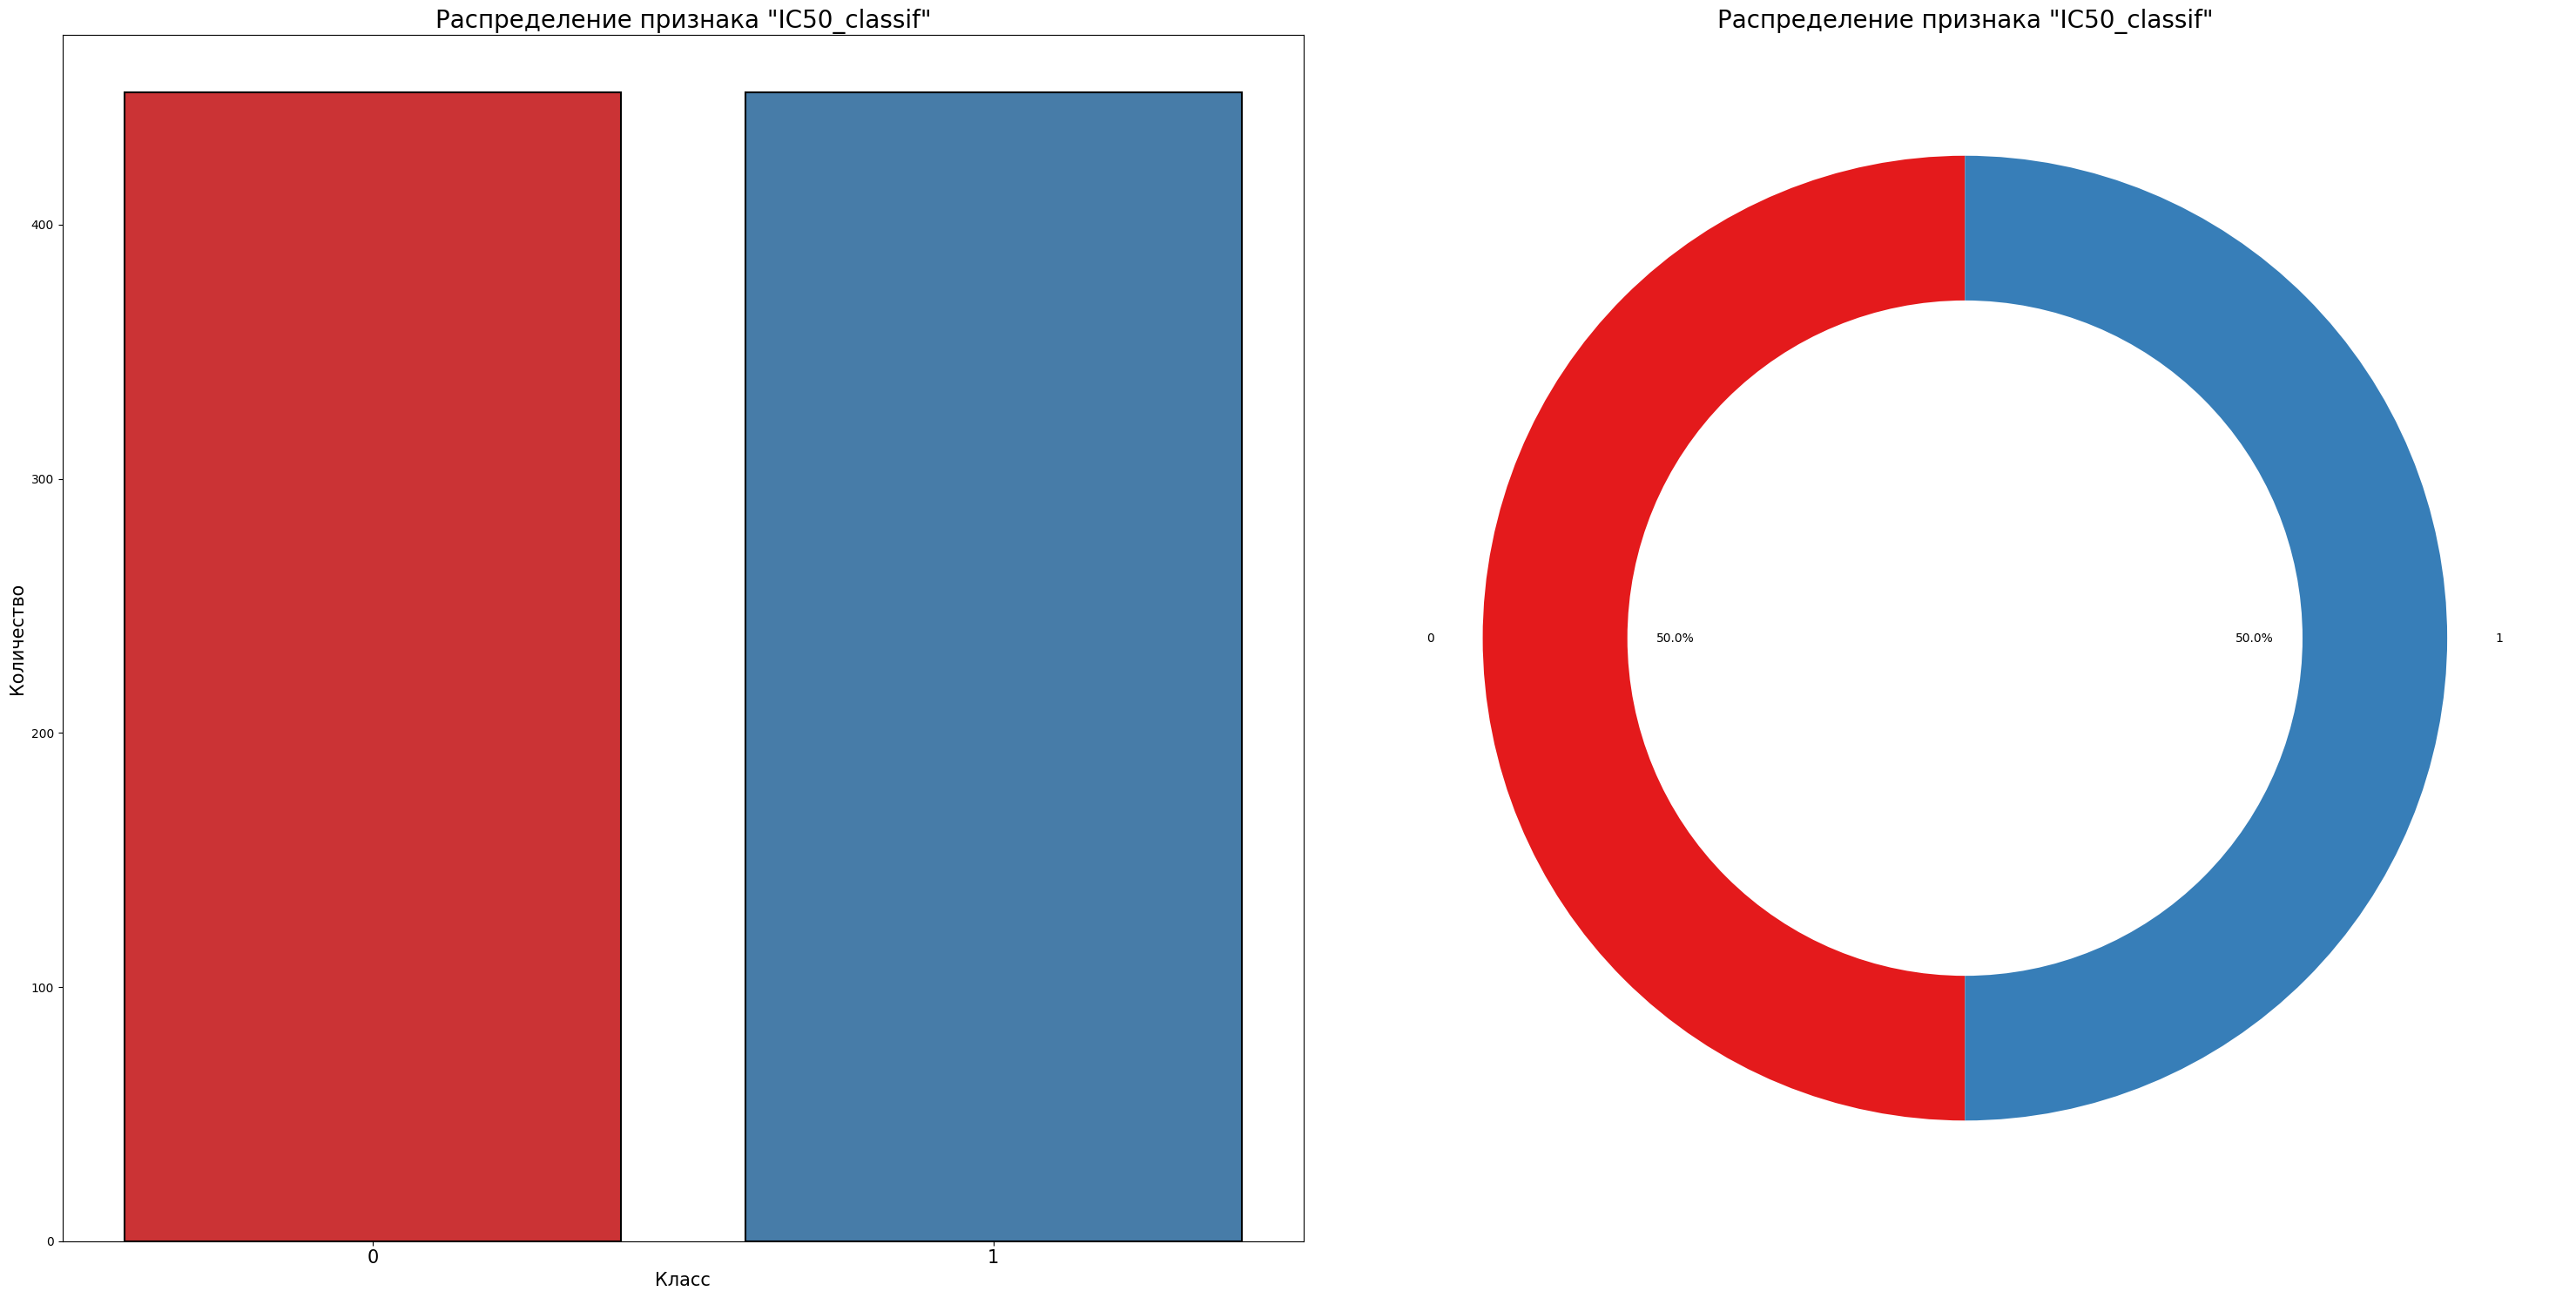

------------------------------------------------------------------------------------------------------------------------------------------------------


Распределение целевой переменной
------------------------------------------------------------------------------------------------------------------------------------------------------


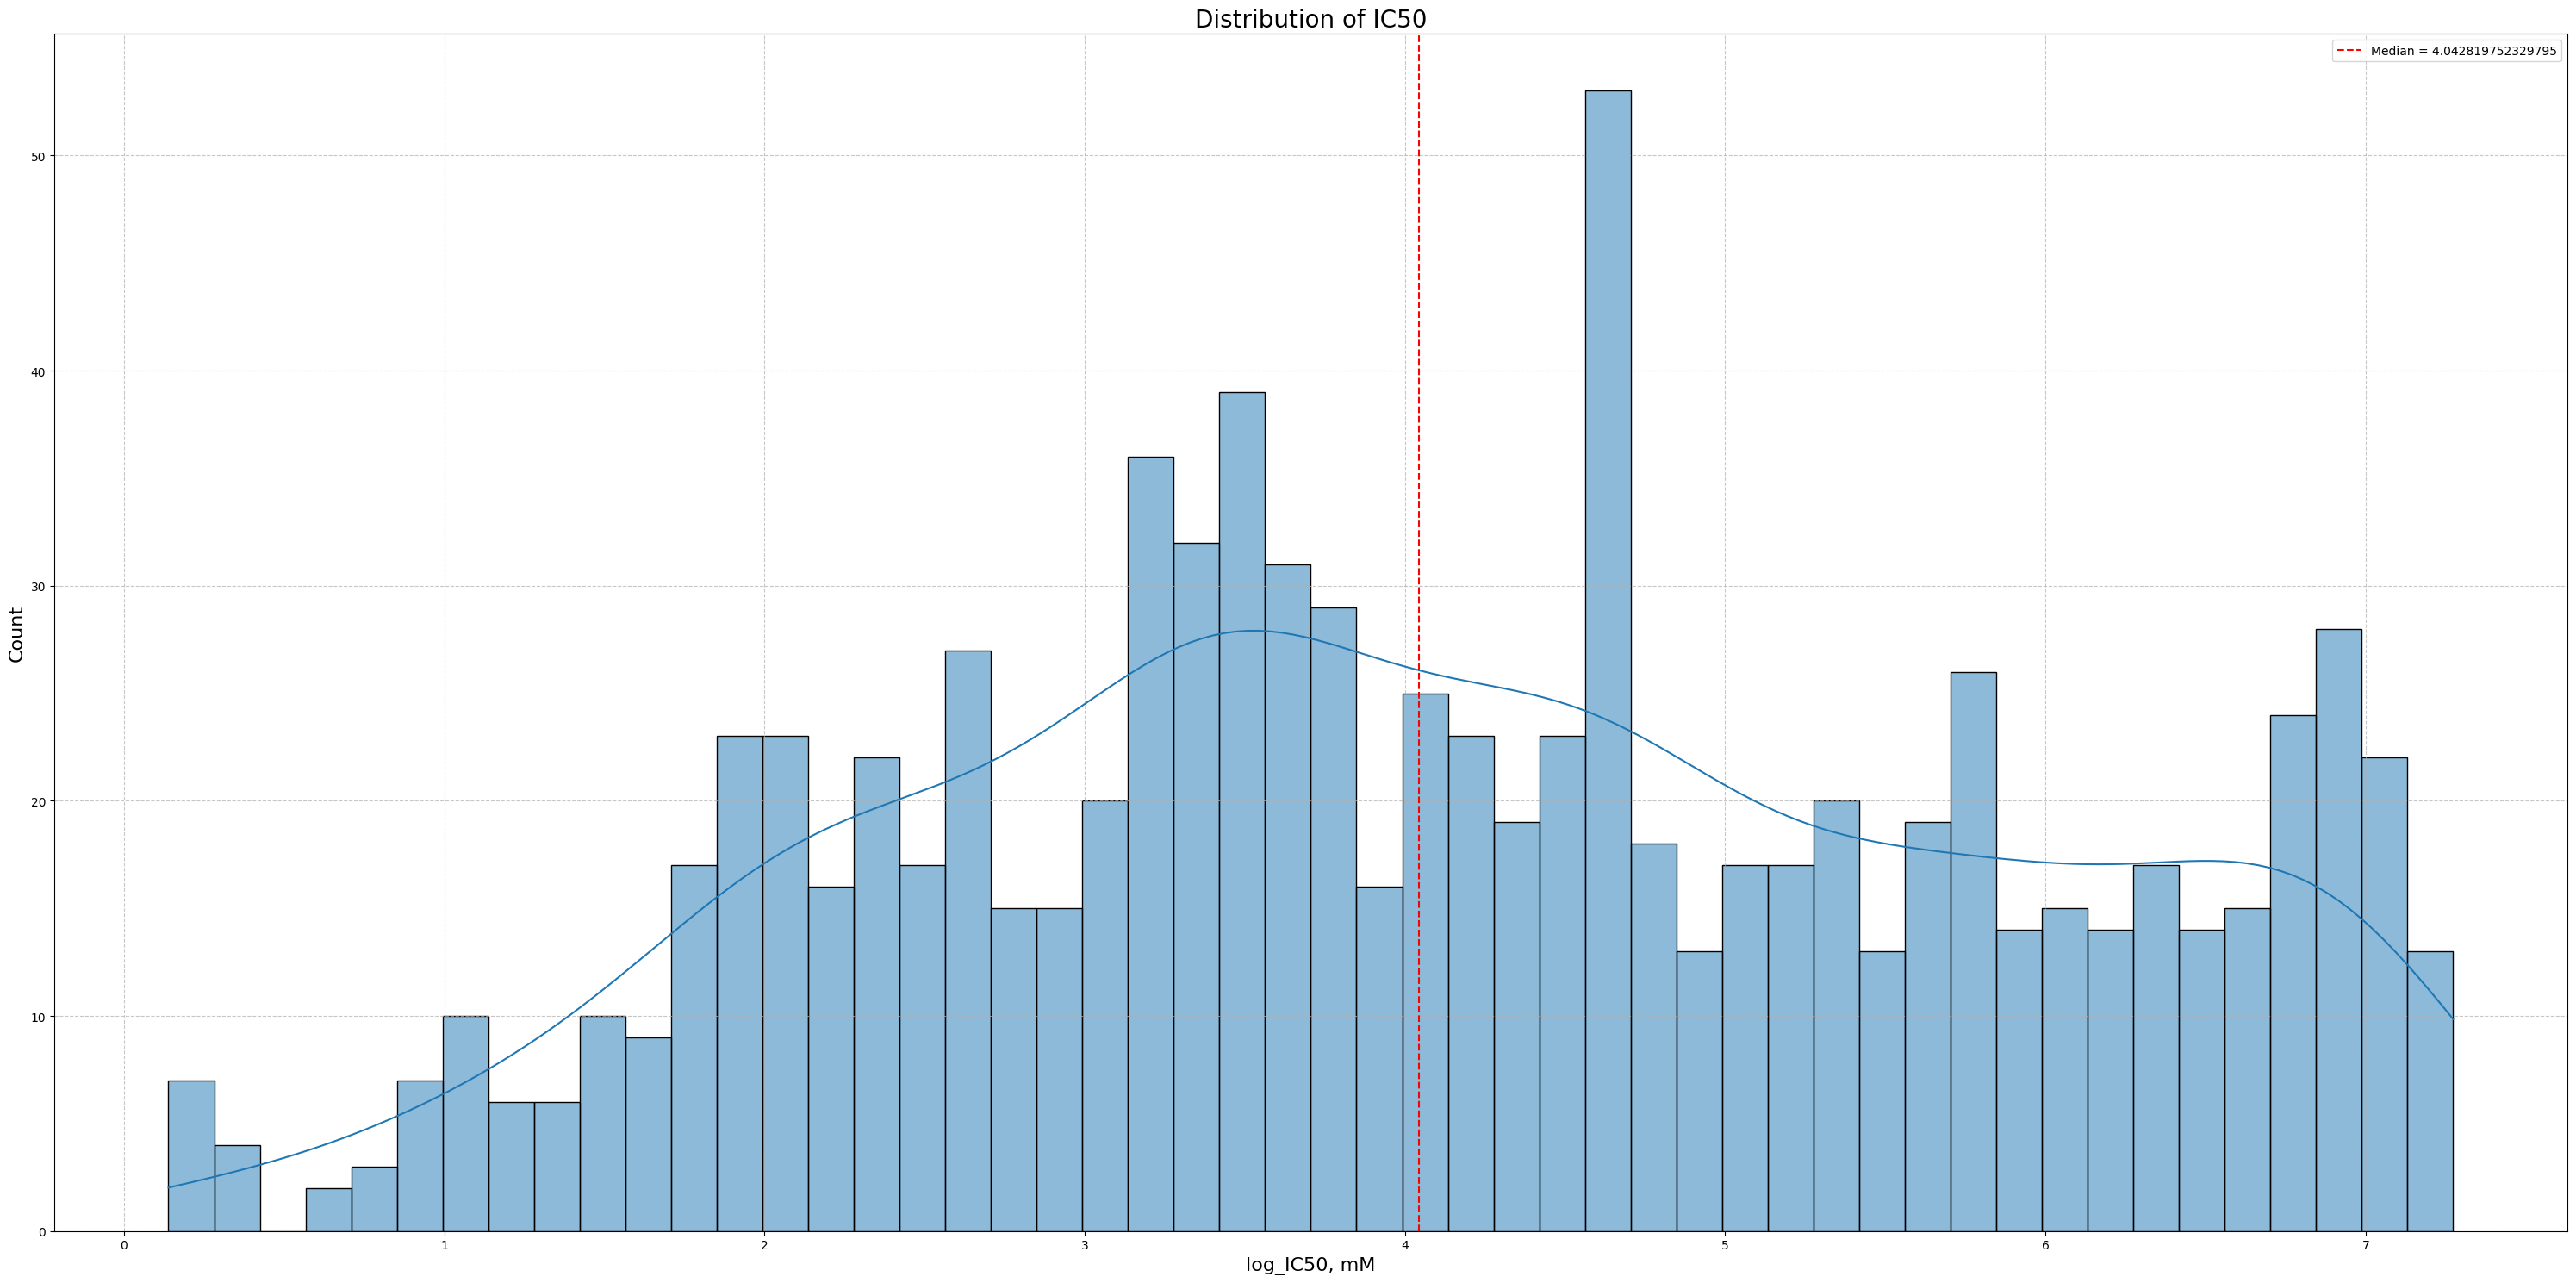

------------------------------------------------------------------------------------------------------------------------------------------------------


In [17]:
# Вычисляем медиану IC50
median_ic50 = molecule_df['log_IC50, mM'].median()
print(f'\nМедианное значение IC50: {median_ic50}')
print('-' * 45)
print('\n\n')


# Создаем целевую переменную (1 - превышает, 0 - не превышает)
molecule_df['IC50_classif'] = (molecule_df['log_IC50, mM'] > median_ic50).astype(int)
print('Уникальные значения признака "IC50_classif":\n')
display(molecule_df['IC50_classif'].value_counts())
print('-' * 45)




# Применяем функцию 'median_target_distribution_plot()' для построения графика распределения целевой переменной
median_target_distribution_plot(
    target = molecule_df['IC50_classif'],
    title1 = 'Распределение признака "IC50_classif"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной:',
    color_palette = 'Set1',
    figsize = (30, 15)
)

# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    data = molecule_df,
    target = 'log_IC50, mM',
    median_target = median_ic50,
    title = 'Distribution of IC50',
    main_title = 'Распределение целевой переменной',
    figsize = (30, 15)
)

**Вывод:**

Как видно по графику, распределение целевой переменной - равномерное, следовательно балансировка не требуется.

**Разделение данных.**

Разделим данные на тренировочную и тестовую выборки:

In [18]:
# Разделяем данные на матрицу наблюдений и вектор правильных ответов
X = molecule_df.drop(columns = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI', 'IC50_classif'])
y = molecule_df['IC50_classif']


# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)


# Удаляем дублирующиеся столбцы
duplicated_features = ['Unnamed: 0', 'Unnamed: 0.1']
X_train.drop(columns = duplicated_features, axis = 1, inplace = True)
X_test.drop(columns = duplicated_features, axis = 1, inplace = True)


# Восстанавливаем индексы
X_train = X_train.reset_index(drop = True)
X_test = X_test.reset_index(drop = True)

Выводим информацию по тренировочной и тестовой выборкам:

In [19]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train.head(),
    data_name = 'X_train',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')



# Информация по тестовой выборке
check_data_inf(
    data = X_test.head(),
    data_name = 'X_test',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 217.
----------------------------------------


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_thiophene,fr_unbrch_alkane,fr_urea,SI_category,fr_amide_presence,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,SI_and_8_classif,SI_classif
0,5.856558,5.856558,0.246833,0.246833,0.701837,28.440000,334.463,308.255,334.204513,130,...,0,0,0,экстремально высокий,Без амидной группы,Без группы,С группой,Без группы,0,1
1,12.679078,12.679078,0.324537,-1.636782,0.687651,22.450000,266.252,256.172,266.057909,98,...,0,0,0,экстремально высокий,Без амидной группы,Без группы,Без группы,Без группы,0,1
2,11.753981,11.753981,0.034554,-0.365579,0.662186,35.958333,352.456,328.264,352.145678,132,...,1,0,0,очень высокий,С амидной группой,Без группы,Без группы,Без группы,0,0
3,6.821111,6.821111,0.213542,0.213542,0.738218,51.000000,207.361,182.161,207.198700,86,...,0,0,0,экстремально высокий,Без амидной группы,Без группы,Без группы,Без группы,1,1
4,13.242698,13.242698,0.045904,-0.236099,0.878757,27.954545,322.449,299.265,322.151513,120,...,0,0,0,экстремально высокий,Без амидной группы,Без группы,С группой,Без группы,0,1


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 217.
----------------------------------------


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_thiophene,fr_unbrch_alkane,fr_urea,SI_category,fr_amide_presence,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,SI_and_8_classif,SI_classif
0,11.443183,11.443183,0.096481,-1.486768,0.498725,12.812500,244.192,240.160,244.001474,84,...,0,0,0,низкий,Без амидной группы,Без группы,Без группы,Без группы,0,0
1,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,334.237,345.067129,122,...,0,0,0,умеренный,Без амидной группы,Без группы,С группой,Без группы,0,0
2,10.748074,10.748074,0.007726,-0.824114,0.668512,39.761905,295.335,274.167,295.141973,116,...,0,0,0,умеренный,Без амидной группы,Без группы,Без группы,Без группы,0,0
3,12.465817,12.465817,0.263325,-2.956304,0.277881,25.781250,468.579,427.251,468.286542,182,...,0,1,0,высокий,Без амидной группы,Без группы,Без группы,Без группы,0,0
4,5.100343,5.100343,0.393133,0.393133,0.343756,40.866667,412.706,364.322,412.381750,170,...,0,5,0,экстремально высокий,Без амидной группы,Без группы,Без группы,Без группы,1,1


------------------------------------------------------------------------------------------------------------------------------------------------------


**Создание новых признаков.**

Обучаем внутренний пайплайн `feature_union` для создания новых признаков:

In [20]:
# Извлекаем 'FeatureUnion' из пайплайна и обучаем его
feature_union_step = preprocessing_pipeline.named_steps['feature_union']
feature_union_step.fit(X_train, y_train)

FeatureUnion(transformer_list=[('molecular_properties', MolecularProperties()),
                               ('functional_groups', FunctionalGroups()),
                               ('topological_descriptors',
                                TopologicalDescriptors()),
                               ('transformations', Transformations())])

Создаём новые признаки:

In [21]:
# Применим пайплайн к тренировочным и тестовым данным 
X_train_transformed = feature_union_step.transform(X_train)
X_test_transformed = feature_union_step.transform(X_test)


Данные таблицы "Molecular properties features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
------------------------------------------------------------




Данные таблицы "Functional groups features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 8.
----------------------------------------
------------------------------------------------------------------------------------------




Данные таблицы "Topological descriptors features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 4.
----------------------------------------
--------------------------------------------------------------------------------




Данные таблицы "Transformations features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
---------------------------------------------------

Из полученных массивов создаём **DataFrame**:

In [22]:
# Создадим массив в названиями созданных столбцов
feature_names = (
    ['MolWt_TPSA', 'MolWt_per_Heteroatoms', 'TPSA_per_MolLogP'] +
    
    ['total_functional_groups', 'fr_amide_plus_ester', 'fr_benzene_times_nitro', 
     'fr_Al_OH_per_benzene', 'fr_amide_presence', 'fr_aldehyde_presence', 
     'fr_aniline_presence', 'fr_amidine_presence'] +
    
    ['PEOE_VSA_total', 'SMR_VSA_ratio', 'Chi0_times_Kappa1', 'TPSA_times_FractionCSP3'] +
    ['log_MolWt', 'MolLogP_squared', 'NumRotatableBonds_squared']
)



# Преобразуем результат обратно в DataFrame 
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns = feature_names,
    index = X_train.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns = feature_names,
    index = X_test.index
)



# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_transformed_df,
    data_name = 'X_train_transformed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')



# Информация по тестовой выборке
check_data_inf(
    data = X_test_transformed_df,
    data_name = 'X_test_transformed_df',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_transformed_df" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 18.
----------------------------------------


,MolWt_TPSA,MolWt_per_Heteroatoms,TPSA_per_MolLogP,total_functional_groups,fr_amide_plus_ester,fr_benzene_times_nitro,fr_Al_OH_per_benzene,fr_amide_presence,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,PEOE_VSA_total,SMR_VSA_ratio,Chi0_times_Kappa1,TPSA_times_FractionCSP3,log_MolWt,MolLogP_squared,NumRotatableBonds_squared
0,15923.78343,111.487295,7.961805,11.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,149.360916,4.119361e-01,285.915036,19.476818,5.815512,35.758008,9.0
1,14004.85520,66.562834,20.281317,16.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,113.994086,3.315551e+00,156.118042,6.575000,5.588192,6.726346,0.0
2,28714.59032,50.350785,21.342310,10.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,145.177915,1.445471e+11,303.433991,57.508235,5.867759,14.571779,9.0
3,5395.53322,207.358926,7.813345,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.234527,0.000000e+00,108.266752,26.020000,5.339272,11.090232,4.0
4,14558.57235,64.489671,10.204312,11.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,134.011377,9.496942e+10,250.321159,26.558824,5.779041,19.577085,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,12581.97432,108.483638,8.533840,9.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,144.185324,9.531400e+10,291.525205,20.250476,5.788283,20.522712,25.0
719,4433.90802,177.782111,2.420184,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,159.839111,4.736863e+10,339.742096,9.352500,5.876519,26.548256,9.0
720,29641.79000,59.641343,16.478671,19.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,177.698241,2.491679e+00,386.270326,12.347826,6.036653,18.564034,16.0
721,29560.74597,43.811174,20.366195,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,155.188097,1.603381e+00,396.808712,11.837368,5.979648,13.550497,16.0


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_transformed_df" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 18.
----------------------------------------


,MolWt_TPSA,MolWt_per_Heteroatoms,TPSA_per_MolLogP,total_functional_groups,fr_amide_plus_ester,fr_benzene_times_nitro,fr_Al_OH_per_benzene,fr_amide_presence,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,PEOE_VSA_total,SMR_VSA_ratio,Chi0_times_Kappa1,TPSA_times_FractionCSP3,log_MolWt,MolLogP_squared,NumRotatableBonds_squared
0,33246.74080,22.199253,-88.305876,15.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,88.203045,9.132210e+10,122.868196,27.230000,5.502042,2.377147,4.0
1,22480.65750,34.532465,19.858459,21.0,0.0,0.0,0.000000e+00,0.0,0.0,1.0,0.0,132.969341,1.756166e+11,287.439094,10.015385,5.847378,10.746595,9.0
2,25322.02290,49.222418,26.751950,6.0,0.0,0.0,1.000000e+10,0.0,0.0,0.0,0.0,122.250891,1.918385e+11,220.886740,62.876000,5.691491,10.272025,4.0
3,41155.29357,52.064275,17.126867,13.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,192.683531,1.834941e+11,593.692975,76.373913,6.151837,26.298435,196.0
4,10202.09232,206.351968,3.128559,13.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,186.585749,0.000000e+00,487.189500,22.954286,6.025156,62.432122,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,3623.07684,139.240608,14.702226,3.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,62.136250,0.000000e+00,47.513863,26.020000,4.943370,3.132192,1.0
177,24600.45960,57.231571,17.589778,17.0,0.0,0.0,0.000000e+00,0.0,0.0,1.0,0.0,150.262400,4.259017e-01,288.753005,7.164000,5.841775,16.587863,9.0
178,24069.54446,57.895570,17.494824,20.0,1.0,0.0,0.000000e+00,1.0,0.0,1.0,0.0,149.359937,2.426041e+00,283.546647,6.929000,5.853277,15.686352,36.0
179,28200.21244,60.739565,29.528716,13.0,0.0,0.0,2.000000e+00,0.0,0.0,0.0,0.0,153.603719,1.690608e+00,362.412095,46.428000,5.901097,6.867020,16.0


------------------------------------------------------------------------------------------------------------------------------------------------------


Объединим созданные признаки с основными:

In [23]:
# Объединяем признаки тренеровочной выборки
X_train_full = pd.concat(
    [X_train, X_train_transformed_df],
    axis = 1
)


# Объединяем признаки тестовой выборки
X_test_full = pd.concat(
    [X_test, X_test_transformed_df],
    axis = 1
)



# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_full,
    data_name = 'X_train_full',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')



# Информация по тестовой выборке
check_data_inf(
    data = X_test_full,
    data_name = 'X_test_full',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_full" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 235.
----------------------------------------


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,PEOE_VSA_total,SMR_VSA_ratio,Chi0_times_Kappa1,TPSA_times_FractionCSP3,log_MolWt,MolLogP_squared,NumRotatableBonds_squared
0,5.856558,5.856558,0.246833,0.246833,0.701837,28.440000,334.463,308.255,334.204513,130,...,0.0,1.0,0.0,149.360916,4.119361e-01,285.915036,19.476818,5.815512,35.758008,9.0
1,12.679078,12.679078,0.324537,-1.636782,0.687651,22.450000,266.252,256.172,266.057909,98,...,0.0,0.0,0.0,113.994086,3.315551e+00,156.118042,6.575000,5.588192,6.726346,0.0
2,11.753981,11.753981,0.034554,-0.365579,0.662186,35.958333,352.456,328.264,352.145678,132,...,0.0,0.0,0.0,145.177915,1.445471e+11,303.433991,57.508235,5.867759,14.571779,9.0
3,6.821111,6.821111,0.213542,0.213542,0.738218,51.000000,207.361,182.161,207.198700,86,...,0.0,0.0,0.0,93.234527,0.000000e+00,108.266752,26.020000,5.339272,11.090232,4.0
4,13.242698,13.242698,0.045904,-0.236099,0.878757,27.954545,322.449,299.265,322.151513,120,...,0.0,1.0,0.0,134.011377,9.496942e+10,250.321159,26.558824,5.779041,19.577085,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,11.748658,11.748658,0.231039,-0.306910,0.453065,29.458333,325.452,298.236,325.204179,128,...,0.0,0.0,0.0,144.185324,9.531400e+10,291.525205,20.250476,5.788283,20.522712,25.0
719,5.583517,5.583517,0.363472,0.363472,0.743057,35.192308,355.566,318.270,355.287515,144,...,0.0,0.0,0.0,159.839111,4.736863e+10,339.742096,9.352500,5.876519,26.548256,9.0
720,12.383317,12.383317,0.146735,-0.678187,0.685037,21.100000,417.490,398.338,417.114712,150,...,0.0,0.0,0.0,177.698241,2.491679e+00,386.270326,12.347826,6.036653,18.564034,16.0
721,14.205155,14.205155,0.126096,-1.805806,0.496490,10.785714,394.301,381.197,394.066423,146,...,0.0,0.0,0.0,155.188097,1.603381e+00,396.808712,11.837368,5.979648,13.550497,16.0


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_full" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 235.
----------------------------------------


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_aldehyde_presence,fr_aniline_presence,fr_amidine_presence,PEOE_VSA_total,SMR_VSA_ratio,Chi0_times_Kappa1,TPSA_times_FractionCSP3,log_MolWt,MolLogP_squared,NumRotatableBonds_squared
0,11.443183,11.443183,0.096481,-1.486768,0.498725,12.812500,244.192,240.160,244.001474,84,...,0.0,0.0,0.0,88.203045,9.132210e+10,122.868196,27.230000,5.502042,2.377147,4.0
1,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,334.237,345.067129,122,...,0.0,1.0,0.0,132.969341,1.756166e+11,287.439094,10.015385,5.847378,10.746595,9.0
2,10.748074,10.748074,0.007726,-0.824114,0.668512,39.761905,295.335,274.167,295.141973,116,...,0.0,0.0,0.0,122.250891,1.918385e+11,220.886740,62.876000,5.691491,10.272025,4.0
3,12.465817,12.465817,0.263325,-2.956304,0.277881,25.781250,468.579,427.251,468.286542,182,...,0.0,0.0,0.0,192.683531,1.834941e+11,593.692975,76.373913,6.151837,26.298435,196.0
4,5.100343,5.100343,0.393133,0.393133,0.343756,40.866667,412.706,364.322,412.381750,170,...,0.0,0.0,0.0,186.585749,0.000000e+00,487.189500,22.954286,6.025156,62.432122,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,5.884213,5.884213,0.453981,0.453981,0.588383,48.000000,139.242,122.106,139.136100,58,...,0.0,0.0,0.0,62.136250,0.000000e+00,47.513863,26.020000,4.943370,3.132192,1.0
177,12.796013,12.796013,0.250728,-0.296951,0.728654,14.923077,343.390,326.254,343.143310,128,...,0.0,1.0,0.0,150.262400,4.259017e-01,288.753005,7.164000,5.841775,16.587863,9.0
178,12.310058,12.310058,0.239946,-0.337469,0.573075,10.769231,347.374,330.238,347.126991,130,...,0.0,1.0,0.0,149.359937,2.426041e+00,283.546647,6.929000,5.853277,15.686352,36.0
179,11.051605,11.051605,0.139362,-0.952221,0.800035,33.884615,364.438,336.214,364.188589,144,...,0.0,0.0,0.0,153.603719,1.690608e+00,362.412095,46.428000,5.901097,6.867020,16.0


------------------------------------------------------------------------------------------------------------------------------------------------------


Подсчитаем количество типов данных по признакам:

In [24]:
# Выводим данные таблицы 'X_train_full'
check_features_dtypes(
    data = X_train_full,
    data_name = 'X_train_full',
    length1 = 65,
    length2 = 40
)

В таблице "X_train_full" представлены признаки следующих типов:
-----------------------------------------------------------------

Количество признаков типа 'object': 5
Количество признаков типа 'int64': 106
Количество признаков типа 'float64': 122
Количество признаков типа 'bool': 0
----------------------------------------


В данных присутствуют признаки типа `object`, так как модели не работают с такими типами данных, избавимся от них:

In [25]:
# Создаём функцию для удалени признаков типа 'object'
def remove_non_numeric_columns(data):
    return data.select_dtypes(include = [np.number])


# Применяем полученную функцию к тренировочному и тестовому DataFrame
X_train_full = remove_non_numeric_columns(X_train_full)
X_test_full = remove_non_numeric_columns(X_test_full)




# Выводим данные таблицы 'X_train_full'
check_features_dtypes(
    data = X_train_full,
    data_name = 'X_train_full',
    length1 = 0,
    length2 = 65
)

print('\n\n')


# Выводим данные таблицы 'X_test_full'
check_features_dtypes(
    data = X_test_full,
    data_name = 'X_test_full',
    length1 = 0,
    length2 = 65
)

В таблице "X_train_full" представлены признаки следующих типов:


Количество признаков типа 'object': 0
Количество признаков типа 'int64': 106
Количество признаков типа 'float64': 122
Количество признаков типа 'bool': 0
-----------------------------------------------------------------



В таблице "X_test_full" представлены признаки следующих типов:


Количество признаков типа 'object': 0
Количество признаков типа 'int64': 106
Количество признаков типа 'float64': 122
Количество признаков типа 'bool': 0
-----------------------------------------------------------------


**Преобразовываем данные.**

Теперь избавимся от мультиколлинеарности и стандартизируем данные:

In [26]:
# Извлечение шагов
feature_selector = preprocessing_pipeline.named_steps['feature_selector']
S_scaler = preprocessing_pipeline.named_steps['S_scaler']


# Создание нового пайплайна с 'feature_selector' и 'S_scaler'
partial_pipeline = pipeline.Pipeline(
    [
        ('feature_selector', feature_selector),
        ('S_scaler', S_scaler)
    ]
)


# Обучаем созданный пайплайн на тренировочной выборке
partial_pipeline.fit(X_train_full, y_train)

Pipeline(steps=[('feature_selector', FeatureSelector()),
                ('S_scaler', StandardScaler())])

Преобразовываем тренировочную и тестовую выборки:

In [27]:
# Применим пайплайн к тренировочным и тестовым данным 
X_train_processed_full = partial_pipeline.transform(X_train_full)
X_test_processed_full = partial_pipeline.transform(X_test_full)


# Получаем список оставшихся признаков
fs_step = partial_pipeline.named_steps['feature_selector']
remaining_features = X_train_full.columns.difference(fs_step.to_drop_corr + fs_step.to_drop_var, sort = False)



# Преобразуем результат обратно в DataFrame 
X_train_processed_df = pd.DataFrame(
    X_train_processed_full,
    columns = remaining_features,
    index = X_train_full.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed_full,
    columns =remaining_features,
    index = X_test_full.index
)



# Выведем результаты
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_processed_df,
    data_name = 'X_train_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')



# Информация по тестовой выборке
check_data_inf(
    data = X_test_processed_df,
    data_name = 'X_test_processed_df',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_processed_df" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 105.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_thiazole,fr_thiophene,fr_unbrch_alkane,SI_and_8_classif,SI_classif,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,-1.496602,0.422613,0.771519,0.579771,-0.081941,-0.172284,-0.720975,-0.482466,-0.231601,0.709602,...,-0.266667,-0.303554,-0.177731,-0.685210,1.006940,-0.064531,-0.017568,-0.338656,-0.806000,-0.332149
1,0.527403,0.904784,-0.394927,0.514586,-0.554818,-0.694608,-0.970049,-0.465835,0.425592,0.670103,...,-0.266667,-0.303554,-0.177731,-0.685210,1.006940,-0.064565,0.133615,-0.338656,-0.806000,-0.857136
2,0.252959,-0.894628,0.392277,0.397569,0.511590,-0.034503,1.347721,0.555049,-0.313054,0.077316,...,-0.266667,3.294307,-0.177731,-0.685210,-0.993108,-0.064578,0.146636,-0.338656,0.736551,1.215385
3,-1.210453,0.216033,0.750903,0.746949,1.699045,-1.145565,-0.554926,-0.589790,-0.967502,0.838770,...,-0.266667,-0.303554,-0.177731,1.459407,1.006940,-0.064458,-0.019390,-0.338656,-0.806000,-0.065901
4,0.694610,-0.824197,0.472459,1.392750,-0.120265,-0.264281,0.954612,0.555048,-0.403346,-0.483621,...,3.750000,-0.303554,-0.177731,-0.685210,1.006940,-0.064567,0.009951,-0.338656,0.207477,-0.043975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.251380,0.324610,0.428609,-0.563375,-0.001549,-0.241286,0.655849,-0.479027,-0.231089,0.700544,...,-0.266667,-0.303554,-0.177731,-0.685210,1.006940,-0.064533,-0.010548,-0.338656,0.211154,-0.300668
719,-1.577604,1.146384,0.843749,0.769183,0.451116,-0.010688,0.083725,-0.482669,-0.749877,0.230117,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064481,-0.085575,-0.338656,-0.300500,-0.744117
720,0.439661,-0.198519,0.198692,0.502574,-0.661393,0.463493,-0.416552,0.557248,0.434471,-0.335264,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064571,0.086950,-0.338656,-0.806000,-0.622234
721,0.980138,-0.326590,-0.499596,-0.363831,-1.475648,0.285924,-0.703184,-0.304289,0.607120,-1.303146,...,-0.266667,-0.303554,-0.177731,1.459407,1.006940,-0.064583,0.134657,-0.338656,-0.806000,-0.643005


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_processed_df" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 105.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_thiazole,fr_thiophene,fr_unbrch_alkane,SI_and_8_classif,SI_classif,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,0.160756,-0.510352,-0.302029,-0.353559,-1.315644,-0.863532,1.780140,0.559264,2.296748,-1.732256,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064599,-1.198955,-0.338656,0.168554,-0.016665
1,0.552605,-0.468304,-2.184035,-1.056662,-1.369489,-0.089109,0.528003,0.552297,1.154219,-0.893501,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064590,0.128426,-0.338656,1.068112,-0.717143
2,-0.045459,-1.061101,0.108325,0.426638,0.811860,-0.471906,1.224172,-0.471246,-0.265352,0.017607,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064578,0.213022,1.475033,1.241226,1.433804
3,0.464136,0.524951,-1.212053,-1.368374,-0.291834,0.854706,0.353155,0.492597,-0.231089,0.701536,...,-0.266667,-0.303554,0.788429,-0.685210,-0.993108,-0.064576,0.094904,-0.338656,1.152177,1.983047
4,-1.720945,1.330435,0.862116,-1.065667,0.899075,0.426860,-2.215418,-0.592477,-0.231368,0.760929,...,-0.266667,-0.303554,4.653068,1.459407,1.006940,-0.064459,-0.076881,-0.338656,-0.806000,-0.190647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-1.488398,1.708016,0.899797,0.058433,1.462212,-1.667184,0.690443,-0.603011,0.127272,-0.483112,...,-0.266667,-0.303554,-0.177731,-0.685210,1.006940,-0.064510,0.065149,-0.338656,-0.806000,-0.065901
177,0.562094,0.446785,0.434776,0.703003,-1.149026,-0.103926,-0.554926,-0.504065,0.884829,-1.319795,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064572,0.100585,-0.338656,-0.806000,-0.833169
178,0.417928,0.379878,0.409685,-0.011909,-1.476949,-0.073419,-0.395263,-0.482662,1.260989,-2.026415,...,-0.266667,-0.303554,-0.177731,1.459407,1.006940,-0.064572,0.099420,-0.338656,-0.806000,-0.842731
179,0.044589,-0.244271,0.028994,1.031010,0.347881,0.057249,-0.075938,-0.478956,-0.226828,0.099772,...,-0.266667,-0.303554,-0.177731,-0.685210,-0.993108,-0.064570,0.247098,-0.338656,-0.806000,0.764520


------------------------------------------------------------------------------------------------------------------------------------------------------


Создадим функцию для визуализации распределения:

In [28]:
# Создаём функцию 'features_distribution_plot()' для построения графика распределения признаков
def features_distribution_plot(data, title = None, figsize = None):
    
    
    # Создаём заголовок для графика
    print('График распределения признаков:')
    print('-' * 150)
    
    
    """
    Функция для построения графиков распределения признаков.
    
    Параметры:
    - data: pandas DataFrame с данными.
    - features: список признаков для анализа.
    - title: заголовок графика.
    - figsize: размер графика.
    
    """
    
    
    # Задаём размер графика
    fig, ax = plt.subplots(figsize = figsize)

    # Построение плотностей распределения
    for column in data.columns:
    
        sns.kdeplot(
            data[column], 
            label = column, 
            ax = ax
        )



    # Настройка легенды: выносим за пределы графика
    plt.legend(
        bbox_to_anchor = (1.05, 1),
        loc = 'upper left',
        fontsize = 10
    )

    # Настройка графика
    plt.title(title, fontsize = 20)
    plt.xlabel('Значение', fontsize = 15)
    plt.ylabel('Плотность', fontsize = 15)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.tight_layout()  
    
    
    
    # Выводим график
    plt.show()
    print('-' * 150)

Строим графики для тренировочной и тестовой выборок:


График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


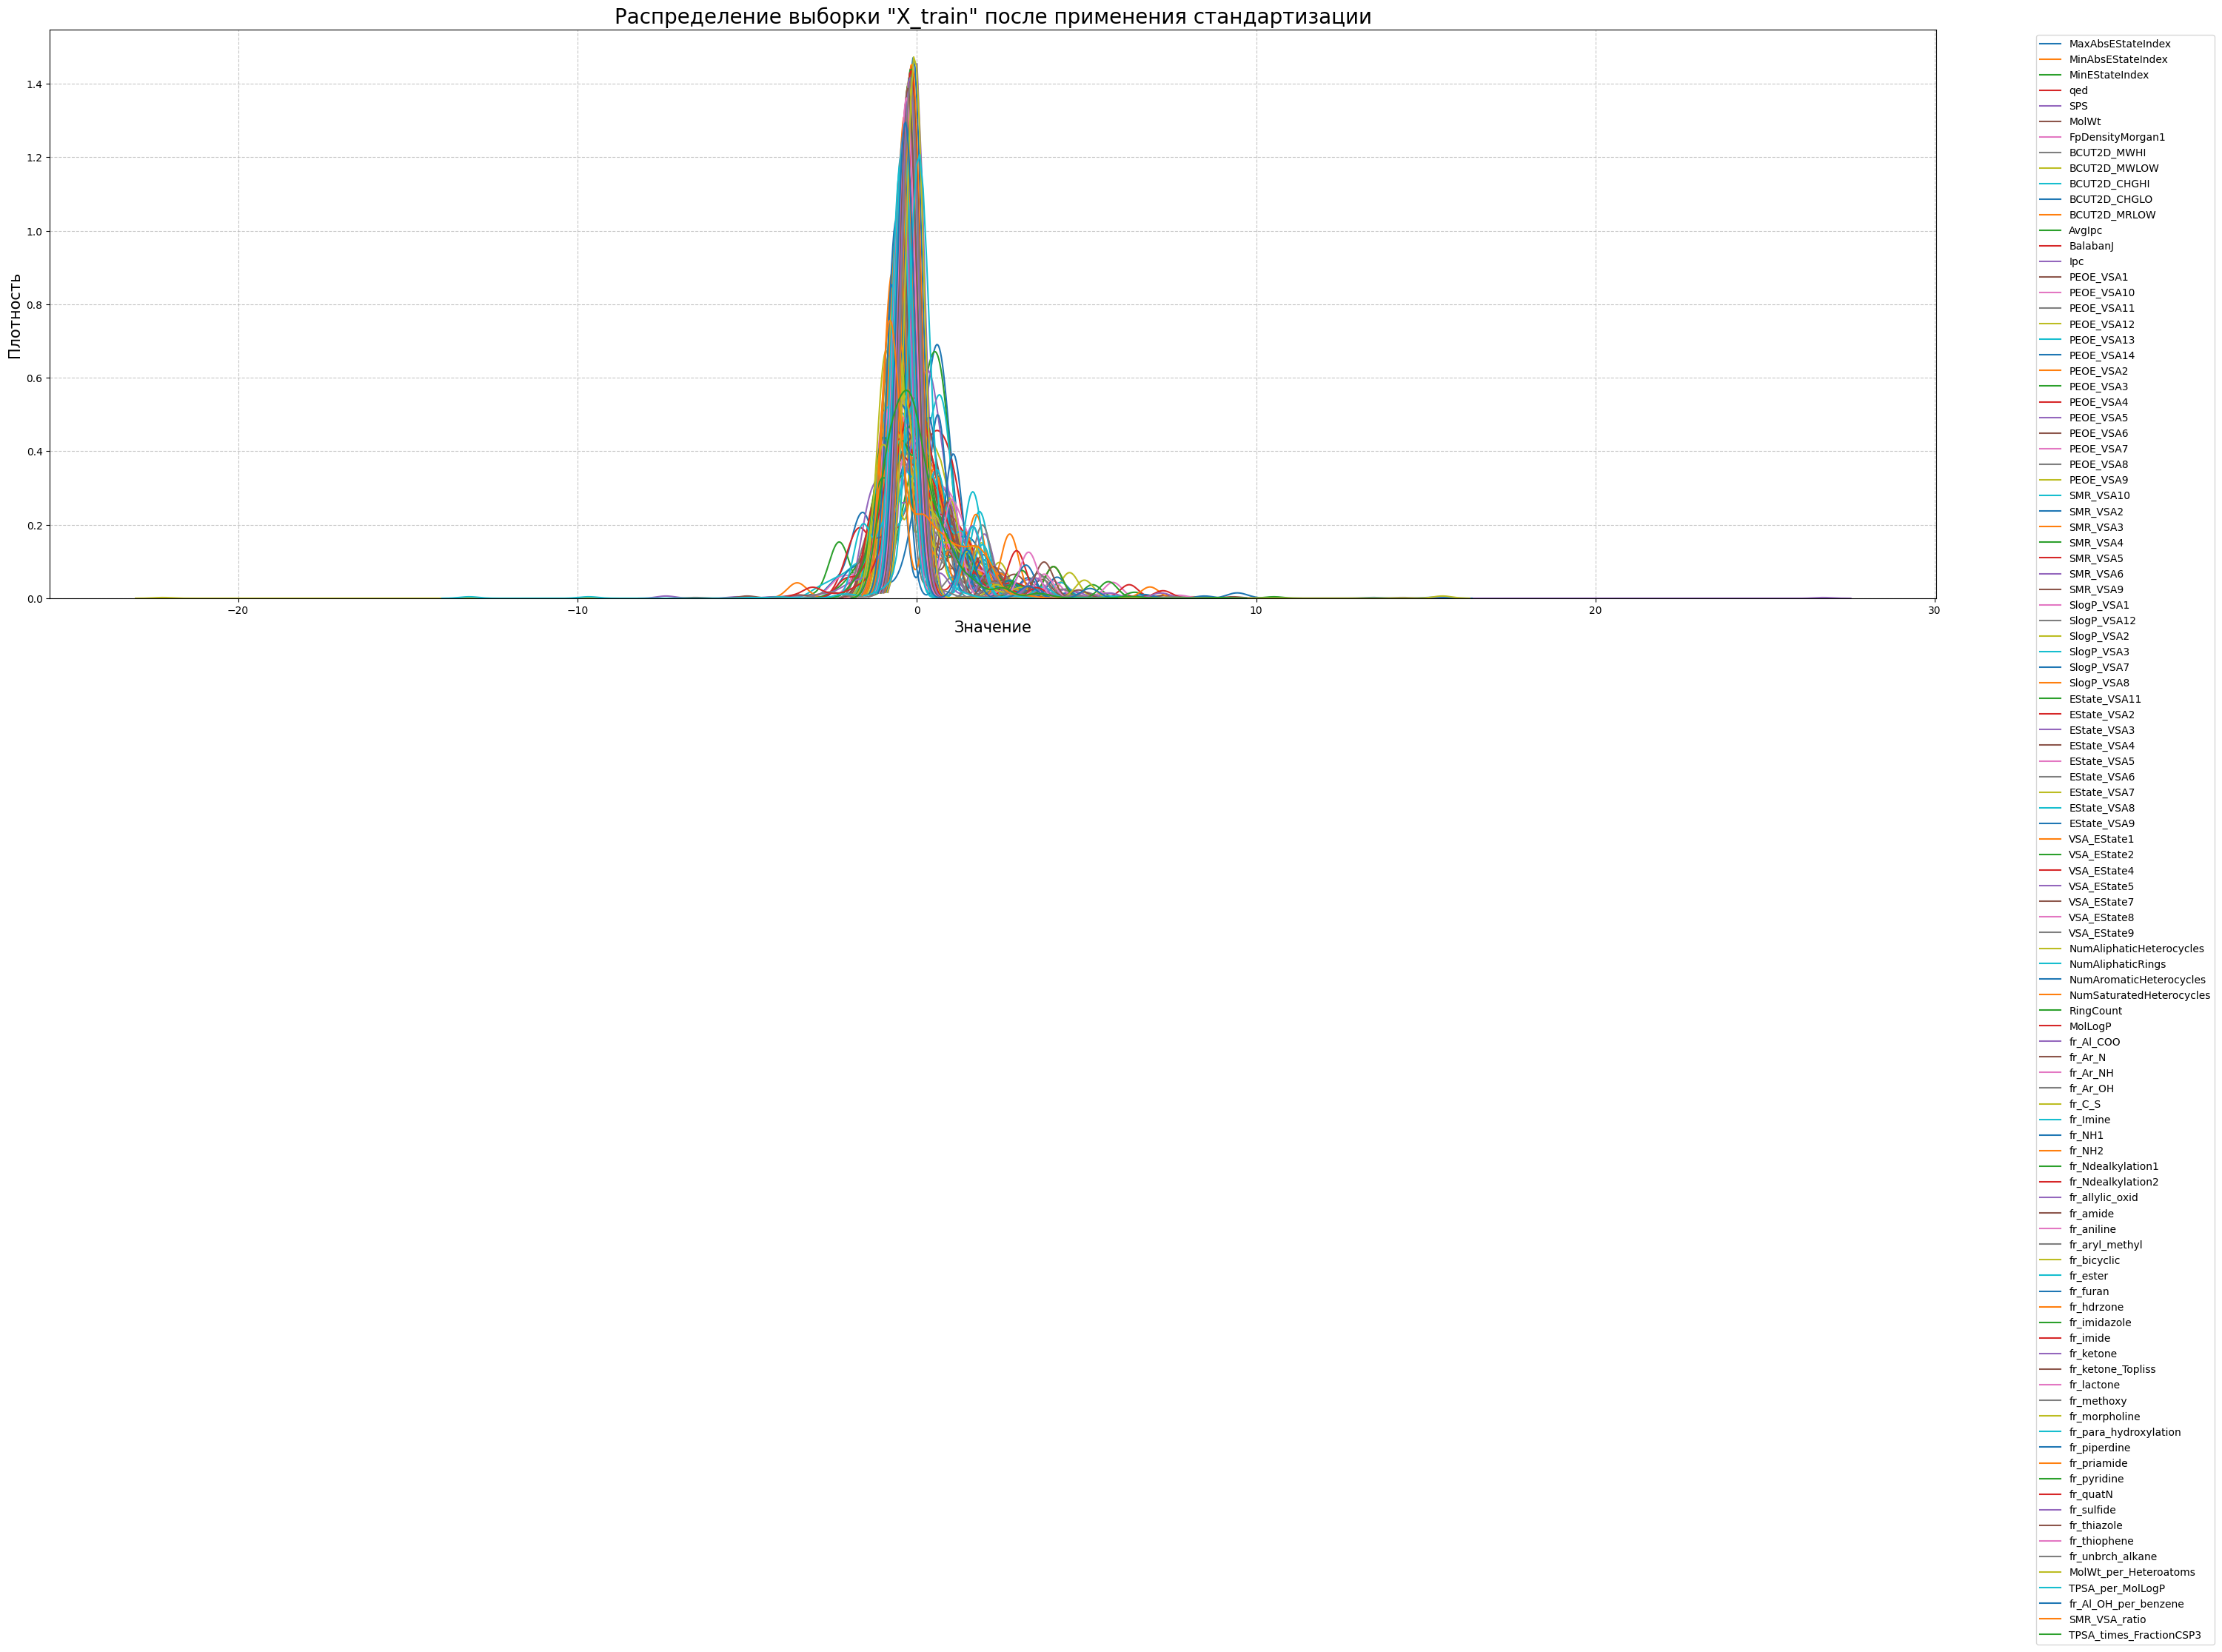

------------------------------------------------------------------------------------------------------------------------------------------------------



График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


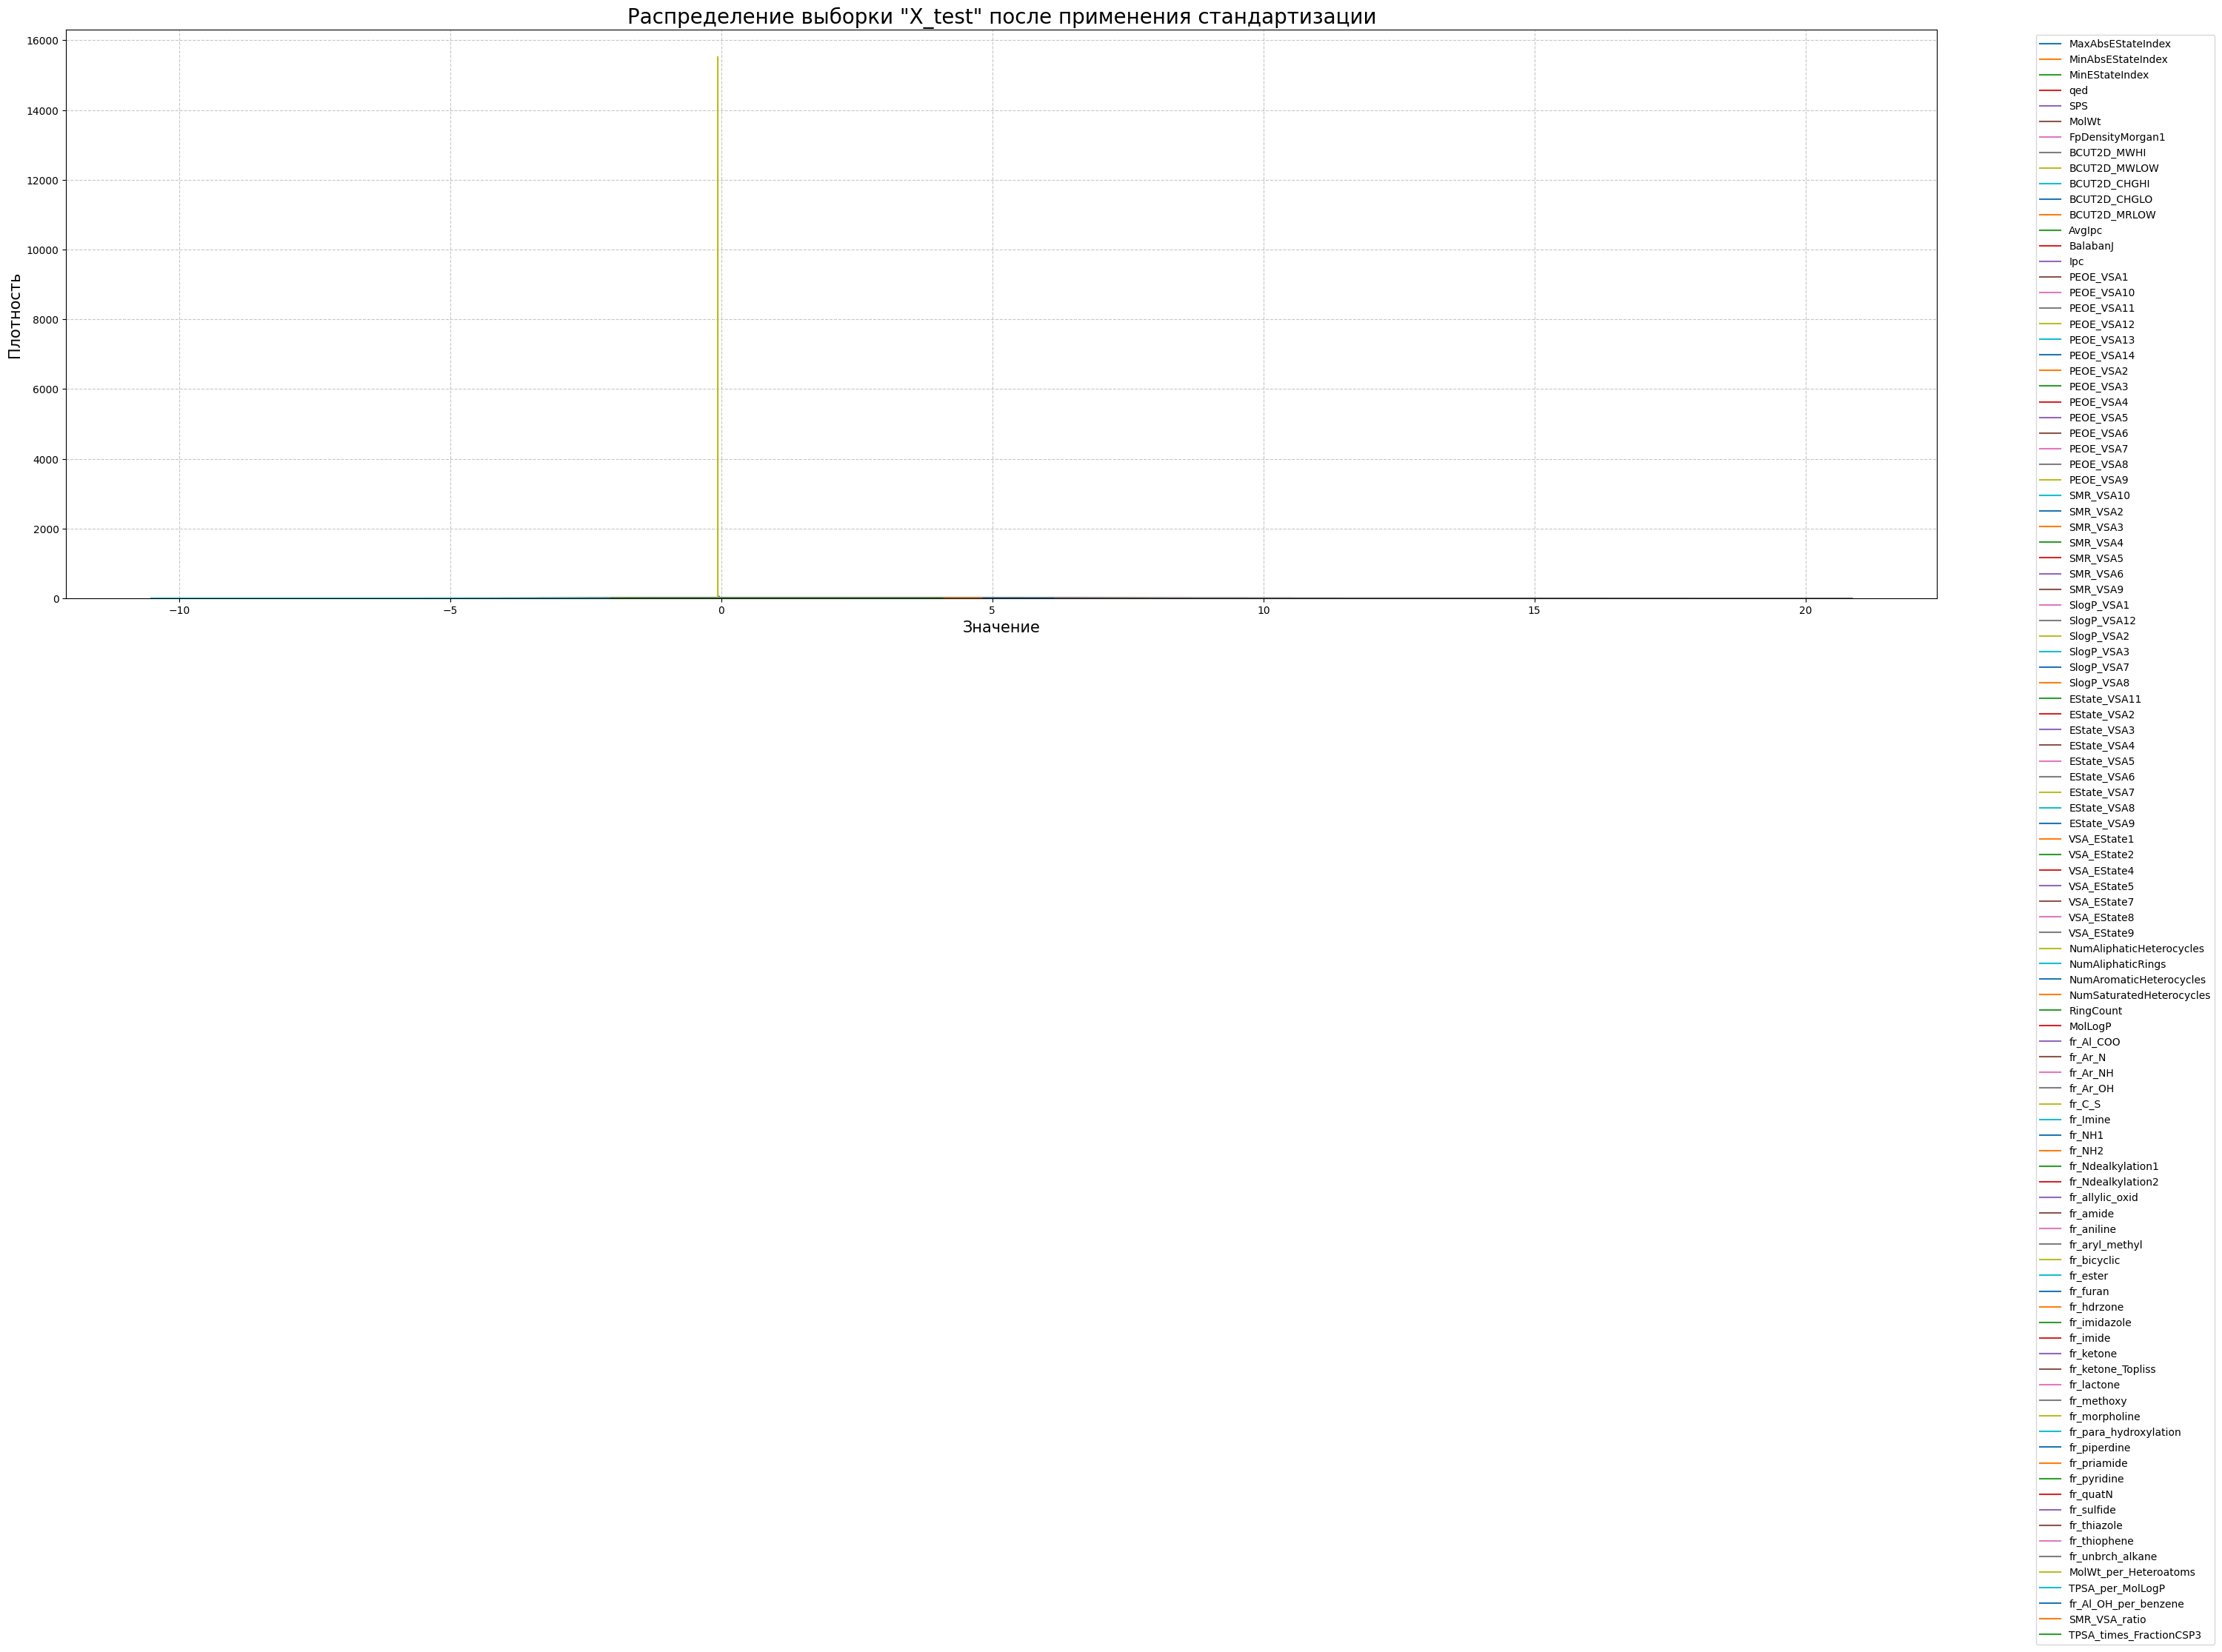

------------------------------------------------------------------------------------------------------------------------------------------------------


In [27]:
# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_train
print()
features_distribution_plot(
    data = X_train_processed_df,
    title = 'Распределение выборки "X_train" после применения стандартизации',
    figsize = (30, 17)
)

# Добавляем отступ
print('\n\n')



# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_test
features_distribution_plot(
    data = X_test_processed_df,
    title = 'Распределение выборки "X_test" после применения стандартизации',
    figsize = (30, 17)
)

**Вывод:**

Судя по графику, после стандартизации признаки имеют нормальное распределение.

#### $1.2$

#### **Отбор самых информативных признаков.**

На данном этапе отберём только самые информативные признаки для дальнейшего решения задачи регрессии.

Производить отбор признаков будем в $4$ этапа:

1. Отберём $50$ признаков с помощью алгоритма **Mutual Information**,
2. Отберём $50$ признаков с помощью алгоритма **F-test**,
3. Отберём $50$ признаков из отобранных обоими алгоритмами,
4. Из оставшихся отберём $30$ признаков с помощью алгоритма **Lasso**.

--

Для начала создадим функцию для визуализации кумулятивной линии вклада конкретного алгоритма отбора признаков для того, что бы  вычислить необходимое количество признаков, чтобы покрыть $90$% информации:

In [29]:
# Создаём функцию для построения кумулятивной линии
def cum_line(data, main_title = None, title = None):
    
    
    """
    Функция для построения кумулятивной линии.
    
    Параметры:
    - data: pandas Series с данными.
    - main_title: название графика.
    - title: заголовок графика.
    
    """
    
    
    # Создаём DataFrame с кумулятивной долей информации
    alg_cumsum = (data.cumsum() / data.sum()).reset_index()
    alg_cumsum.columns = ['feature', 'cumulative_share']

    # Задаём заглавие для графика
    print(f'\n{main_title}')
    print('-' * 150)


    # Строим график кумулятивного вклада признаков
    fig = px.line(
        alg_cumsum,
        x = alg_cumsum.index + 1,
        y = 'cumulative_share',
        markers = True,
        title = title
    )

    # Добавляем горизонтальную линию на уровне 0.9
    fig.add_hline(
        y = 0.9, 
        line_dash = 'dash', 
        line_color = 'red',
        annotation_text = '90 %', 
        annotation_position = 'bottom right'
    )

    # Настраиваем оси графика
    fig.update_layout(
        height = 800,
        width = 1200,
        title = title,
        xaxis_title = 'Число признаков',
        yaxis_title = 'Доля информации',
    
        yaxis = dict(
            tickmode = 'linear',
            dtick = 0.1,
            tickvals = [i / 10 for i in range(11)],
            ticktext = [str(i / 10) for i in range(11)]
        )
    
    )

    # Выводим график
    fig.show('png')
    print('-' * 150)

Теперь создадим функцию для визуализации важности признаков:

In [30]:
# Создаём функцию для построения горизонтального столбчатого графика
def bar_scores(data, main_title = None, title = None, color = None):
    
    
    """
    Функция для построения горизонтального столбчатого графика.
    
    Параметры:
    - data: pandas Series с оценками признаков.
    - main_title: название графика.
    - title: заголовок графика.
    - color: цвет столбцов графика.
    
    """
    
    
    # Задаём заглавие для графика
    print(f'\n{main_title}')
    print('-' * 150)



    # Строим график распределения 50 признаков по "Mutual Information"
    fig = px.bar(
        data.head(50).reset_index(),
        x = 'index',    
        y = data.head(50).values,  
        title = title,
        orientation = 'v',  
        color_discrete_sequence = sns.color_palette(color, 50),  
        text = data.head(50).values,  
    
        labels = {
            'index': 'Признаки', 
            'y': 'Mutual Information (MI)'
        }
    
    )

    # Настраиваем оси графика
    fig.update_layout(
        height = 800,
        width = 1200,
        xaxis_title = 'Признаки',
        yaxis_title = 'Mutual Information (MI)',
        xaxis_tickangle = -45,  
        bargap = 0.35 
    )



    # Выводим график
    fig.show('png')
    print('-' * 150)

**Первый этап:** Фильтрация с помощью `Mutual Information` для отбора первых $50$ признаков:


Топ-50 признаков по "Mutual Information":

BCUT2D_MRLOW               0.136943
BCUT2D_MWHI                0.133498
SMR_VSA5                   0.129232
SI_and_8_classif           0.119639
SI_classif                 0.116791
SlogP_VSA2                 0.115599
PEOE_VSA1                  0.094778
BCUT2D_CHGHI               0.090310
BCUT2D_MWLOW               0.088712
SPS                        0.086413
EState_VSA8                0.086088
PEOE_VSA7                  0.085498
EState_VSA6                0.085271
BCUT2D_CHGLO               0.084492
VSA_EState2                0.084089
SlogP_VSA1                 0.083316
PEOE_VSA2                  0.083038
VSA_EState8                0.080440
PEOE_VSA6                  0.076317
PEOE_VSA9                  0.071373
EState_VSA3                0.066763
TPSA_times_FractionCSP3    0.065650
AvgIpc                     0.065289
SMR_VSA9                   0.062896
EState_VSA2                0.062490
PEOE_VSA11                 0.060852
VSA_EState1         

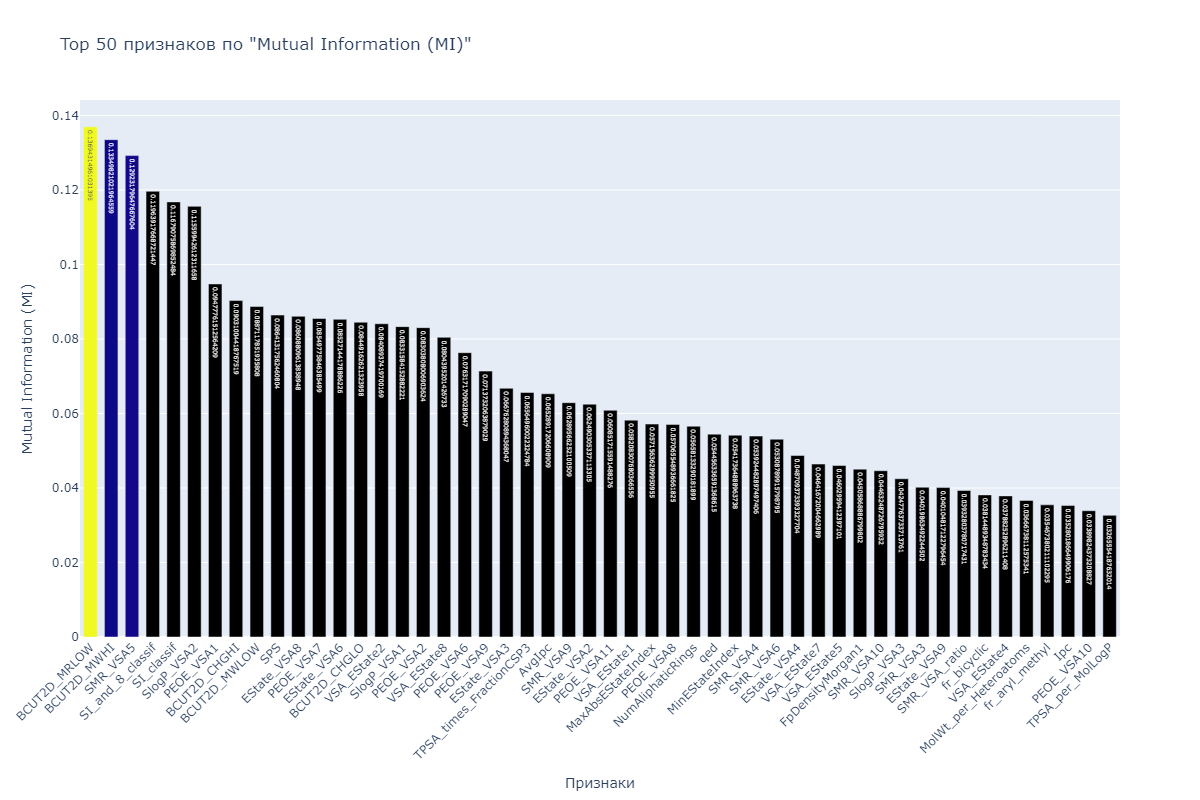

------------------------------------------------------------------------------------------------------------------------------------------------------


График кумулятивного вклада признаков (MI)
------------------------------------------------------------------------------------------------------------------------------------------------------


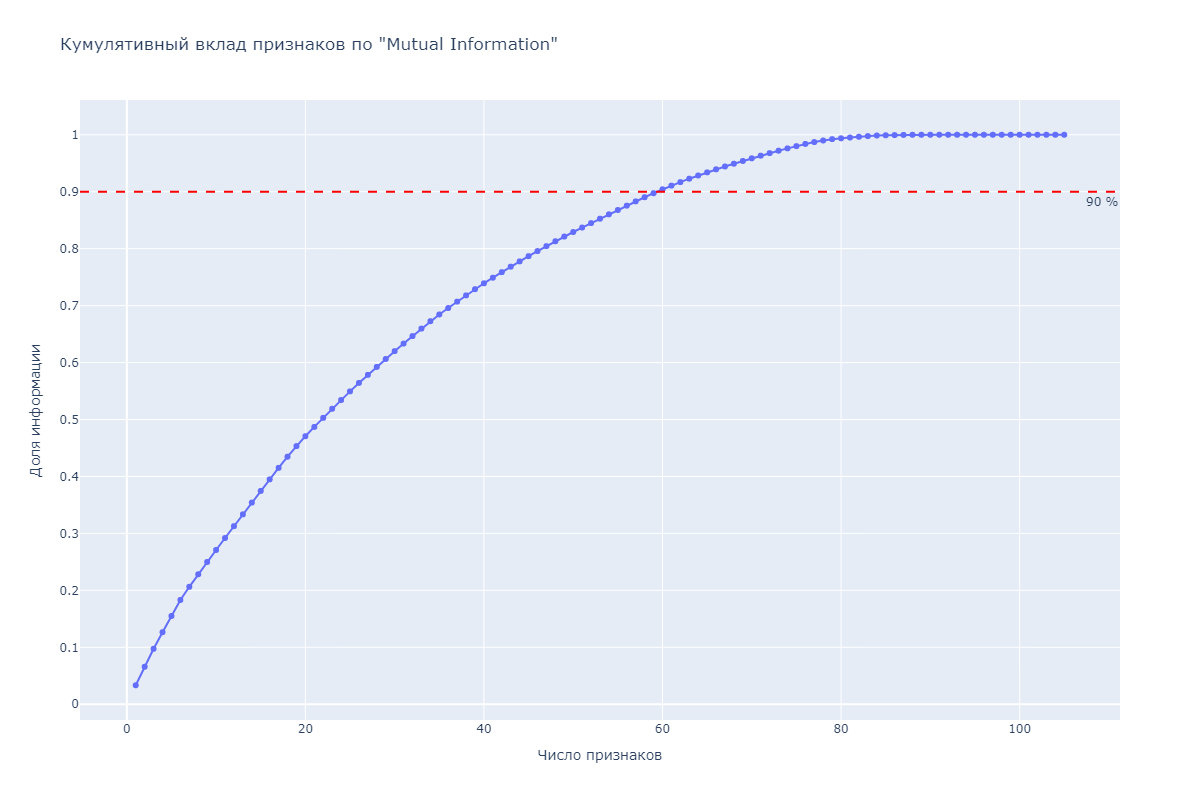

------------------------------------------------------------------------------------------------------------------------------------------------------


In [31]:
# Инициализируем класс 'SelectKBest' с алгоритмом 'mutual_info_classif'
mi_selector = feature_selection.SelectKBest(
    score_func = feature_selection.mutual_info_classif,
    k = 50
)

# Обучаем алгоритм
mi_selector.fit(X_train_processed_df, y_train)



# Из полученных результатов создадим столбец 'Series'          
mi_scores = pd.Series(
    mi_selector.scores_,
    index = X_train_processed_df.columns
).sort_values(ascending = False)



# Выделяем отобранные признаки
mi_selected_features = X_train_processed_df.columns[mi_selector.get_support()].tolist()

# Выводим результат
print(f'\nТоп-50 признаков по "Mutual Information":\n\n{mi_scores.head(50)}')
print('-' * 40)
print('\n\n')




# Посторим график оценки важности признаков при помощи функции 'bar_scores'
bar_scores(
    data = mi_scores,
    main_title = 'График распределения 50 признаков по "Mutual Information":',
    title = 'Top 50 признаков по "Mutual Information (MI)"',
    color = 'Set1'
)
print()


# Построим кумулятивную линию при помощи функции 'cum_line'
cum_line(
    data = mi_scores,
    main_title = 'График кумулятивного вклада признаков (MI)',
    title = 'Кумулятивный вклад признаков по "Mutual Information"'
)

**Вывод:**

По графику кумулятивного вклада признаков по `Mutual Information` видно, что наиболее оптимальное количество признаков, объясняющее $90$% дисперсии, находится в диапазоне от $56$ до $58$.

**Второй этап:** Фильтрация признаков с помощью `F-теста` для отбора первых $50$ признаков:


Топ-50 признаков по "F-тесту"

SI_classif                  257.906935
SI_and_8_classif            217.858853
NumSaturatedHeterocycles     45.001605
NumAliphaticHeterocycles     32.505666
VSA_EState4                  28.791699
VSA_EState8                  27.008787
EState_VSA8                  25.182463
EState_VSA5                  22.123502
VSA_EState7                  20.063263
PEOE_VSA6                    17.231256
SMR_VSA4                     16.989209
PEOE_VSA7                    16.955596
fr_NH2                       14.264126
MinEStateIndex               14.092183
VSA_EState1                  14.029598
EState_VSA4                  13.382974
SMR_VSA5                     12.468273
fr_Ndealkylation2            11.827870
fr_furan                     11.249610
MaxAbsEStateIndex            10.766676
MolLogP                      10.500896
qed                          10.333602
EState_VSA11                  9.125939
fr_ketone_Topliss             8.545651
fr_sulfide                    8.

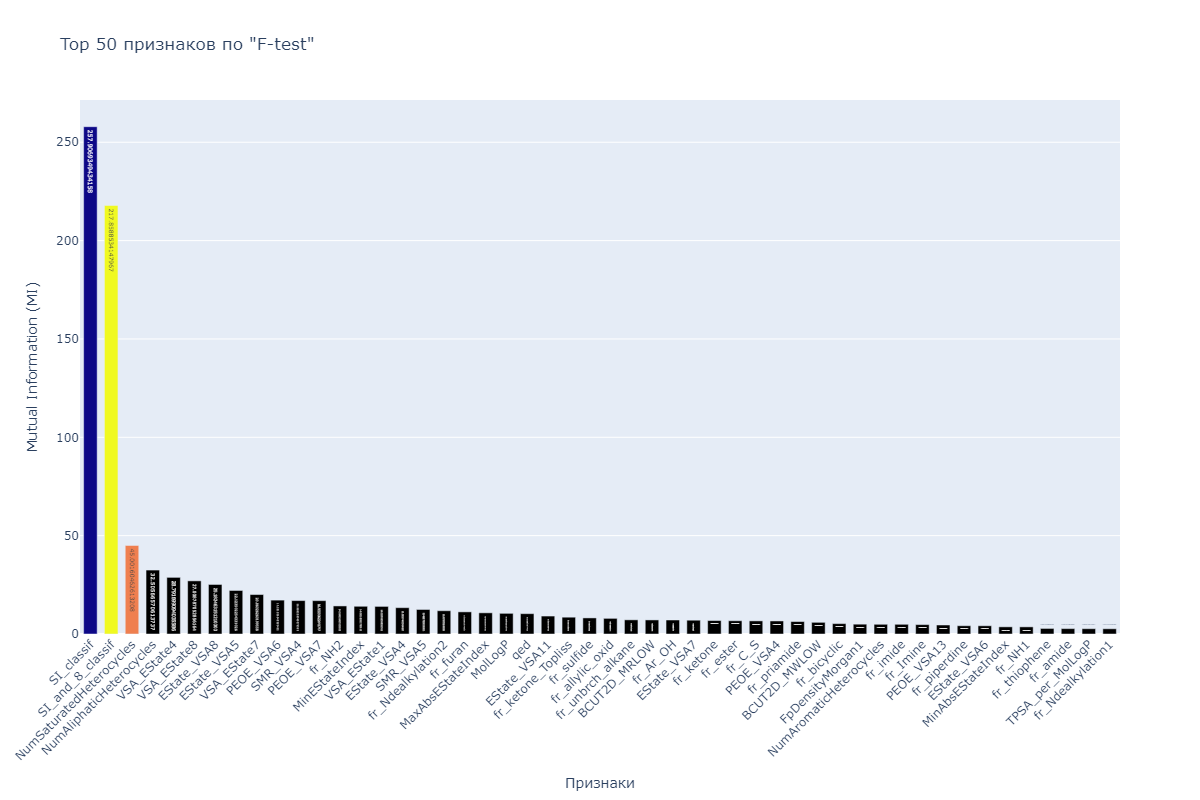

------------------------------------------------------------------------------------------------------------------------------------------------------


График кумулятивного вклада признаков (F-test):
------------------------------------------------------------------------------------------------------------------------------------------------------


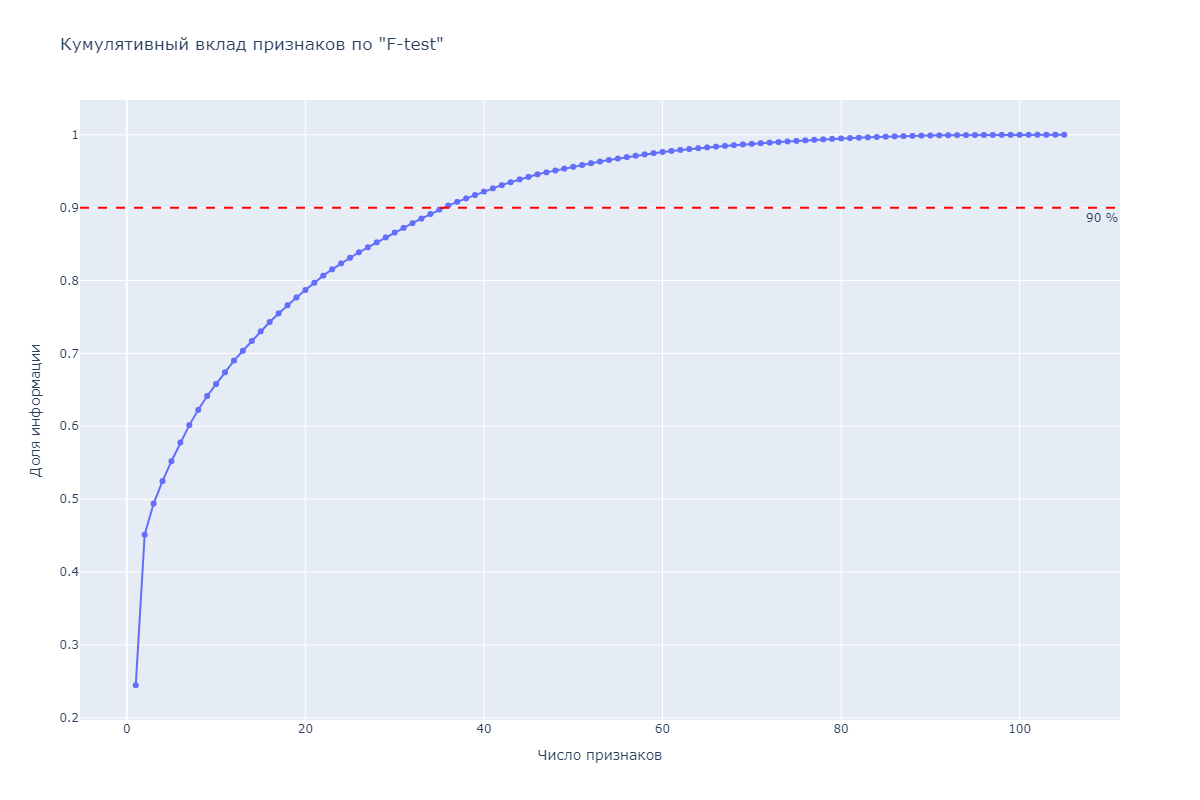

------------------------------------------------------------------------------------------------------------------------------------------------------


In [32]:
# Инициализируем класс 'SelectKBest' с алгоритмом 'f_classif'              
f_selector = feature_selection.SelectKBest(
    score_func = feature_selection.f_classif,
    k = 50
)

# Обучаем алгоритм
f_selector.fit(X_train_processed_df, y_train)



# Из полученных результатов создадим столбец 'Series'   
f_scores = pd.Series(
    f_selector.scores_,
    index = X_train_processed_df.columns
).sort_values(ascending = False)



# Выделяем отобранные признаки
f_selected_features = X_train_processed_df.columns[f_selector.get_support()].tolist()

# Выводим результат
print(f'\nТоп-50 признаков по "F-тесту"\n\n{f_scores.head(50)}')
print('-' * 40)
print('\n\n')




# Посторим график оценки важности признаков при помощи функции 'bar_scores'
bar_scores(
    data = f_scores,
    main_title = 'График распределения 50 признаков по "F-test":',
    title = 'Top 50 признаков по "F-test"',
    color = 'Set2'
)
print()


# Построим кумулятивную линию при помощи функции 'cum_line'
cum_line(
    data = f_scores,
    main_title = 'График кумулятивного вклада признаков (F-test):',
    title = 'Кумулятивный вклад признаков по "F-test"'
)

**Вывод:**

По `F-test` оптимальное количество признаков уже чуть меньше (примерно $43$ - $44$).

**Третий этап:** Отбор лучших $50$ признаков из отобранных обоими алгоритмами:

In [33]:
# Пересечение признаков от "Mutual Information" и "F-теста"
common_features = list(set(mi_selected_features) & set(f_selected_features))

# Выводим результат
print(f'\nКоличество общих признаков ("Mutual Information" и "F-тест"): {len(common_features)}')
print('-' * 65)
print('\n\n')



# Если количество признаков меньше 50, дополняем из 'Mutual Information'
if len(common_features) < 50:
    additional_features = [feature for feature in mi_selected_features if feature not in common_features]
    common_features.extend(additional_features[:50 - len(common_features)])
    
# Выводим результат
print(f'Итоговые 50 признаков после фильтрации:\n\n{common_features}')
print('-' * 150)


Количество общих признаков ("Mutual Information" и "F-тест"): 21
-----------------------------------------------------------------



Итоговые 50 признаков после фильтрации:

['MaxAbsEStateIndex', 'PEOE_VSA7', 'VSA_EState4', 'MinEStateIndex', 'BCUT2D_MWLOW', 'EState_VSA4', 'SMR_VSA5', 'BCUT2D_MRLOW', 'PEOE_VSA6', 'SMR_VSA4', 'VSA_EState8', 'fr_bicyclic', 'SI_and_8_classif', 'FpDensityMorgan1', 'TPSA_per_MolLogP', 'EState_VSA8', 'VSA_EState7', 'qed', 'SI_classif', 'EState_VSA6', 'VSA_EState1', 'SPS', 'BCUT2D_MWHI', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'AvgIpc', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA2', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA2', 'SlogP_VSA3', 'EState_VSA2', 'EState_VSA3', 'EState_VSA9', 'VSA_EState2', 'VSA_EState5', 'NumAliphaticRings', 'fr_aryl_methyl', 'MolWt_per_Heteroatoms', 'SMR_VSA_ratio', 'TPSA_times_FractionCSP3']
----------------------------------------------------------------------------

Сохраняем отобранные признаки в выборках:

In [34]:
# Сокращаем признаки в тренировочной и тестовой выборках до 50 отобранных
X_train_filtered = X_train_processed_df[common_features]
X_test_filtered = X_test_processed_df[common_features]



# Выведем результаты
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_filtered,
    data_name = 'X_train_filtered',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_filtered,
    data_name = 'X_test_filtered',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_filtered" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 50.
----------------------------------------


,MaxAbsEStateIndex,PEOE_VSA7,VSA_EState4,MinEStateIndex,BCUT2D_MWLOW,EState_VSA4,SMR_VSA5,BCUT2D_MRLOW,PEOE_VSA6,SMR_VSA4,...,EState_VSA2,EState_VSA3,EState_VSA9,VSA_EState2,VSA_EState5,NumAliphaticRings,fr_aryl_methyl,MolWt_per_Heteroatoms,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,-1.496602,1.628333,2.503470,0.771519,-0.231601,1.012479,-0.054649,1.094114,-0.283280,0.809641,...,-0.642902,-0.791905,0.703425,-0.731273,0.875327,-0.123882,-0.400279,-0.064531,-0.806000,-0.332149
1,0.527403,-0.504015,0.014302,-0.394927,0.425592,-1.063253,-0.966737,-0.132690,-0.116601,-0.927114,...,-0.612792,0.381094,0.042850,0.683650,-0.723162,-0.123882,1.933607,-0.064565,-0.806000,-0.857136
2,0.252959,-0.457205,-0.834664,0.392277,-0.313054,0.237265,0.752115,-1.317070,-0.096764,0.018407,...,1.659867,0.092873,-0.479599,0.581600,0.320846,-0.123882,-0.400279,-0.064578,0.736551,1.215385
3,-1.210453,1.143588,1.851472,0.750903,-0.967502,-0.209812,0.756481,-0.265867,-0.613549,1.381794,...,-0.632769,-0.791905,-0.369657,-1.092745,1.075515,1.344428,-0.400279,-0.064458,-0.806000,-0.065901
4,0.694610,0.270976,-0.370231,0.472459,-0.403346,1.428540,0.149113,0.266289,0.257495,-0.061945,...,0.774582,-1.164993,-1.002048,-0.768015,-0.077143,-0.858037,-0.400279,-0.064567,0.207477,-0.043975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.251380,0.004357,0.271046,0.428609,-0.231089,-0.199418,-0.054649,-0.295874,1.163576,0.809641,...,-0.154825,0.114232,0.071034,0.099133,0.172446,-0.123882,-0.400279,-0.064533,0.211154,-0.300668
719,-1.577604,1.008224,1.202870,0.843749,-0.749877,0.803055,0.983472,0.140106,1.221381,-0.021769,...,-1.085657,-0.011078,-0.479599,-0.899965,0.530838,0.610273,1.933607,-0.064481,-0.300500,-0.744117
720,0.439661,0.428075,0.280488,0.198692,0.434471,1.329183,-0.795632,-0.232253,1.040884,-0.519580,...,0.319731,-0.722604,0.083057,0.650119,0.166710,-0.123882,-0.400279,-0.064571,-0.806000,-0.622234
721,0.980138,-0.786662,-1.533837,-0.499596,0.607120,-0.954993,-1.391050,0.531099,-1.274086,-0.927114,...,-0.160658,-0.350889,0.530036,0.705109,-2.182500,-1.592192,-0.400279,-0.064583,-0.806000,-0.643005


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_filtered" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 50.
----------------------------------------


,MaxAbsEStateIndex,PEOE_VSA7,VSA_EState4,MinEStateIndex,BCUT2D_MWLOW,EState_VSA4,SMR_VSA5,BCUT2D_MRLOW,PEOE_VSA6,SMR_VSA4,...,EState_VSA2,EState_VSA3,EState_VSA9,VSA_EState2,VSA_EState5,NumAliphaticRings,fr_aryl_methyl,MolWt_per_Heteroatoms,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,0.160756,-1.638111,-1.070186,-0.302029,2.296748,-1.452750,-1.218918,-1.365982,-1.274086,-0.927114,...,-0.191636,-0.853886,-1.002048,0.680807,-0.355714,-1.592192,-0.400279,-0.064599,0.168554,-0.016665
1,0.552605,0.323003,0.072302,-2.184035,1.154219,-1.028044,-0.953746,-0.312065,-1.274086,-0.519580,...,0.740576,-0.773137,0.345513,-1.092745,-0.134131,-1.592192,-0.400279,-0.064590,1.068112,-0.717143
2,-0.045459,-0.457205,-1.001606,0.108325,-0.265352,-0.104185,0.523061,-1.412236,-0.637539,0.018407,...,0.378423,0.082011,0.007587,-0.360243,0.318123,-0.123882,-0.400279,-0.064578,1.241226,1.433804
3,0.464136,0.666848,0.251347,-1.212053,-0.231089,0.708760,1.275313,0.805772,-0.034597,0.809641,...,-0.642902,2.355336,1.068921,-0.738469,0.292743,-0.123882,1.933607,-0.064576,1.152177,1.983047
4,-1.720945,1.404096,0.932722,0.862116,-0.231368,0.292272,2.567789,1.093239,1.932642,2.546396,...,-1.085657,0.327360,0.099219,-0.357125,0.653392,1.344428,-0.400279,-0.064459,-0.806000,-0.190647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-1.488398,0.079415,1.288017,0.899797,0.127272,-0.209812,-0.100876,1.509991,-0.967807,0.949210,...,-1.085657,-0.748715,-0.369657,-1.092745,1.076714,-0.123882,-0.400279,-0.064510,-0.806000,-0.065901
177,0.562094,-0.711178,1.781502,0.434776,0.884829,-0.275581,-0.928795,0.691163,1.016894,-0.120755,...,-0.135646,0.021690,-1.002048,0.152801,0.085952,-0.858037,1.933607,-0.064572,-0.806000,-0.833169
178,0.417928,-0.252574,-0.127502,0.409685,1.260989,-0.277778,-1.172573,0.698000,0.172770,-0.927114,...,-0.131675,0.150979,0.007587,0.121094,0.432689,-1.592192,-0.400279,-0.064572,-0.806000,-0.842731
179,0.044589,0.061704,-0.465348,0.028994,-0.226828,-0.673080,0.298145,-0.587122,-0.984255,-0.454353,...,-0.102694,0.908194,1.087747,-1.092745,0.531638,-0.123882,-0.400279,-0.064570,-0.806000,0.764520


------------------------------------------------------------------------------------------------------------------------------------------------------


**Четвёртый этап**: Применение `LogisticRegression` для выбора $30$ признаков:

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning:

X has feature names, but SelectFromModel was fitted without feature names




Топ-30 финальных признаков после "LogisticRegression"

SI_classif                 0.973351
SPS                        0.757651
MinEStateIndex             0.746311
SI_and_8_classif           0.693121
VSA_EState5                0.686030
VSA_EState1                0.663355
VSA_EState8                0.652370
AvgIpc                     0.592763
SlogP_VSA2                 0.583742
NumAliphaticRings          0.570415
SMR_VSA10                  0.544056
PEOE_VSA11                 0.529459
SlogP_VSA3                 0.496754
EState_VSA4                0.344311
BCUT2D_MRLOW               0.339302
MaxAbsEStateIndex          0.313868
PEOE_VSA8                  0.308600
VSA_EState7                0.304201
PEOE_VSA1                  0.292747
TPSA_times_FractionCSP3    0.284439
BCUT2D_CHGLO               0.243713
fr_aryl_methyl             0.218704
BCUT2D_CHGHI               0.211494
VSA_EState4                0.204778
EState_VSA8                0.203076
BCUT2D_MWLOW               0.170507
PEOE_VSA

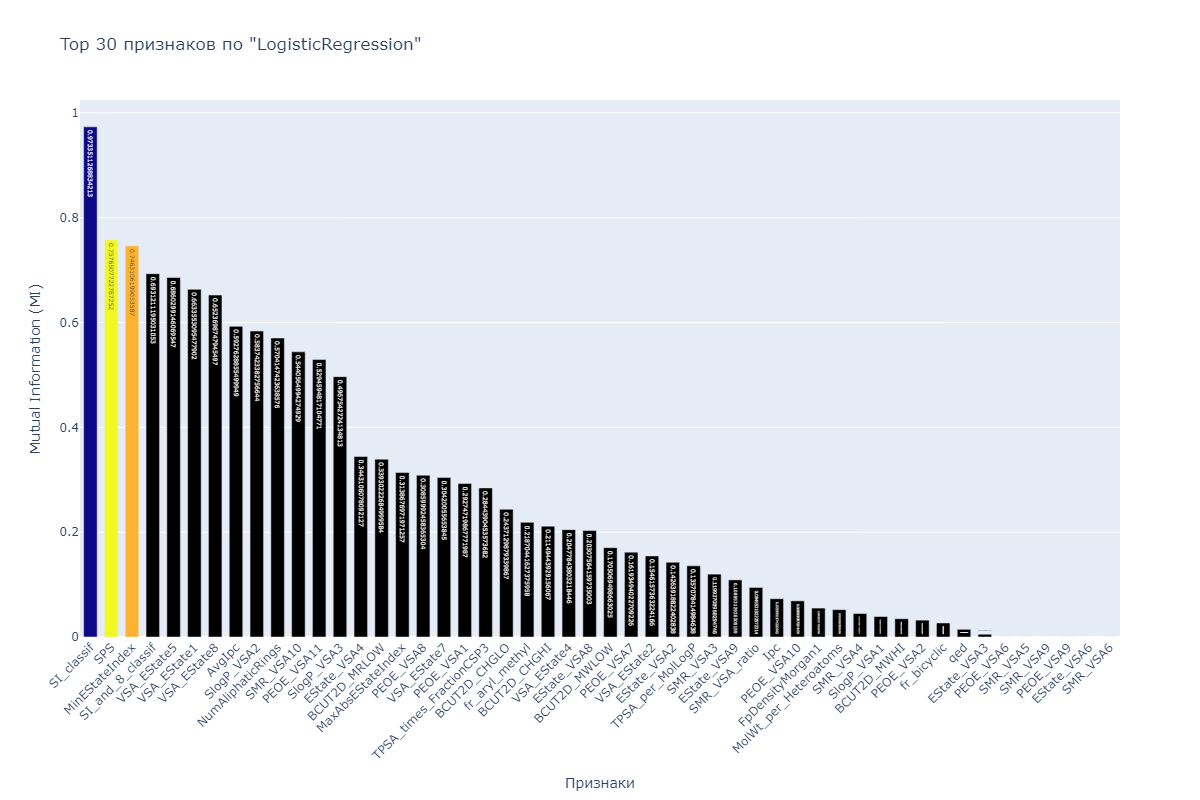

------------------------------------------------------------------------------------------------------------------------------------------------------


График кумулятивного вклада признаков (LogisticRegression):
------------------------------------------------------------------------------------------------------------------------------------------------------


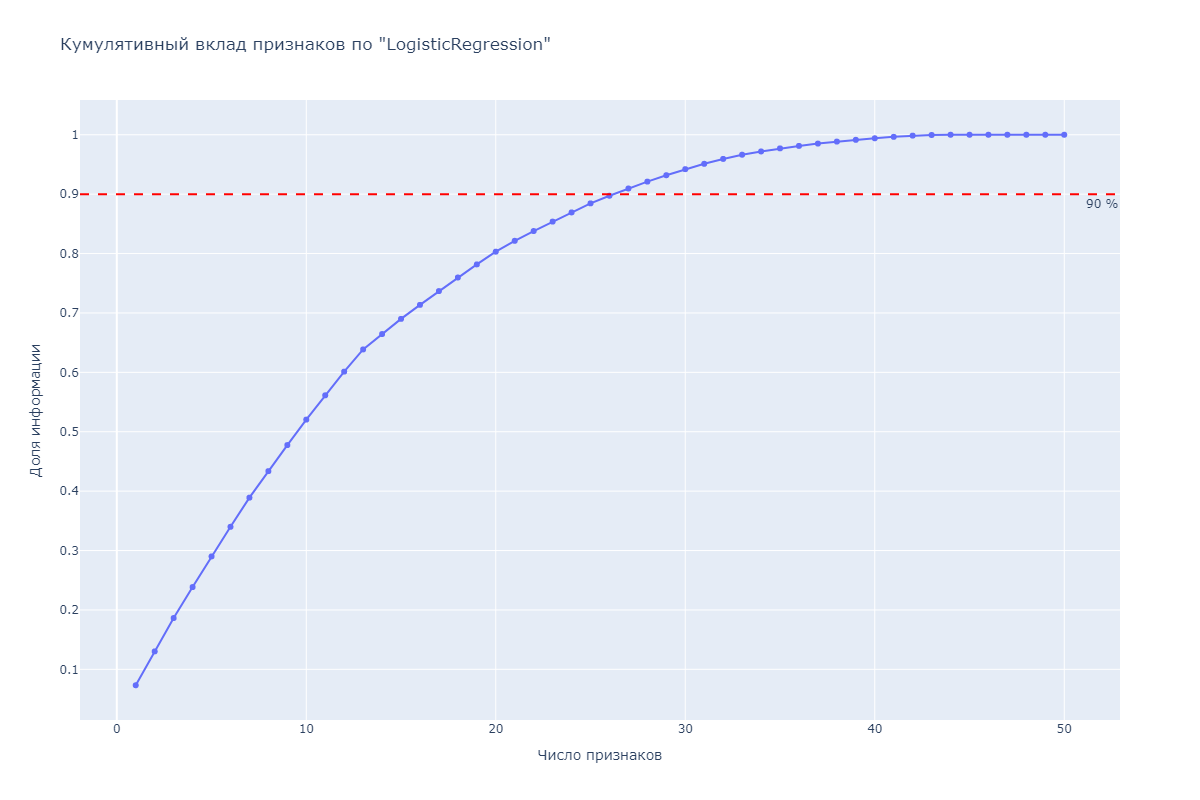

------------------------------------------------------------------------------------------------------------------------------------------------------


In [35]:
# Инициализируем класс 'LogisticRegression'
log_model = linear_model.LogisticRegression(
    penalty = 'l1',
    solver = 'liblinear',
    C = 1.0,
    random_state = 42
)

# Обучаем алгоритм
log_model.fit(X_train_filtered, y_train)



# Из полученных результатов создадим столбец 'Series'  
log_scores = pd.Series(
    log_model.coef_[0],
    index = X_train_filtered.columns
).abs().sort_values(ascending = False)



# Выделяем 30 наиболее важных признаков
log_selector = feature_selection.SelectFromModel(
    log_model,
    prefit = True,
    max_features = 30
)



# Из отобранных 30 признаков формируем итоговый 'DataFrame'
# после чего сохраним итоговые признаки в список
X_train_final = log_selector.transform(X_train_filtered)
final_features = X_train_filtered.columns[log_selector.get_support()].tolist()

# Преобразование 'X_train_final' в 'DataFrame'
X_train_final = pd.DataFrame(
    X_train_final, 
    columns = final_features,
    index = X_train.index
)

# Применение отобранных признаков к тестовой выборке
X_test_final = X_test_filtered[final_features]



# Выводим результат
print(f'\nТоп-30 финальных признаков после "LogisticRegression"\n\n{log_scores.head(50)}')
print('-' * 40)
print('\n\n')




# Посторим график оценки важности признаков при помощи функции 'bar_scores'
bar_scores(
    data = log_scores,
    main_title = 'График распределения 30 признаков по "LogisticRegression":',
    title = 'Top 30 признаков по "LogisticRegression"',
    color = 'Set3'
)
print()


# Построим кумулятивную линию при помощи функции 'cum_line'
cum_line(
    data = log_scores,
    main_title = 'График кумулятивного вклада признаков (LogisticRegression):',
    title = 'Кумулятивный вклад признаков по "LogisticRegression"'
)

**Вывод:**

Как видно из графика, по `LogisticRegression` количество признаков (до $30$) оптимальное количество признаков составляет $27$.

Выведем информацию итоговых выборок:

In [36]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_final,
    data_name = 'X_train_final',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_final,
    data_name = 'X_test_final',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_final" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 30.
----------------------------------------


,MaxAbsEStateIndex,PEOE_VSA7,VSA_EState4,MinEStateIndex,BCUT2D_MWLOW,EState_VSA4,BCUT2D_MRLOW,VSA_EState8,SI_and_8_classif,TPSA_per_MolLogP,...,PEOE_VSA8,SMR_VSA10,SlogP_VSA2,SlogP_VSA3,EState_VSA2,VSA_EState2,VSA_EState5,NumAliphaticRings,fr_aryl_methyl,TPSA_times_FractionCSP3
0,-1.496602,1.628333,2.503470,0.771519,-0.231601,1.012479,1.094114,0.340090,-0.685210,-0.017568,...,-0.021284,0.106999,-1.133018,-1.068602,-0.642902,-0.731273,0.875327,-0.123882,-0.400279,-0.332149
1,0.527403,-0.504015,0.014302,-0.394927,0.425592,-1.063253,-0.132690,-0.608620,-0.685210,0.133615,...,-1.513317,-0.287725,-0.889025,0.254254,-0.612792,0.683650,-0.723162,-0.123882,1.933607,-0.857136
2,0.252959,-0.457205,-0.834664,0.392277,-0.313054,0.237265,-1.317070,0.101432,-0.685210,0.146636,...,1.658586,0.488749,-0.456006,0.129488,1.659867,0.581600,0.320846,-0.123882,-0.400279,1.215385
3,-1.210453,1.143588,1.851472,0.750903,-0.967502,-0.209812,-0.265867,-0.097231,1.459407,-0.019390,...,-1.021808,-1.157446,-1.139996,-1.068602,-0.632769,-1.092745,1.075515,1.344428,-0.400279,-0.065901
4,0.694610,0.270976,-0.370231,0.472459,-0.403346,1.428540,0.266289,0.375166,-0.685210,0.009951,...,-0.932554,0.817315,-0.445268,-1.068602,0.774582,-0.768015,-0.077143,-0.858037,-0.400279,-0.043975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.251380,0.004357,0.271046,0.428609,-0.231089,-0.199418,-0.295874,0.481124,-0.685210,-0.010548,...,0.013202,0.156622,-0.360715,0.129488,-0.154825,0.099133,0.172446,-0.123882,-0.400279,-0.300668
719,-1.577604,1.008224,1.202870,0.843749,-0.749877,0.803055,0.140106,1.736961,-0.685210,-0.085575,...,0.228973,-1.157446,0.160940,1.014571,-1.085657,-0.899965,0.530838,0.610273,1.933607,-0.744117
720,0.439661,0.428075,0.280488,0.198692,0.434471,1.329183,-0.232253,-0.936206,-0.685210,0.086950,...,-0.943551,1.757702,0.023722,-0.465932,0.319731,0.650119,0.166710,-0.123882,-0.400279,-0.622234
721,0.980138,-0.786662,-1.533837,-0.499596,0.607120,-0.954993,0.531099,-0.936206,1.459407,0.134657,...,-1.019632,0.096054,-0.261109,-0.473182,-0.160658,0.705109,-2.182500,-1.592192,-0.400279,-0.643005


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_final" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 30.
----------------------------------------


,MaxAbsEStateIndex,PEOE_VSA7,VSA_EState4,MinEStateIndex,BCUT2D_MWLOW,EState_VSA4,BCUT2D_MRLOW,VSA_EState8,SI_and_8_classif,TPSA_per_MolLogP,...,PEOE_VSA8,SMR_VSA10,SlogP_VSA2,SlogP_VSA3,EState_VSA2,VSA_EState2,VSA_EState5,NumAliphaticRings,fr_aryl_methyl,TPSA_times_FractionCSP3
0,0.160756,-1.638111,-1.070186,-0.302029,2.296748,-1.452750,-1.365982,-0.936206,-0.685210,-1.198955,...,-0.958198,0.499853,0.259309,0.288896,-0.191636,0.680807,-0.355714,-1.592192,-0.400279,-0.016665
1,0.552605,0.323003,0.072302,-2.184035,1.154219,-1.028044,-0.312065,-0.673554,-0.685210,0.128426,...,-1.008634,0.968608,-0.514649,-0.292246,0.740576,-1.092745,-0.134131,-1.592192,-0.400279,-0.717143
2,-0.045459,-0.457205,-1.001606,0.108325,-0.265352,-0.104185,-1.412236,-0.224349,-0.685210,0.213022,...,-0.418413,-0.722000,-0.485835,-0.473182,0.378423,-0.360243,0.318123,-0.123882,-0.400279,1.433804
3,0.464136,0.666848,0.251347,-1.212053,-0.231089,0.708760,0.805772,1.559249,-0.685210,0.094904,...,0.054797,-0.172658,0.786383,2.891055,-0.642902,-0.738469,0.292743,-0.123882,1.933607,1.983047
4,-1.720945,1.404096,0.932722,0.862116,-0.231368,0.292272,1.093239,2.072285,1.459407,-0.076881,...,1.622910,-0.312085,-0.373630,-1.068602,-1.085657,-0.357125,0.653392,1.344428,-0.400279,-0.190647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-1.488398,0.079415,1.288017,0.899797,0.127272,-0.209812,1.509991,-0.552634,-0.685210,0.065149,...,-0.977181,-1.157446,-1.119683,-1.068602,-1.085657,-1.092745,1.076714,-0.123882,-0.400279,-0.065901
177,0.562094,-0.711178,1.781502,0.434776,0.884829,-0.275581,0.691163,-0.267836,-0.685210,0.100585,...,-0.481319,0.976483,-0.268689,-1.068602,-0.135646,0.152801,0.085952,-0.858037,1.933607,-0.833169
178,0.417928,-0.252574,-0.127502,0.409685,1.260989,-0.277778,0.698000,-0.760104,1.459407,0.099420,...,-1.513317,0.536398,-0.472495,-0.245931,-0.131675,0.121094,0.432689,-1.592192,-0.400279,-0.842731
179,0.044589,0.061704,-0.465348,0.028994,-0.226828,-0.673080,-0.587122,-0.281073,-0.685210,0.247098,...,-0.418413,-1.157446,0.629610,-0.473182,-0.102694,-1.092745,0.531638,-0.123882,-0.400279,0.764520


------------------------------------------------------------------------------------------------------------------------------------------------------


**Корреляционный анализ.** 

Создаём функцию для построения тепловой карты корреляции признаков:

In [ ]:
# Создаём функцию 'heatmap_corr()' для построения тепловой карты корреляции
def heatmap_corr(data):
    
    # Вычисляем корреляционную матрицу
    correlation_matrix = data.corr()

    # Создаём заголовок для графика
    print('\nТепловая карта корреляции отобранных признаков:')
    print('-' * 150)



    # Создаём тепловую карту
    fig = go.Figure(data = go.Heatmap(
        z = correlation_matrix.values,
        x = correlation_matrix.columns,
        y = correlation_matrix.index,
        colorscale = 'RdBu',
        zmin = -1,
        zmax = 1,
        text = correlation_matrix.values.round(2),  
        texttemplate = "%{text}",  
        hoverinfo = 'z'
    ))



    # Настройка макета
    fig.update_layout(
        title = 'Значения корреляции отобранных признаков',
        width = 1200,
        height = 1200,
        title_x = 0.5,
        xaxis_tickangle = -45
    )



    # Отображение графика
    fig.show('png')
    print('-' * 150)

Проверим корреляцию отобранных признаков:


Тепловая карта корреляции отобранных признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


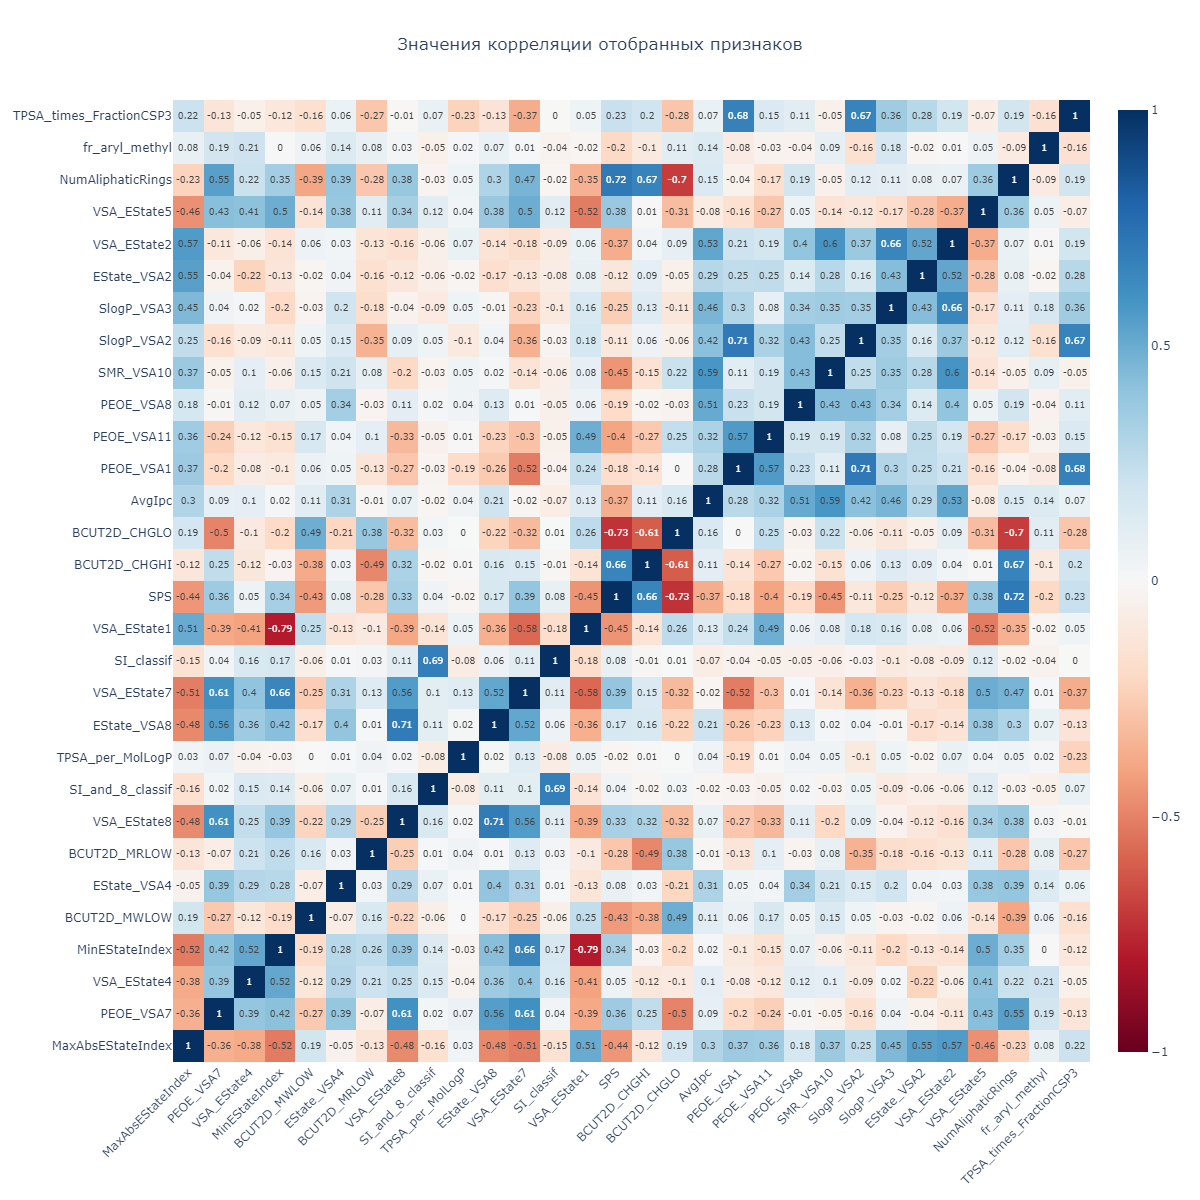

------------------------------------------------------------------------------------------------------------------------------------------------------


In [38]:
# Применяем функцию 'heatmap_corr()' для построения тепловой карты корреляции
heatmap_corr(data = X_train_final)

**Вывод:**

Из полученной тепловой карты видно, что значения корреляций находятся в пределах $+-0.79$, следовательно высококоррелированные связи отсутствуют. Данные полностью готовы к использованию для обучения модели.

#### $1.3$

#### **XGBoost (Extreme Gradient Boosting).**

Построим модель градиентного бустинга на обучающем наборе данных. Так же подберём наилучшие гиперпараметры при помощи `GridSearchCV`:

In [133]:
# Создаем объект класса XGBClassifier()
XGB_model = XGBClassifier(random_state = 42)


# Определение параметров для поиска
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y_train == 0) / sum(y_train == 1)]
}


# Производим поиск
grid_search_xgb = model_selection.GridSearchCV(
    estimator = XGB_model,
    param_grid = param_grid_xgb,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)


# Обучаем модель 
grid_search_xgb.fit(X_train_filtered, y_train)

# Сохраняем лучшую модель
best_model_xgb = grid_search_xgb.best_estimator_

# Делаем предсказание для тестовой выборки
y_predict_xgb = best_model_xgb.predict(X_test_filtered)



# Сохраним полученные гиперпараметры в переменной
best_parameters_xgb = grid_search_xgb.best_params_

# Выведем наилучшие значения гиперпараметров
print(f'Наилучшие значения гиперпараметров: {best_parameters_xgb}')

Наилучшие значения гиперпараметров: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 1, 'subsample': 0.6}


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning:

invalid value encountered in cast



Считаем метрики:

In [134]:
# Применяем функцию 'print_metrics' для рассчёта метрик
print_metrics(y_test, y_predict_xgb, 'XGBClassifier')


XGBClassifier (значения метрик):

Accuracy: 0.630
--------------------------------------------------------------------------------
Precision: 0.667
--------------------------------------------------------------------------------
Recall: 0.630
--------------------------------------------------------------------------------
F1-score: 0.629
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.76      0.53      0.63       105
           1       0.54      0.76      0.63        76

    accuracy                           0.63       181
   macro avg       0.65      0.65      0.63       181
weighted avg       0.67      0.63      0.63       181

--------------------------------------------------------------------------------


**Вывод:**

Модель `XGBClassifier` показывает среднее качество, так как она хорошо обнаруживает положительный класс $1$ (*Recall* = $0.76$), но часто ошибается в предсказаниях (*Precision* = $0.54$).

Модель хорошо находит вещества с высоким `IC50` (менее активные), но часто ошибочно относит активные соединения к неактивным.

Продолжим анализ с использованием других моделей.

#### $1.4$

#### **LightGBM (Light Gradient Boosting Machine).**

Построим модель градиентного бустинга на обучающем наборе данных. Так же подберём наилучшие гиперпараметры при помощи `GridSearchCV`:

In [48]:
# Создаем объект класса LGBMClassifier()
LGBMC_model = LGBMClassifier(random_state = 42)


# Определение параметров для поиска
param_grid_lgbmc = {
    'n_estimators': [50, 100, 200],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'num_leaves': [31, 63, 127],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'class_weight': ['balanced', None]
}


# Производим поиск
grid_search_lgbmc = model_selection.GridSearchCV(
    estimator = LGBMC_model,
    param_grid = param_grid_lgbmc,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)


# Обучаем модель 
grid_search_lgbmc.fit(X_train_final, y_train)

# Сохраняем лучшую модель
best_model_lgbmc = grid_search_lgbmc.best_estimator_

# Делаем предсказание для тестовой выборки
y_predict_lgbmc = best_model_lgbmc.predict(X_test_final)



# Сохраним полученные гиперпараметры в переменной
best_parameters_lgbmc = grid_search_lgbmc.best_params_

# Выведем наилучшие значения гиперпараметров
print(f'Наилучшие значения гиперпараметров: {best_parameters_lgbmc}')

Наилучшие значения гиперпараметров: {'class_weight': None, 'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31, 'subsample': 0.6}


Считаем метрики:

In [ ]:
# Применяем функцию 'print_metrics' для рассчёта метрик
print_metrics(y_test, y_predict_lgbmc, 'LGBMClassifier')

LGBMClassifier (значения метрик):

Accuracy: 0.680
--------------------------------------------------------------------------------
Precision: 0.697
--------------------------------------------------------------------------------
Recall: 0.680
--------------------------------------------------------------------------------
F1-score: 0.682
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.77      0.64      0.70       105
           1       0.60      0.74      0.66        76

    accuracy                           0.68       181
   macro avg       0.68      0.69      0.68       181
weighted avg       0.70      0.68      0.68       181

--------------------------------------------------------------------------------


**Вывод:**

Модель `LGBMClassifier` сбалансированнее, чем `XGBoost`, так как она лучше распознаёт оба класса, сохраняя высокую полноту для менее активных соединений, и улучшает точность (меньше ложных положительных).

#### $1.5$

#### **RFC (Random Forest Classifier).**

Построим модель случайного леса на тренировочной выборке. Так же подберём наилучшие гиперпараметры при помощи `GridSearchCV`:

In [ ]:
# Создаем объект класса RandomForestClassifier()
RFC_model = ensemble.RandomForestClassifier(random_state = 42)


# Определение параметров для поиска
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}


# Производим поиск
grid_search_rfc = model_selection.GridSearchCV(
    estimator = RFC_model,
    param_grid = param_grid_rfc,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)


# Обучаем модель 
grid_search_rfc.fit(X_train_final, y_train)

# Сохраняем лучшую модель
best_model_rfc = grid_search_rfc.best_estimator_

# Делаем предсказание для тестовой выборки
y_predict_rfc = best_model_rfc.predict(X_test_final)



# Сохраним полученные гиперпараметры в переменной
best_parameters_rfc = grid_search_rfc.best_params_

# Выведем наилучшие значения гиперпараметров
print(f'Наилучшие значения гиперпараметров: {best_parameters_rfc}')

Наилучшие значения гиперпараметров: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Считаем метрики:

In [ ]:
# Применяем функцию 'print_metrics' для рассчёта метрик
print_metrics(y_test, y_predict_rfc, 'RandomForestClassifier')

RandomForestClassifier (значения метрик):

Accuracy: 0.680
--------------------------------------------------------------------------------
Precision: 0.686
--------------------------------------------------------------------------------
Recall: 0.680
--------------------------------------------------------------------------------
F1-score: 0.681
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.74      0.69      0.71       105
           1       0.61      0.67      0.64        76

    accuracy                           0.68       181
   macro avg       0.67      0.68      0.68       181
weighted avg       0.69      0.68      0.68       181

--------------------------------------------------------------------------------


**Вывод:**

`RandomForest` работает примерно на уровне `LGBM`, но слегка проигрывает в умении находить малоактивные соединения (ниже **Recall** и **F1-score** для класса $1$).

#### $1.6$

#### **Support Vector Machine (SVM) с ядром RBF.**

Построим модель опорных векторов на тренировочной выборке. Так же подберём наилучшие гиперпараметры при помощи `GridSearchCV`:

In [ ]:
# Создаем объект класса SVC()
SVC_model = svm.SVC(random_state = 42, probability = True)


# Определение параметров для поиска
param_grid_svc = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1],
    'class_weight': ['balanced', None]
}


# Производим поиск
grid_search_svc = model_selection.GridSearchCV(
    estimator = SVC_model,
    param_grid = param_grid_svc,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)


# Обучаем модель 
grid_search_svc.fit(X_train_final, y_train)

# Сохраняем лучшую модель
best_model_svc = grid_search_svc.best_estimator_

# Делаем предсказание для тестовой выборки
y_predict_svc = best_model_svc.predict(X_test_final)



# Сохраним полученные гиперпараметры в переменной
best_parameters_svc = grid_search_svc.best_params_

# Выведем наилучшие значения гиперпараметров
print(f'Наилучшие значения гиперпараметров: {best_parameters_svc}')

Наилучшие значения гиперпараметров: {'C': 10, 'class_weight': None, 'gamma': 'scale'}


Считаем метрики:

In [54]:
# Применяем функцию 'print_metrics' для рассчёта метрик
print_metrics(y_test, y_predict_svc, 'SVC')

SVC (значения метрик):

Accuracy: 0.685
--------------------------------------------------------------------------------
Precision: 0.686
--------------------------------------------------------------------------------
Recall: 0.685
--------------------------------------------------------------------------------
F1-score: 0.685
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.73      0.72      0.73       105
           1       0.62      0.63      0.63        76

    accuracy                           0.69       181
   macro avg       0.68      0.68      0.68       181
weighted avg       0.69      0.69      0.69       181

--------------------------------------------------------------------------------


**Вывод:**

`SVC` показывает сбалансированную работу на обоих классах, чуть лучше, чем `XGBoost`, но уступает `LGBM` и `RandomForest` по качеству обнаружения малоактивных соединений (класс $1$).

В отличие от `XGBoost`, лучше сохраняет баланс между **precision** и **recall**, но не выдаёт лучшего результата по отдельным метрикам.

#### $1.7$

#### **MLPClassifier (Многослойный перцептрон).**

Построим модель нейронной сети на тренировочной выборке. Так же подберём наилучшие гиперпараметры при помощи `GridSearchCV`:

In [57]:
# Создаем объект класса MLPClassifier()
MLP_model = neural_network.MLPClassifier(random_state = 42)


# Определение параметров для поиска
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01],  # L2-регуляризация для предотвращения переобучения
    'max_iter': [200, 500]
}


# Производим поиск
grid_search_mlp = model_selection.GridSearchCV(
    estimator = MLP_model,
    param_grid = param_grid_mlp,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)


# Обучаем модель 
grid_search_mlp.fit(X_train_final, y_train)

# Сохраняем лучшую модель
best_model_mlp = grid_search_mlp.best_estimator_

# Делаем предсказание для тестовой выборки
y_predict_mlp = best_model_mlp.predict(X_test_final)



# Сохраним полученные гиперпараметры в переменной
best_parameters_mlp = grid_search_mlp.best_params_

# Выведем наилучшие значения гиперпараметров
print(f'Наилучшие значения гиперпараметров: {best_parameters_mlp}')

Наилучшие значения гиперпараметров: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001, 'max_iter': 200}


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Считаем метрики:

In [58]:
# Применяем функцию 'print_metrics' для рассчёта метрик
print_metrics(y_test, y_predict_mlp, 'MLPClassifier')

MLPClassifier (значения метрик):

Accuracy: 0.691
--------------------------------------------------------------------------------
Precision: 0.695
--------------------------------------------------------------------------------
Recall: 0.691
--------------------------------------------------------------------------------
F1-score: 0.692
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.75      0.70      0.73       105
           1       0.62      0.67      0.65        76

    accuracy                           0.69       181
   macro avg       0.68      0.69      0.69       181
weighted avg       0.69      0.69      0.69       181

--------------------------------------------------------------------------------


**Вывод:**

`MLPClassifier` показывает наивысшую общую точность (**accuracy**) среди всех моделей на выборке.

Модель достаточно хорошо сбалансирована, с уверенными метриками по обоим классам. 

По **F1-score** для класса $1$ (малоактивные) чуть уступает `LGBM`, но опережает `XGBoost` и `SVC`.

#### $1.8$

#### **Определяем лучшую модель.**

Составим таблицу (**DataFrame**) со следующими столбцами:

Наименование модели:

* `model_name`,

Метрики и их значения:

* `Accuracy`,

* `Precision`,

* `Recall`,

* `F1-score`.

In [38]:
# Создаём DataFrame
model_metrics = {
    'XGBClassifier'             : {'Accuracy': 0.630, 'Precision': 0.667, 'Recall': 0.630, 'F1-score': 0.629},
    'LGBMClassifier'            : {'Accuracy': 0.680, 'Precision': 0.697, 'Recall': 0.680, 'F1-score': 0.682},
    'RandomForestClassifier'    : {'Accuracy': 0.680, 'Precision': 0.686, 'Recall': 0.680, 'F1-score': 0.681},
    'SupportVectorClassifier'   : {'Accuracy': 0.685, 'Precision': 0.686, 'Recall': 0.685, 'F1-score': 0.685},
    'MLPClassifier'             : {'Accuracy': 0.691, 'Precision': 0.695, 'Recall': 0.691, 'F1-score': 0.692}
}

metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.reset_index().rename(columns = {'index': 'model_name'})



# Выводим результат
check_data_inf(
    data = metrics_df,
    data_name = 'metrics_df',
    length1 = 35,
    length2 = 60
)


Данные таблицы "metrics_df" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 5.
-----------------------------------


,model_name,Accuracy,Precision,Recall,F1-score
0,XGBClassifier,0.630,0.667,0.630,0.629
1,LGBMClassifier,0.680,0.697,0.680,0.682
2,RandomForestClassifier,0.680,0.686,0.680,0.681
3,SupportVectorClassifier,0.685,0.686,0.685,0.685
4,MLPClassifier,0.691,0.695,0.691,0.692


------------------------------------------------------------


**Визуализация метрик.**

Теперь построим графики по каждой метрике, чтобы сравнить их друг с другом визуально.

Создадим функцию для построения визуализаций метрик:

In [67]:
# Создаём функцию 'metrics_bar_plot()' для построения столбчатого графика метрик
def metrics_bar_plot(data, main_title = None, title = None, colors = None):
    
    
    """
    Функция для построения столбчатого графика метрик.
    
    Параметры:
    - data: pandas DataFrame с метриками.
    - main_title: название графика.
    - title: заголовок графика.
    - colors: цвет столбцов графика.
    
    """
    
    
    # Задаём заголовок для графика
    print(f'\n{main_title}')
    print('-' * 150)


    # Создаем barplot с помощью Plotly Express
    metrics_melted = data.melt(
        id_vars = 'model_name',
        var_name = 'Metric', 
        value_name = 'Value',
        value_vars = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    )

    # Создаем столбчатый график с помощью Plotly Express
    fig = px.bar(
        metrics_melted, 
        x = 'model_name', 
        y = 'Value', 
        color = 'Metric', 
        barmode = 'group',
        title = title,
    
        labels = {
            'model_name': 'Модель', 
            'Value': 'Значение метрики', 
            'Metric': 'Метрика'
        },
    
        text = 'Value',
        text_auto = True,
        color_discrete_sequence = colors
    )

    # Настройка осей и легенды
    fig.update_layout(
        title_x = 0.5,
        height = 700,
        width = 1200,
        xaxis_title = 'Модель',
        yaxis_title = 'Значение метрики',
        legend_title = 'Метрика',
        yaxis = dict(tickformat = '.2f') 
    )


    # Отображение графика
    fig.show('png')
    print('-' * 150)

Строим графики:


Столбчатая диаграмма сравнения метрик моделей классификации:
------------------------------------------------------------------------------------------------------------------------------------------------------


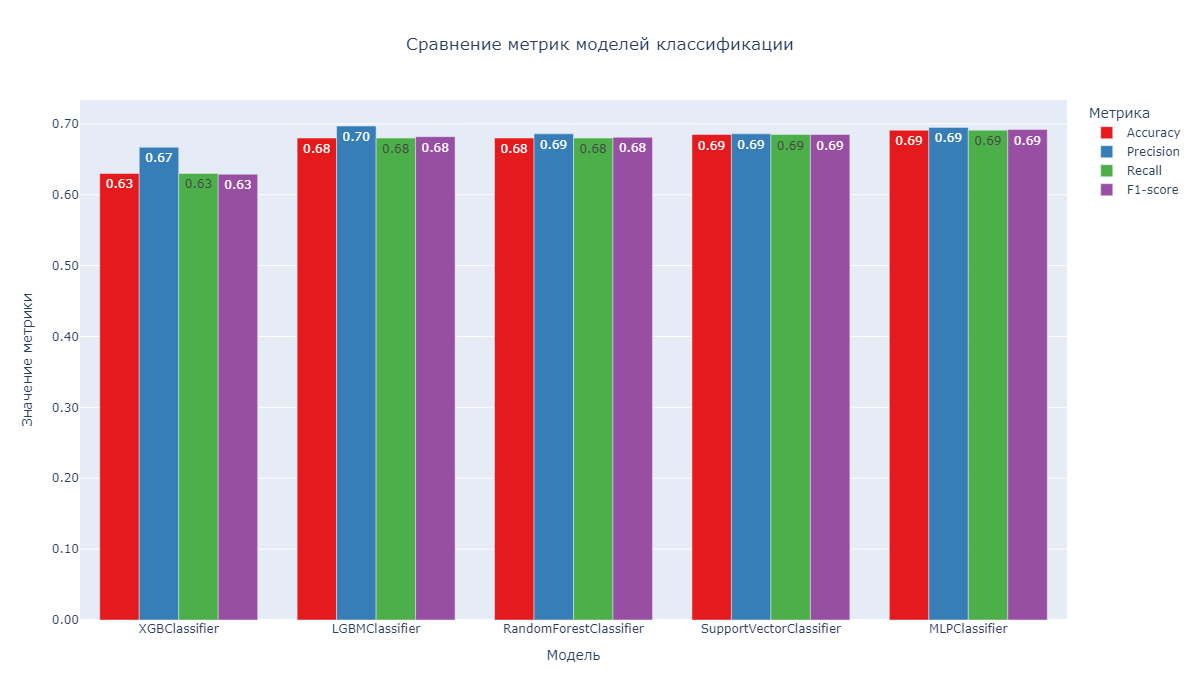

------------------------------------------------------------------------------------------------------------------------------------------------------


In [41]:
# Применяем функцию 'metrics_bar_plot()' для построения столбчатого графика метрик
metrics_bar_plot(
    data = metrics_df,
    main_title = 'Столбчатая диаграмма сравнения метрик моделей классификации:',
    title = 'Сравнение метрик моделей классификации',
    colors = px.colors.qualitative.Set1
)

#### $1.9$

#### **Вывод.**

На данном этапе сделаем вывод итоговым метрикам и моделям, обученным для предсказания целевой переменной `IC50_classif`.

Среди всех моделей `MLPClassifier` показывает наилучшее качество классификации соединений по `IC50` относительно медианного значения, так как модель хорошо сбалансирована, не жертвуя ни точностью, ни полнотой.

Так же данная модель подходит как для задач, где важны и точные предсказания, и минимизация ошибок по обоим классам.

Тем не менее, результаты несовсем удовлетворительны, необходима дополнительная обработка данных или добавить дополнительные гиперпараметры. 

=============================================================================================================================================

## <CENTER> **`2.` Machine Learning (превышает ли значение CC50 медианное значение выборки)**

На данном этапе мы построим несколько подходящих моделей регрессии для **CC50** и выберем наилучшую.

#### $2.1$

#### **Предобработка данных.**

Как и раньше, предобработаем данные при помощи созданного ранее пайплайна, только все этапы по предобработке, созданию и удалению признаков включим в отдельный класс.

Повторно загружаем пайплайн:

In [42]:
# Загружаем пайплайн при помощи joblib
preprocessing_pipeline = joblib.load('data/preprocessing_pipeline.joblib')
print("Пайплайн загружен из 'preprocessing_pipeline.joblib'")

Пайплайн загружен из 'preprocessing_pipeline.joblib'


Создаём целевую переменную:


Медианное значение CC50: 6.015652680235684
---------------------------------------------



Уникальные значения признака "CC50_classif":



CC50_classif
0    452
1    452
Name: count, dtype: int64

---------------------------------------------


Стобчатая и круговая диаграммы распределения целевой переменной:
------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



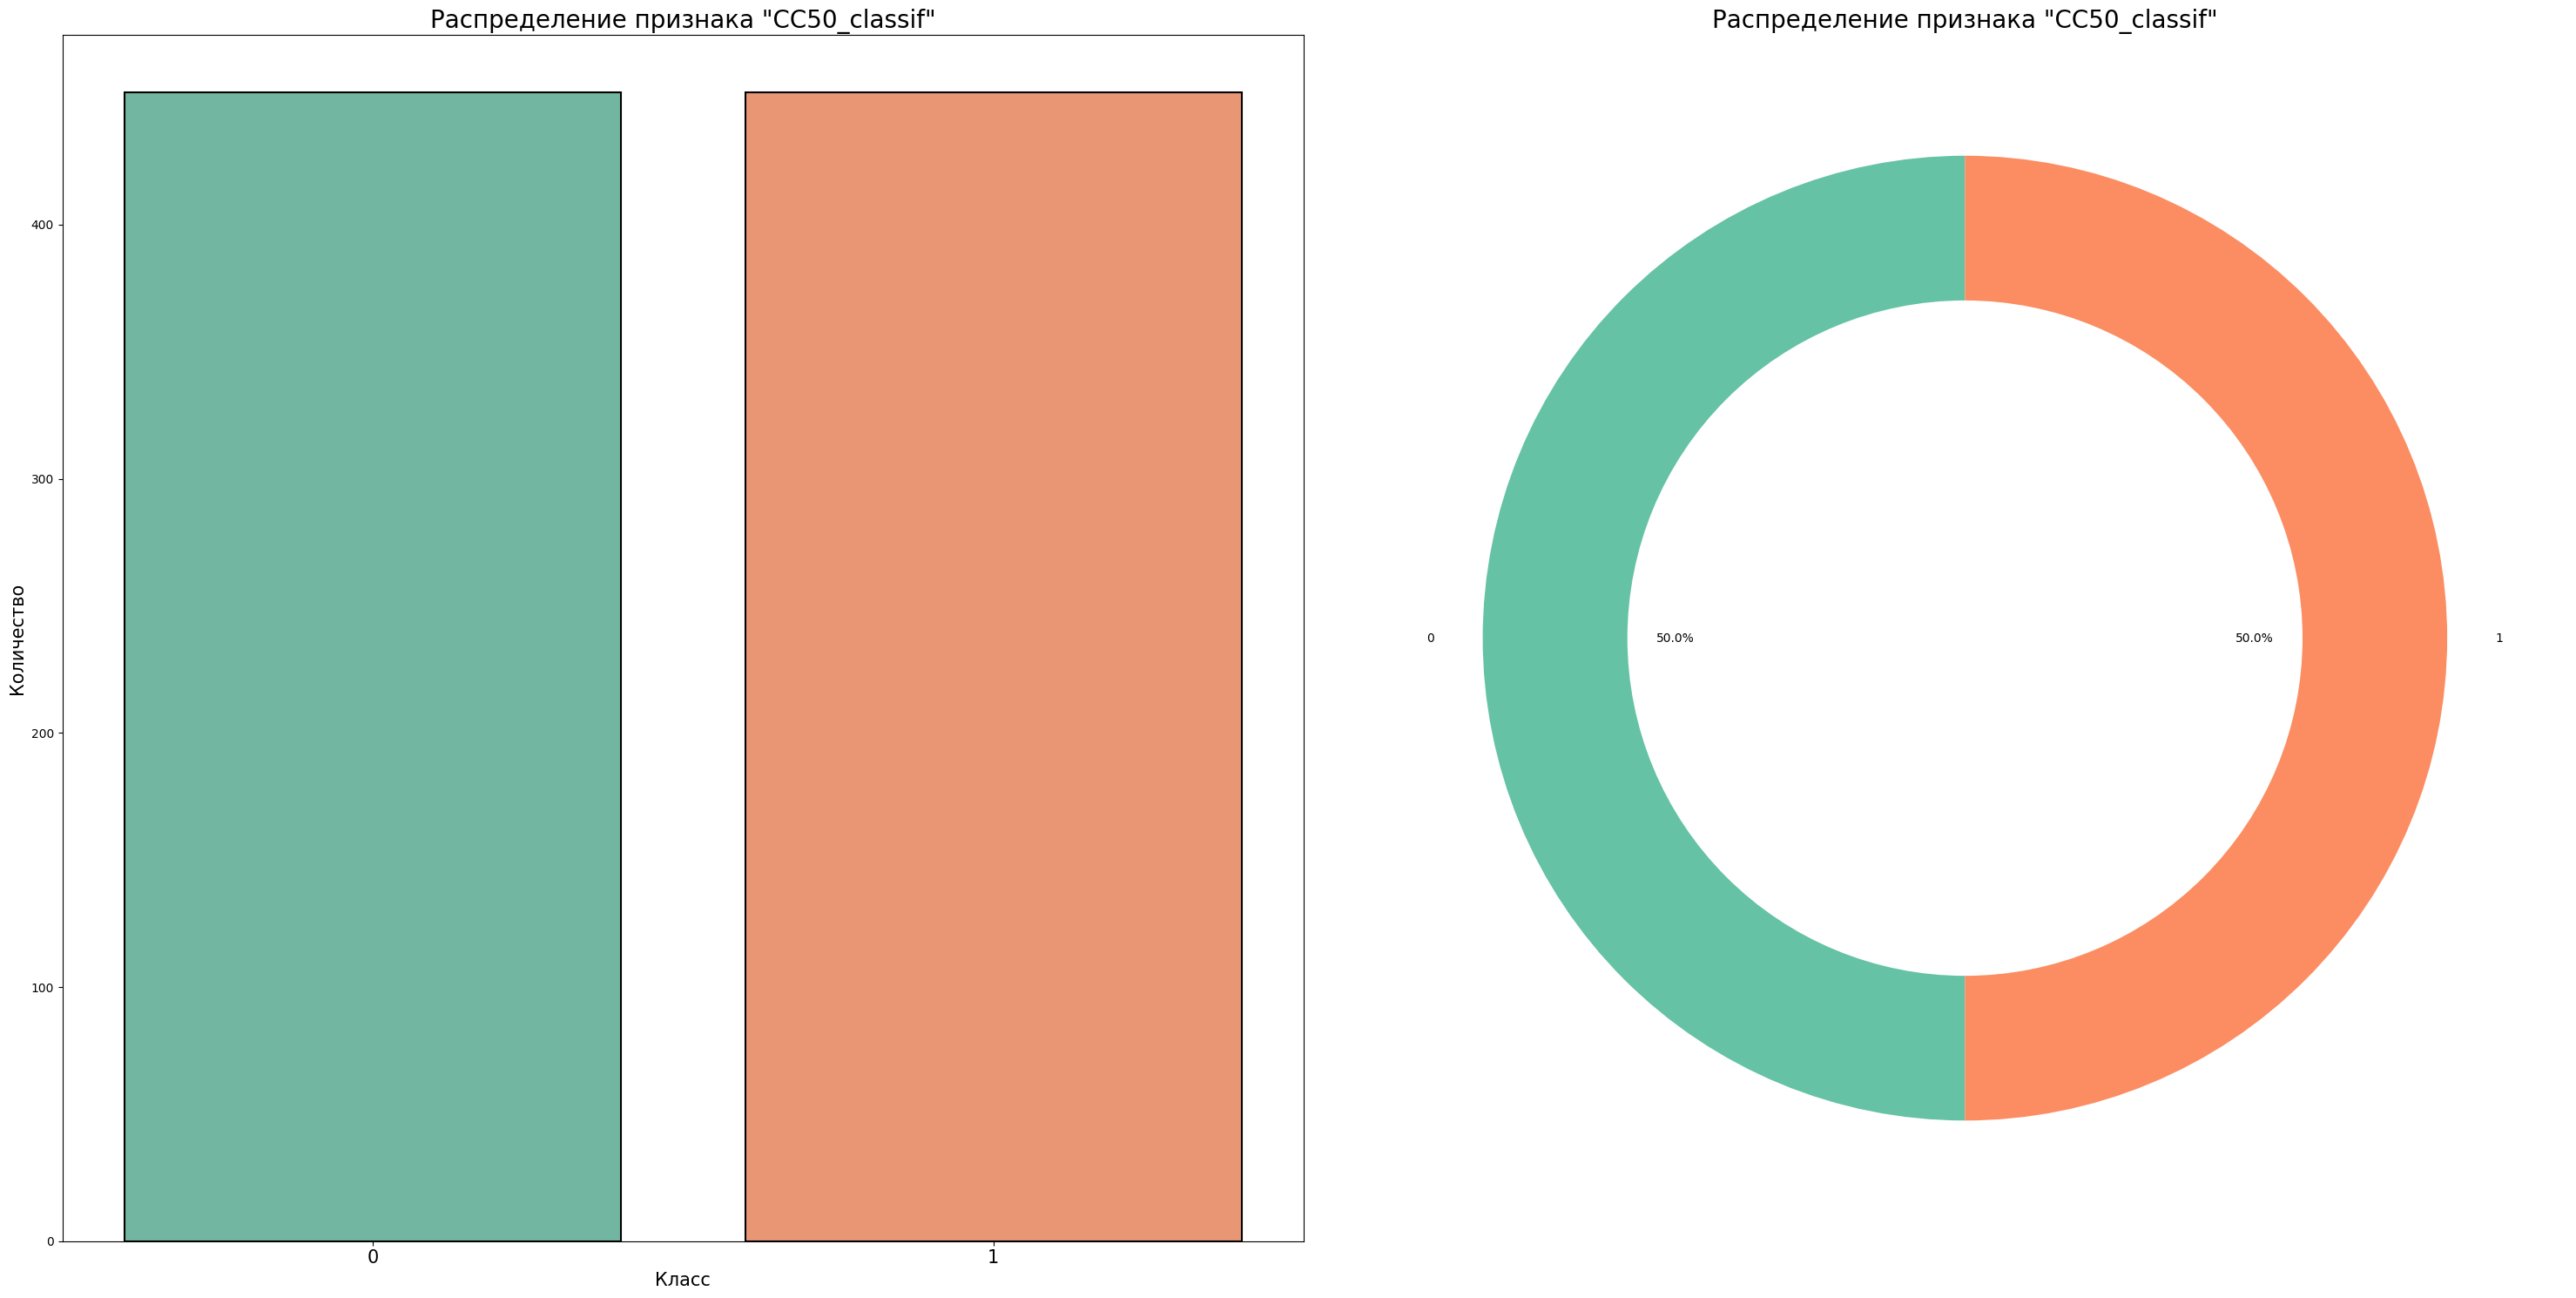

------------------------------------------------------------------------------------------------------------------------------------------------------


Распределение целевой переменной
------------------------------------------------------------------------------------------------------------------------------------------------------


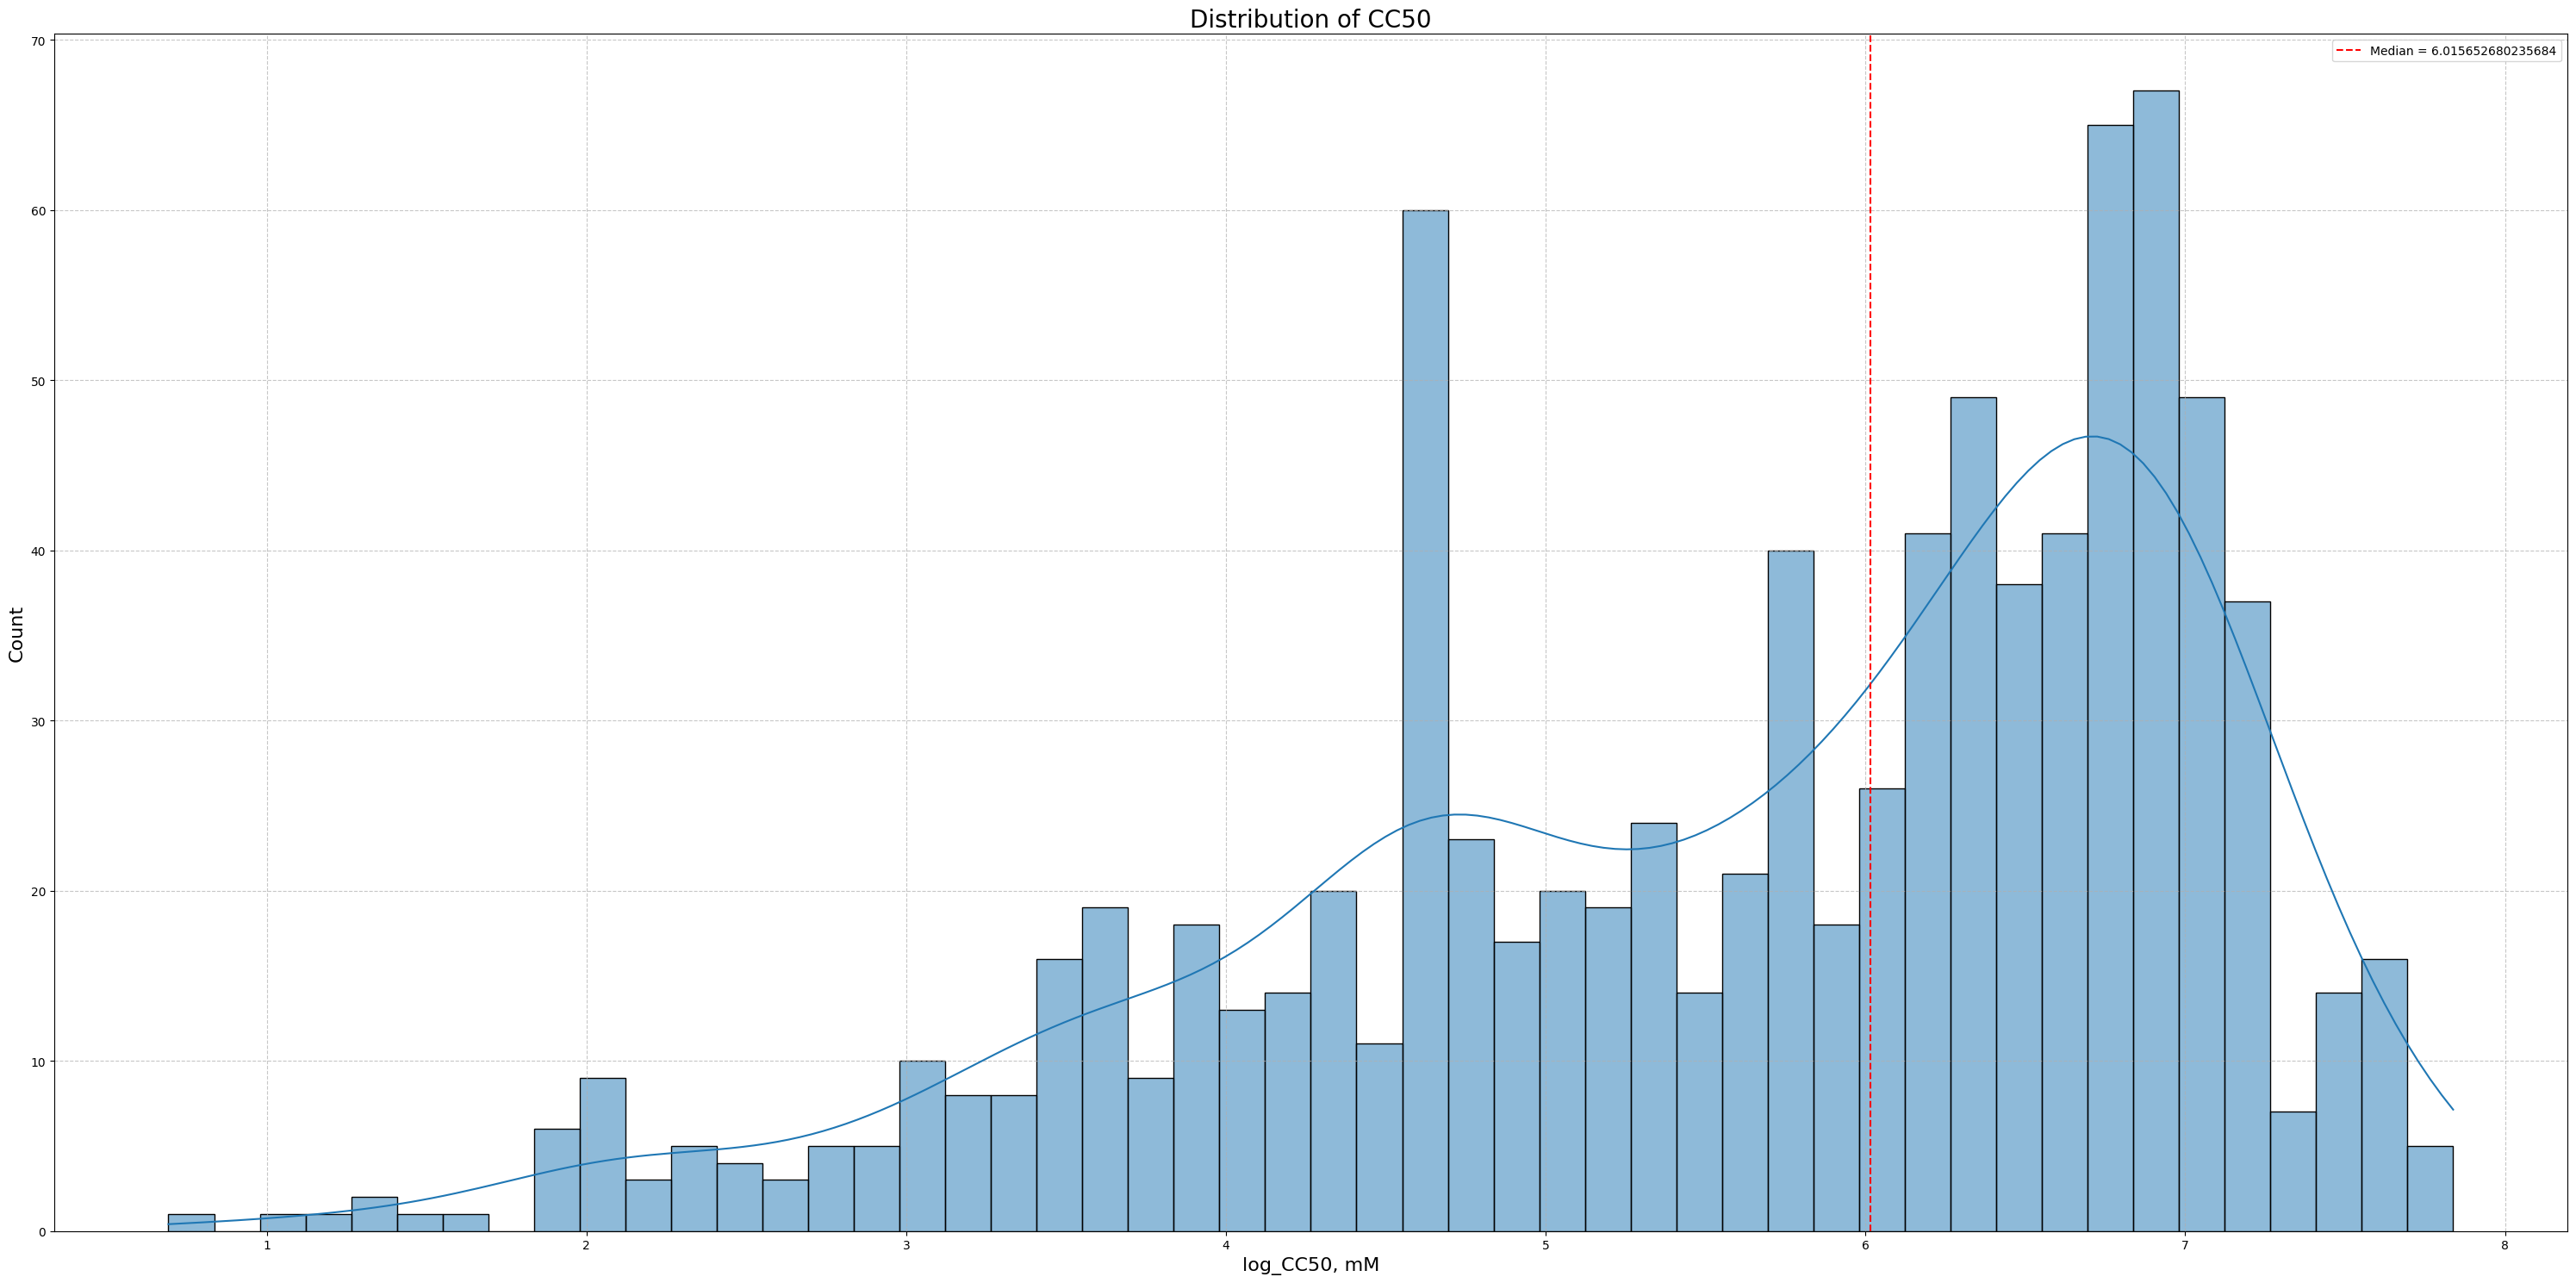

------------------------------------------------------------------------------------------------------------------------------------------------------


In [41]:
# Вычисляем медиану CC50
median_cc50 = molecule_df['log_CC50, mM'].median()
print(f'\nМедианное значение CC50: {median_cc50}')
print('-' * 45)
print('\n\n')


# Создаем целевую переменную (1 - превышает, 0 - не превышает)
molecule_df['CC50_classif'] = (molecule_df['log_CC50, mM'] > median_cc50).astype(int)
print('Уникальные значения признака "CC50_classif":\n')
display(molecule_df['CC50_classif'].value_counts())
print('-' * 45)




# Применяем функцию 'median_target_distribution_plot()' для построения графика распределения целевой переменной
median_target_distribution_plot(
    target = molecule_df['CC50_classif'],
    title1 = 'Распределение признака "CC50_classif"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной:',
    color_palette = 'Set2',
    figsize = (30, 15)
)

# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    data = molecule_df,
    target = 'log_CC50, mM',
    median_target = median_cc50,
    title = 'Distribution of CC50',
    main_title = 'Распределение целевой переменной',
    figsize = (30, 15)
)

**Вывод:**

Как видно по графику, распределение целевой переменной - равномерное, следовательно балансировка не требуется.

**Разделение данных.**

Разделим данные на тматрицу наблюдений и вектор правильных ответов:

In [44]:
# Разделяем данные на матрицу наблюдений и вектор правильных ответов
X = molecule_df.drop(columns = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI', 'IC50_classif', 'CC50_classif'])
y = molecule_df['CC50_classif']

**Создание класса.**

Создадим класс, в котором реализуем все этапы по созданию новых признаков, удалению нерелевантных признаков и предобработки данных:

In [39]:
# Создаём класс 'DataPreprocessor'       
class DataPreprocessor:
    
    
    
    # Задаём необходимые параметры
    def __init__(self, preprocessing_pipeline, random_state = 42):
        
        """
        Инициализация класса.
        preprocessing_pipeline: пайплайн с шагами feature_union, feature_selector, S_scaler.
        random_state: для воспроизводимости разбиения.
        
        """
        
        self.preprocessing_pipeline = preprocessing_pipeline
        self.random_state = random_state
        
        self.feature_names = (
            ['MolWt_TPSA', 'MolWt_per_Heteroatoms', 'TPSA_per_MolLogP'] +
    
            ['total_functional_groups', 'fr_amide_plus_ester', 'fr_benzene_times_nitro', 
             'fr_Al_OH_per_benzene', 'fr_amide_presence', 'fr_aldehyde_presence', 
             'fr_aniline_presence', 'fr_amidine_presence'] +
    
            ['PEOE_VSA_total', 'SMR_VSA_ratio', 'Chi0_times_Kappa1', 'TPSA_times_FractionCSP3'] +
            ['log_MolWt', 'MolLogP_squared', 'NumRotatableBonds_squared']
        )
        
        self.duplicated_features = ['Unnamed: 0', 'Unnamed: 0.1']
        self.X_train_full = None
        self.X_test_full = None
        self.X_train_processed_df = None
        self.X_test_processed_df = None
        self.y_train = None
        self.y_test = None
        self.partial_pipeline = None
        self.remaining_features = None
        
        
        
    # Удаляем признаки типов 'object' и 'category'          
    def remove_non_numeric_columns(self, data):
        
         """
         Удаление нечисловых столбцов.
         
         """
         
         return data.select_dtypes(include = [np.number])
     
     
     
    # Создаём новые признаки, удаляем нерелевантные и преобразовываем данные
    def fit_transform(self, X, y):
        
        """
        Разбиение данных, обучение пайплайнов и трансформация.
        X: исходные данные (без целевой переменной).
        y: целевая переменная 'CC50'.
        
        """
        
        # Разбиение на тренировочную и тестовую выборки
        X_train, X_test, self.y_train, self.y_test = model_selection.train_test_split(
            X, y,
            test_size = 0.2,
            random_state = self.random_state
        )
        
        # Удаляем дублирующиеся столбцы
        X_train = X_train.drop(columns=self.duplicated_features, axis=1, errors='ignore')
        X_test = X_test.drop(columns=self.duplicated_features, axis=1, errors='ignore')
        
        # Восстанавливаем индексы
        X_train = X_train.reset_index(drop = True)
        X_test = X_test.reset_index(drop = True)
        
        # Создаём новые признаки
        # для этого извлекаем 'FeatureUnion' из пайплайна и обучаем его
        feature_union_step = self.preprocessing_pipeline.named_steps['feature_union']
        feature_union_step.fit(X_train, self.y_train)
        
        # Применяем пайплайн к тренировочным и тестовым данным
        X_train_transformed = feature_union_step.transform(X_train)
        X_test_transformed = feature_union_step.transform(X_test)
        
        # Преобразуем результат обратно в DataFrame
        X_train_transformed_df = pd.DataFrame(
            X_train_transformed,
            columns = self.feature_names,
            index = X_train.index
        )
        X_test_transformed_df = pd.DataFrame(
            X_test_transformed,
            columns = self.feature_names,
            index = X_test.index
        )
        
        # Объединяем признаки
        self.X_train_full = pd.concat([X_train, X_train_transformed_df], axis=1)
        self.X_test_full = pd.concat([X_test, X_test_transformed_df], axis=1)

        # Удаляем нечисловые столбцы
        self.X_train_full = self.remove_non_numeric_columns(self.X_train_full)
        self.X_test_full = self.remove_non_numeric_columns(self.X_test_full)
        
        # Удалим нерелевантные признаки и стандартизируем данные
        # для начала извлечём шаги из пайплайна
        feature_selector = self.preprocessing_pipeline.named_steps['feature_selector']
        S_scaler = self.preprocessing_pipeline.named_steps['S_scaler']
        
        # Создание нового пайплайна с 'feature_selector' и 'S_scaler'
        self.partial_pipeline = pipeline.Pipeline([
            ('feature_selector', feature_selector),
            ('S_scaler', S_scaler)
        ])  
        
        # Обучаем созданный пайплайн на тренировочной выборке
        self.partial_pipeline.fit(self.X_train_full, self.y_train)

        # Применяем пайплайн к тренировочным и тестовым данным
        X_train_processed_full = self.partial_pipeline.transform(self.X_train_full)
        X_test_processed_full = self.partial_pipeline.transform(self.X_test_full)

        # Получаем список оставшихся признаков
        fs_step = self.partial_pipeline.named_steps['feature_selector']
        self.remaining_features = self.X_train_full.columns.difference(
            fs_step.to_drop_corr + fs_step.to_drop_var, sort=False
        )
        
        # Преобразуем результат обратно в DataFrame
        self.X_train_processed_df = pd.DataFrame(
            X_train_processed_full,
            columns = self.remaining_features,
            index = self.X_train_full.index
        )
        self.X_test_processed_df = pd.DataFrame(
            X_test_processed_full,
            columns = self.remaining_features,
            index = self.X_test_full.index
        )
        
        
        
    # Выводим результат
    def get_processed_data(self):
        
        """
        Возвращает обработанные данные.
        
        """
        
        processed_data = (
            self.X_train_processed_df,
            self.X_test_processed_df,
            self.y_train,
            self.y_test,
            self.remaining_features
        )
        
        return processed_data

Применим созданный класс к данным:

In [46]:
# Создаём экземпляра класса 'DataPreprocessor'
DP_processor = DataPreprocessor(preprocessing_pipeline)

# Обработка данных
DP_processor.fit_transform(X, y)

# Получение обработанных данных
X_train_processed_df, X_test_processed_df, y_train, y_test, remaining_features = DP_processor.get_processed_data()


Данные таблицы "Molecular properties features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
------------------------------------------------------------




Данные таблицы "Functional groups features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 8.
----------------------------------------
------------------------------------------------------------------------------------------




Данные таблицы "Topological descriptors features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 4.
----------------------------------------
--------------------------------------------------------------------------------




Данные таблицы "Transformations features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
---------------------------------------------------

Выводим результат:

In [47]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_processed_df,
    data_name = 'X_train_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_processed_df,
    data_name = 'X_test_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по оставшимся признакам
print(f'Оставшиеся признаки:\n\n{remaining_features.tolist()}')
print('-' * 150)


Данные таблицы "X_train_processed_df" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 103.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_quatN,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,-1.496602,0.422613,0.771519,0.579771,-0.081941,-0.172284,-0.720975,-0.482466,-0.231601,0.709602,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064531,-0.017568,-0.338656,-0.806000,-0.332149
1,0.527403,0.904784,-0.394927,0.514586,-0.554818,-0.694608,-0.970049,-0.465835,0.425592,0.670103,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064565,0.133615,-0.338656,-0.806000,-0.857136
2,0.252959,-0.894628,0.392277,0.397569,0.511590,-0.034503,1.347721,0.555049,-0.313054,0.077316,...,-0.174679,-0.210093,-0.266667,3.294307,-0.177731,-0.064578,0.146636,-0.338656,0.736551,1.215385
3,-1.210453,0.216033,0.750903,0.746949,1.699045,-1.145565,-0.554926,-0.589790,-0.967502,0.838770,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064458,-0.019390,-0.338656,-0.806000,-0.065901
4,0.694610,-0.824197,0.472459,1.392750,-0.120265,-0.264281,0.954612,0.555048,-0.403346,-0.483621,...,-0.174679,-0.210093,3.750000,-0.303554,-0.177731,-0.064567,0.009951,-0.338656,0.207477,-0.043975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.251380,0.324610,0.428609,-0.563375,-0.001549,-0.241286,0.655849,-0.479027,-0.231089,0.700544,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064533,-0.010548,-0.338656,0.211154,-0.300668
719,-1.577604,1.146384,0.843749,0.769183,0.451116,-0.010688,0.083725,-0.482669,-0.749877,0.230117,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064481,-0.085575,-0.338656,-0.300500,-0.744117
720,0.439661,-0.198519,0.198692,0.502574,-0.661393,0.463493,-0.416552,0.557248,0.434471,-0.335264,...,-0.174679,3.494726,-0.266667,-0.303554,-0.177731,-0.064571,0.086950,-0.338656,-0.806000,-0.622234
721,0.980138,-0.326590,-0.499596,-0.363831,-1.475648,0.285924,-0.703184,-0.304289,0.607120,-1.303146,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064583,0.134657,-0.338656,-0.806000,-0.643005


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_processed_df" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 103.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_quatN,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,0.160756,-0.510352,-0.302029,-0.353559,-1.315644,-0.863532,1.780140,0.559264,2.296748,-1.732256,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064599,-1.198955,-0.338656,0.168554,-0.016665
1,0.552605,-0.468304,-2.184035,-1.056662,-1.369489,-0.089109,0.528003,0.552297,1.154219,-0.893501,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064590,0.128426,-0.338656,1.068112,-0.717143
2,-0.045459,-1.061101,0.108325,0.426638,0.811860,-0.471906,1.224172,-0.471246,-0.265352,0.017607,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064578,0.213022,1.475033,1.241226,1.433804
3,0.464136,0.524951,-1.212053,-1.368374,-0.291834,0.854706,0.353155,0.492597,-0.231089,0.701536,...,-0.174679,-0.210093,-0.266667,-0.303554,0.788429,-0.064576,0.094904,-0.338656,1.152177,1.983047
4,-1.720945,1.330435,0.862116,-1.065667,0.899075,0.426860,-2.215418,-0.592477,-0.231368,0.760929,...,-0.174679,-0.210093,-0.266667,-0.303554,4.653068,-0.064459,-0.076881,-0.338656,-0.806000,-0.190647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-1.488398,1.708016,0.899797,0.058433,1.462212,-1.667184,0.690443,-0.603011,0.127272,-0.483112,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064510,0.065149,-0.338656,-0.806000,-0.065901
177,0.562094,0.446785,0.434776,0.703003,-1.149026,-0.103926,-0.554926,-0.504065,0.884829,-1.319795,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064572,0.100585,-0.338656,-0.806000,-0.833169
178,0.417928,0.379878,0.409685,-0.011909,-1.476949,-0.073419,-0.395263,-0.482662,1.260989,-2.026415,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064572,0.099420,-0.338656,-0.806000,-0.842731
179,0.044589,-0.244271,0.028994,1.031010,0.347881,0.057249,-0.075938,-0.478956,-0.226828,0.099772,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064570,0.247098,-0.338656,-0.806000,0.764520


------------------------------------------------------------------------------------------------------------------------------------------------------




Оставшиеся признаки:

['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA7', 'SlogP_VSA8', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState4', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NumAliphatic

По результатам видно, что данные, после применения класса, имеют схожую структуру, что и при прошлой предобработки.

Проверим распределение признаков при помощи визуализации:


График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


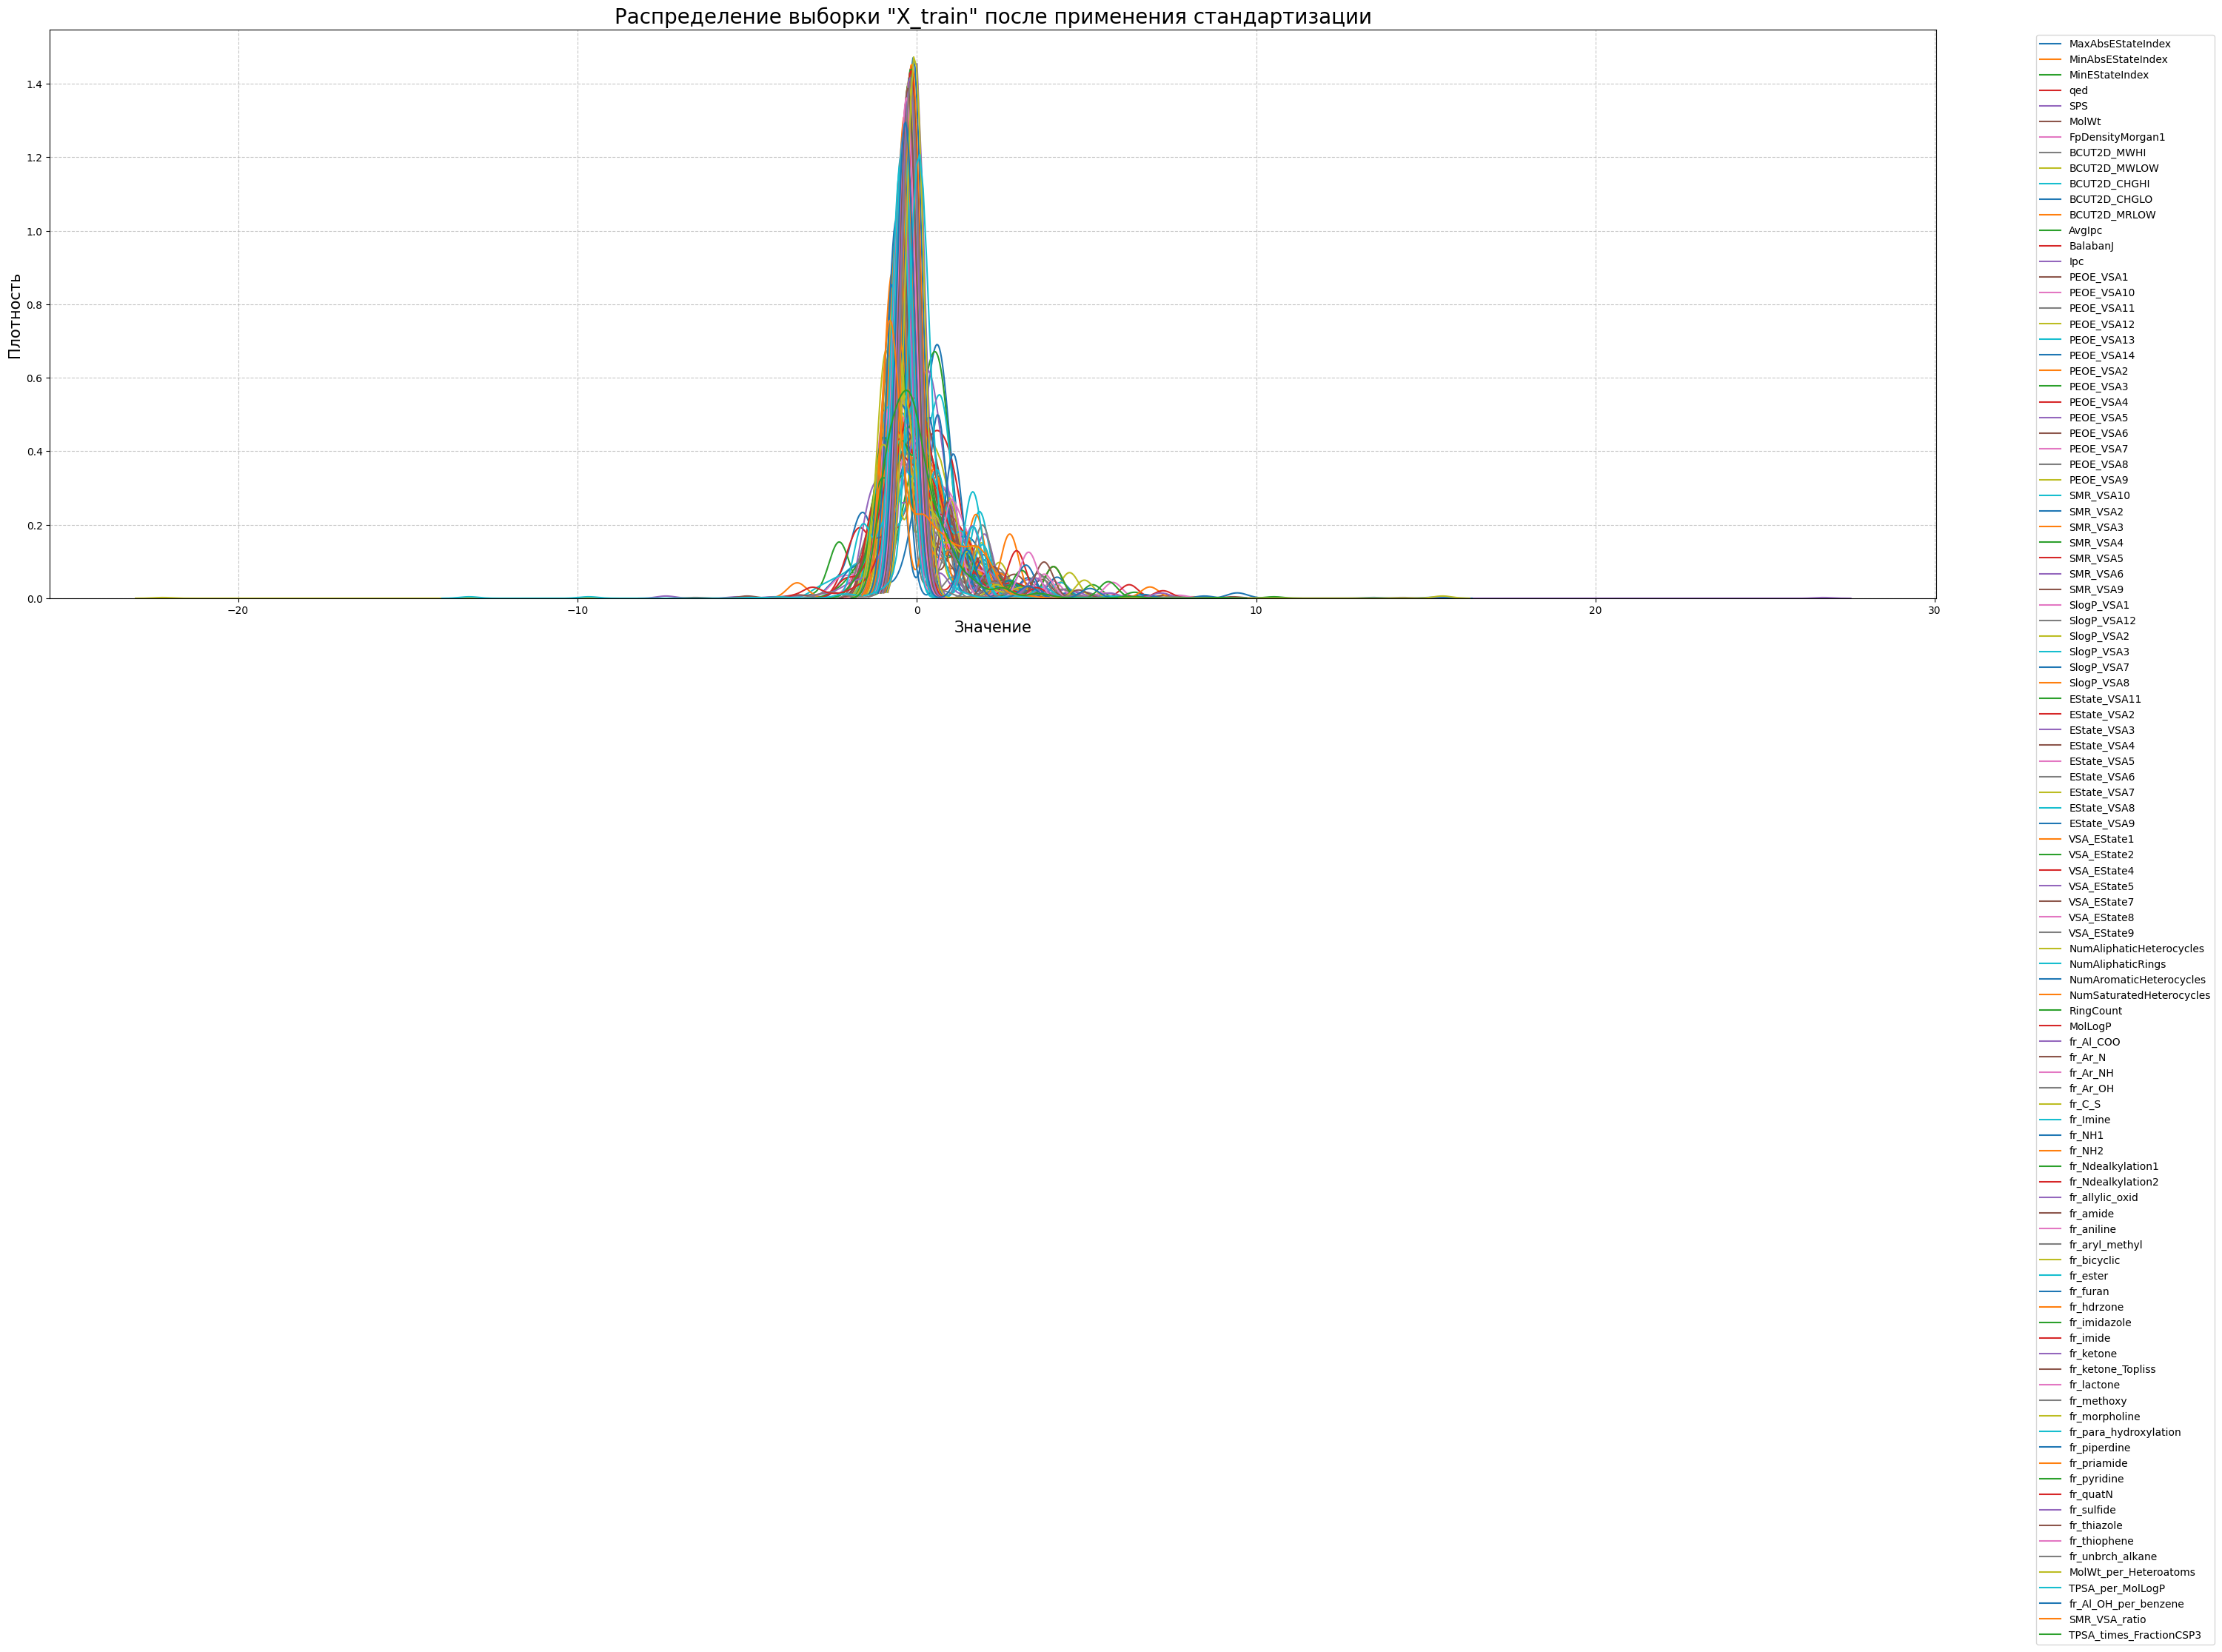

------------------------------------------------------------------------------------------------------------------------------------------------------



График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


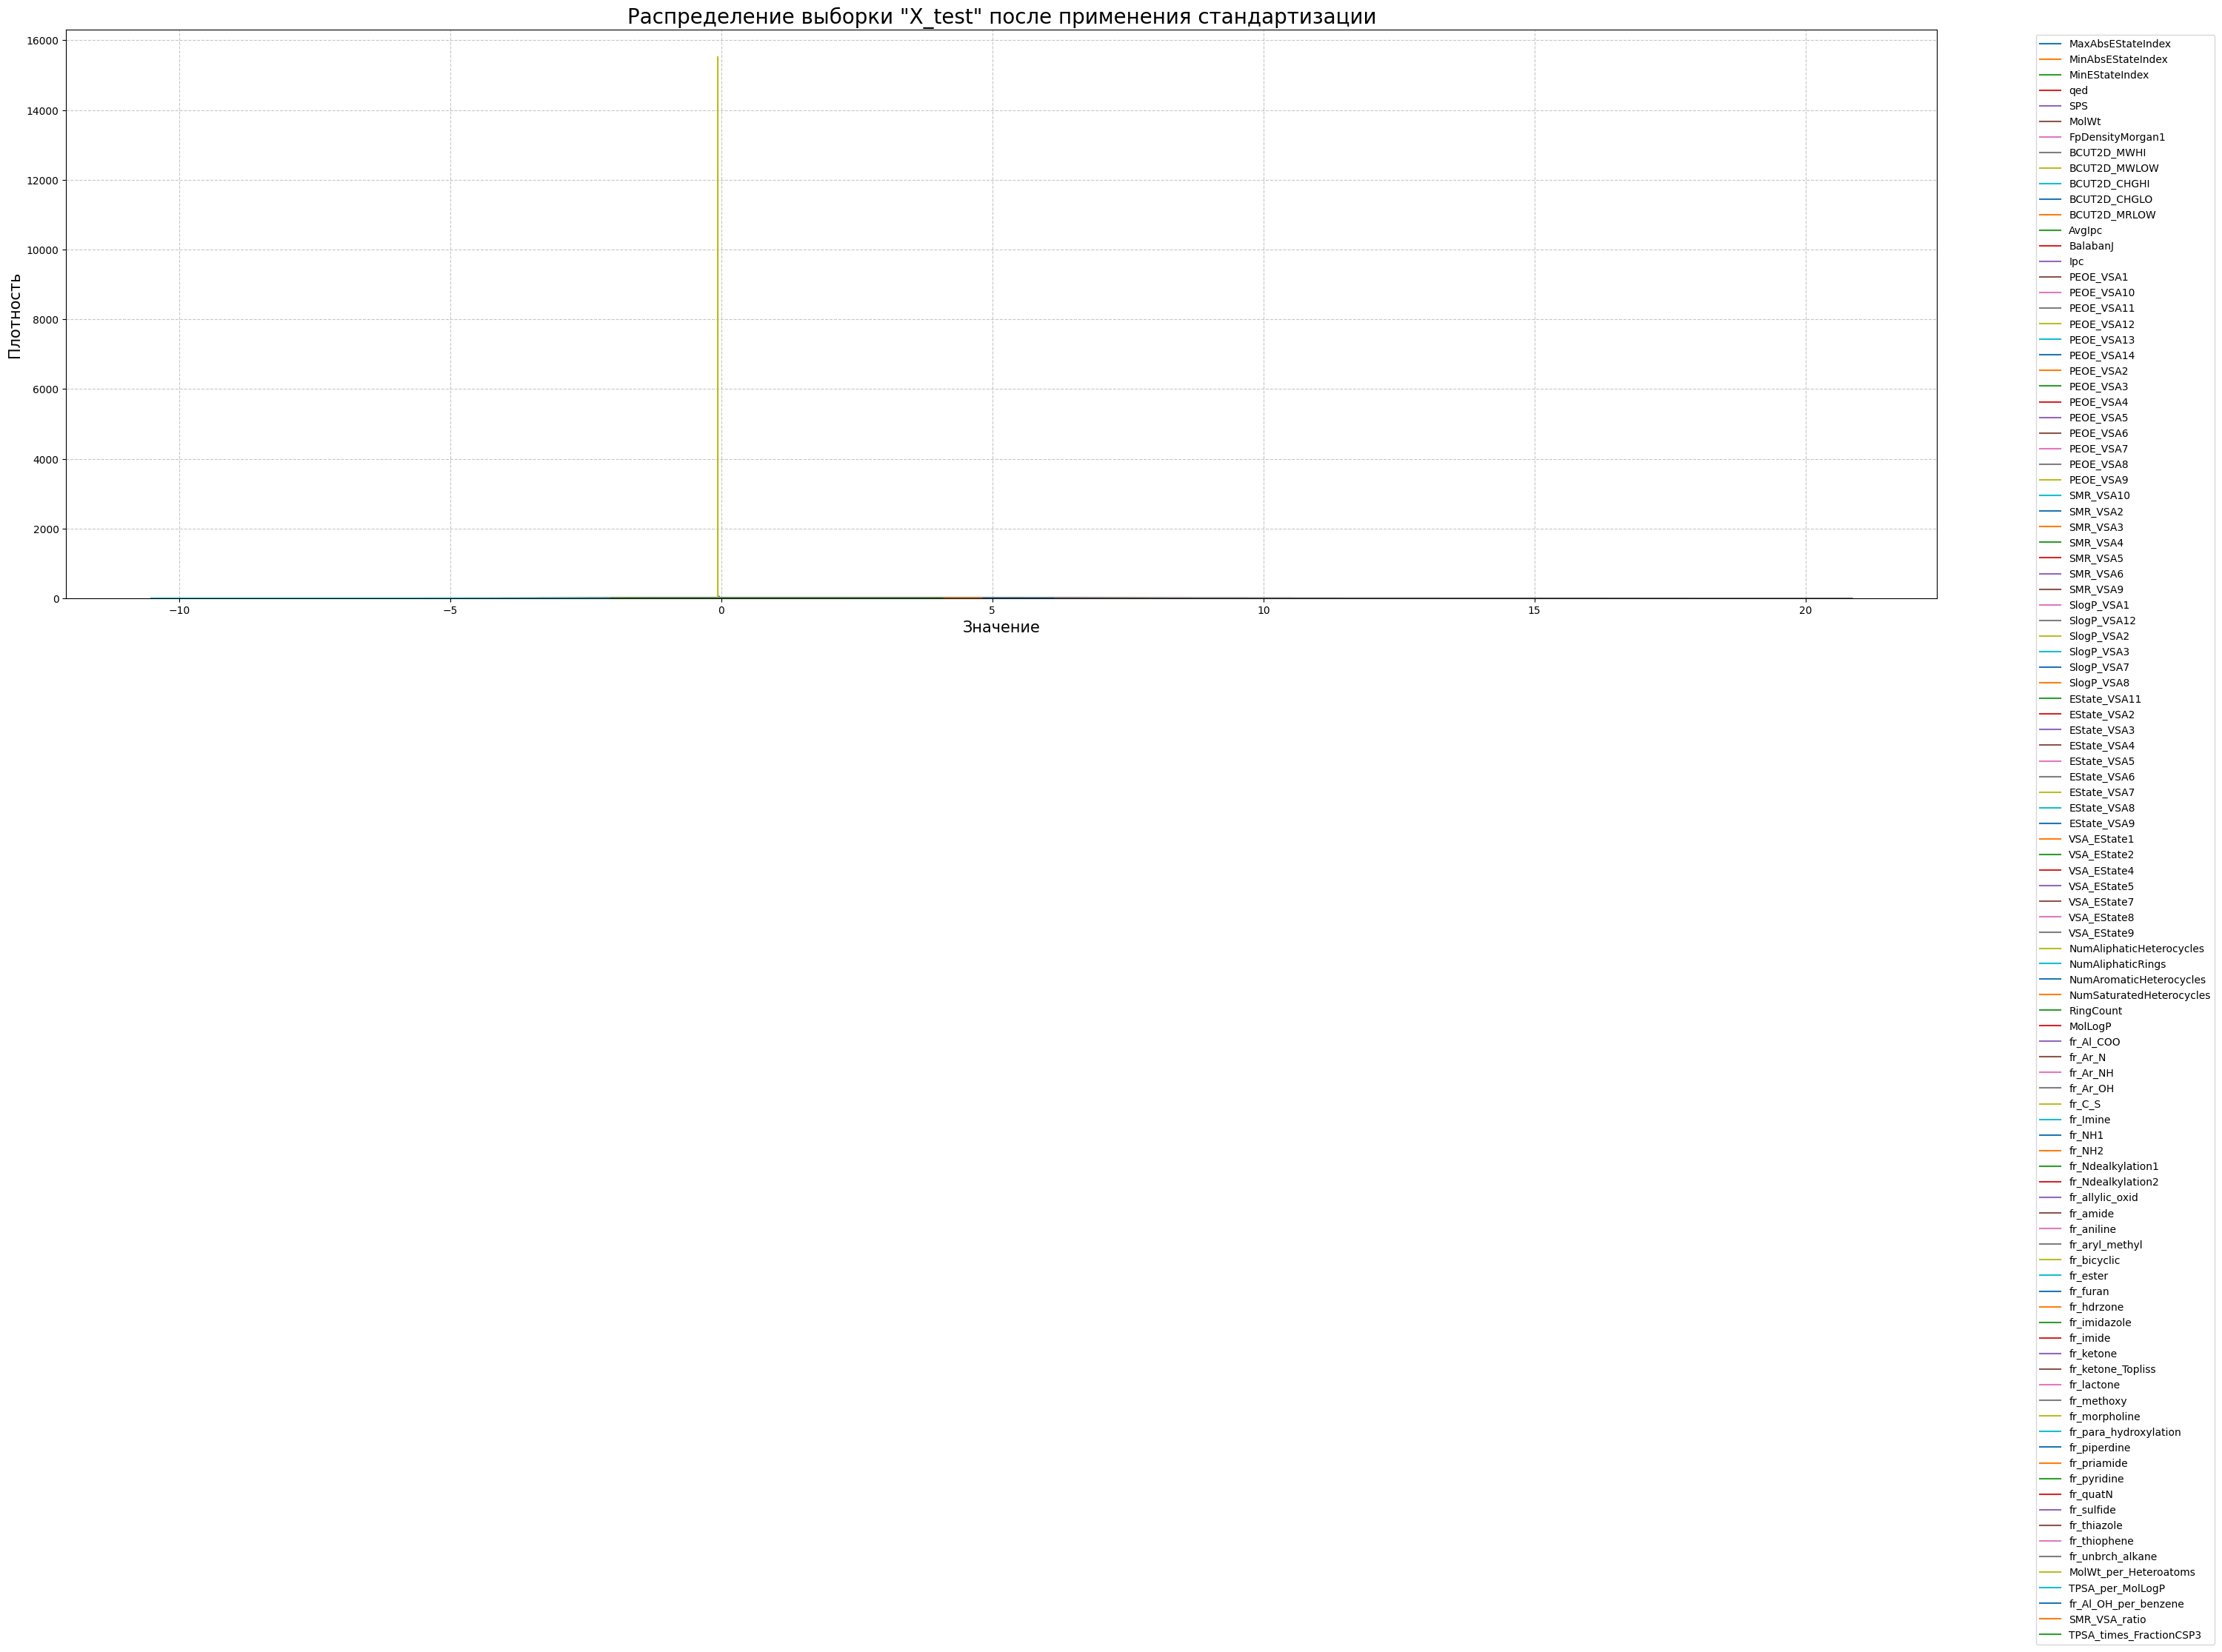

------------------------------------------------------------------------------------------------------------------------------------------------------


In [48]:
# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_train
print()
features_distribution_plot(
    data = X_train_processed_df,
    title = 'Распределение выборки "X_train" после применения стандартизации',
    figsize = (30, 17)
)

# Добавляем отступ
print('\n\n')



# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_test
features_distribution_plot(
    data = X_test_processed_df,
    title = 'Распределение выборки "X_test" после применения стандартизации',
    figsize = (30, 17)
)

**Вывод:**

Распределение признаков также нормализовалось.

#### $2.2$

#### **Отбор самых информативных признаков.**

На данном этапе отберём только самые информативные признаки для дальнейшего решения задачи регрессии.

Производить отбор признаков будем так же, как и для `CC50`, в $4$ этапа:

1. Отберём $50$ признаков с помощью алгоритма **Mutual Information**,
2. Отберём $50$ признаков с помощью алгоритма **F-test**,
3. Отберём $50$ признаков из отобранных обоими алгоритмами,
4. Из оставшихся отберём $30$ признаков с помощью алгоритма **Lasso**.

Только сейчас, все этапы обернём в класс, чтобы использовать его в будущем.

**Создание класса.**

Создадим класс `FeatureSelector`, в котором реализуем все $4$ этапа по отбору самых информативных признаков.

В данный класс включим алгоритмы **Mutual Information**, **F-test** и **Lasso**:

In [40]:
# Создаём класс 'FeatureSelector'          
class FeatureSelector(BaseEstimator, TransformerMixin):
    
    
    
    # Задаём необходимые параметры
    def __init__(self, mi_k=50, f_k=50, log_max_features=30, penalty='l1', solver='liblinear', C=1.0, random_state=42):
    
        """
        Инициализация класса.
        mi_k: количество признаков для Mutual Information.
        f_k: количество признаков для F-теста.
        lasso_max_features: максимальное число признаков для LogisticRegression.
        lasso_alpha: параметр регуляризации для LogisticRegression.
        random_state: для воспроизводимости.
        
        """
        
        self.mi_k = mi_k
        self.f_k = f_k
        self.log_max_features = log_max_features
        self.penalty = penalty
        self.solver = solver
        self.C = C
        self.random_state = random_state
        self.mi_selector = None
        self.f_selector = None
        self.log_model = None
        self.log_selector = None
        self.mi_scores = None
        self.f_scores = None
        self.log_scores = None
        self.mi_selected_features = None
        self.f_selected_features = None
        self.common_features = None
        self.final_features = None
        self.X_train_final = None
        self.X_test_final = None
        
        
        
    # Отбор 50 признаков (Mutual Information)
    def fit_mi(self, X, y):
        
        """
        Фильтрация с помощью Mutual Information.
        
        """
        
        self.mi_selector = feature_selection.SelectKBest(score_func=feature_selection.mutual_info_classif, k=self.mi_k)
        self.mi_selector.fit(X, y)
        self.mi_scores = pd.Series(self.mi_selector.scores_, index = X.columns).sort_values(ascending = False)
        self.mi_selected_features = X.columns[self.mi_selector.get_support()].tolist()
        
        
        
    # Отбор 50 признаков (F-test)
    def fit_f_test(self, X, y):
        
        """
        Фильтрация с помощью F-теста.
        
        """
        
        self.f_selector = feature_selection.SelectKBest(score_func = feature_selection.f_classif, k = self.f_k)
        self.f_selector.fit(X, y)
        self.f_scores = pd.Series(self.f_selector.scores_, index = X.columns).sort_values(ascending = False)
        self.f_selected_features = X.columns[self.f_selector.get_support()].tolist()
        
        
        
    # Из отобранных признаков обоими алгоритмами отберём те, которые попали в оба списка
    def select_common_features(self):
        
        """
        Отбор лучших 50 признаков из пересечения MI и F-теста.
        
        """
        
        self.common_features = list(set(self.mi_selected_features) & set(self.f_selected_features))
        
        if len(self.common_features) < self.mi_k:
            additional_features = [feature for feature in self.mi_selected_features if feature not in self.common_features]
            self.common_features.extend(additional_features[:self.mi_k - len(self.common_features)]) 
            
            
            
    # Отбираем 30 признаков (LogRegression)
    def fit_log(self, X, y):
        
        """
        Применение LogisticRegression для выбора 30 признаков.
        
        """
        
        self.log_model = linear_model.LogisticRegression(penalty=self.penalty, solver=self.solver, C=self.C, random_state=self.random_state)
        self.log_model.fit(X, y)
        self.log_scores = pd.Series(self.log_model.coef_[0], index = X.columns).abs().sort_values(ascending=False)
        self.log_selector = feature_selection.SelectFromModel(self.log_model, prefit=True, max_features=self.log_max_features)
        self.final_features = X.columns[self.log_selector.get_support()].tolist() 
        
        
        
    # Преобразовываем данные
    def transform(self, X_train, X_test):
        
        """
        Трансформация данных с учетом отобранных признаков.
        
        """
        
        # Фильтрация до 50 признаков
        X_train_filtered = X_train[self.common_features]
        X_test_filtered = X_test[self.common_features]

        # Применение LogisticRegression и создание финального DataFrame
        X_train_final_transformed = self.log_selector.transform(X_train_filtered)
        self.X_train_final = pd.DataFrame(
            X_train_final_transformed,
            columns = self.final_features,
            index = X_train.index
        )
        
        self.X_test_final = X_test_filtered[self.final_features]
        
        
    
    # Применяем отбор признаков к тренировочной и тестовой выборке    
    def fit_transform(self, X_train, X_test, y_train):
        
        """
        Полный процесс отбора признаков.
        X_train, X_test: исходные данные.
        y_train: целевая переменная.
        
        """
        
        self.fit_mi(X_train, y_train)
        self.fit_f_test(X_train, y_train)
        self.select_common_features()
        self.fit_log(X_train.loc[:, self.common_features], y_train)
        self.transform(X_train, X_test)
        
        
        
    # Вывод преобразованных данных
    def get_final_data(self):
        
        """
        Возвращает отфильтрованные данные.
        
        """
        
        return self.X_train_final, self.X_test_final, self.final_features



    # Выводим отобранные признаки
    def print_results(self):
        
        """ 
        Вывод результатов отбора признаков.
        
        """
        
        print(f'\nТоп-30 финальных признаков после "LogisticRegression"\n\n{self.log_scores.head(50)}')
        print('-' * 40)

Применим созданный класс к данным:

In [50]:
# Инициализируем класс 'FeatureSelector'         
feature_selector = FeatureSelector(
    mi_k = 50,
    f_k = 50,
    log_max_features = 30,
    penalty = 'l1',
    solver = 'liblinear',
    C = 1.0
)

# Обучаем класс на данных
feature_selector.fit_transform(X_train_processed_df, X_test_processed_df, y_train)

# Получение обработанных данных
X_train_final, X_test_final, final_features = feature_selector.get_final_data()

# Выводим результат
feature_selector.print_results()


Топ-30 финальных признаков после "LogisticRegression"

AvgIpc                      0.858101
VSA_EState1                 0.620910
SPS                         0.504856
VSA_EState5                 0.498231
SlogP_VSA3                  0.484352
NumSaturatedHeterocycles    0.459048
VSA_EState2                 0.417501
PEOE_VSA11                  0.408170
PEOE_VSA8                   0.400835
fr_allylic_oxid             0.359138
EState_VSA4                 0.354596
SlogP_VSA12                 0.348363
BCUT2D_CHGLO                0.338966
NumAliphaticRings           0.318596
fr_C_S                      0.299241
PEOE_VSA1                   0.281390
EState_VSA5                 0.254842
SMR_VSA10                   0.253753
PEOE_VSA6                   0.253747
SMR_VSA4                    0.251588
EState_VSA9                 0.231712
BCUT2D_MRLOW                0.221575
SlogP_VSA1                  0.201547
PEOE_VSA9                   0.185933
BCUT2D_MWHI                 0.184069
EState_VSA6        

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning:

X has feature names, but SelectFromModel was fitted without feature names



Выведем информацию итоговых выборок:

In [51]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_final,
    data_name = 'X_train_final',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_final,
    data_name = 'X_test_final',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_final" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 30.
----------------------------------------


,VSA_EState1,EState_VSA6,SMR_VSA4,fr_C_S,NumAliphaticRings,NumSaturatedHeterocycles,fr_allylic_oxid,PEOE_VSA6,EState_VSA5,PEOE_VSA9,...,PEOE_VSA2,SMR_VSA10,SlogP_VSA1,SlogP_VSA12,SlogP_VSA3,SlogP_VSA8,EState_VSA4,VSA_EState2,VSA_EState5,MolWt_per_Heteroatoms
0,-0.510177,-0.864386,0.809641,-0.222142,-0.123882,-0.725093,-0.446305,-0.283280,-0.034495,-0.741801,...,-0.188942,0.106999,0.660333,-0.543354,-1.068602,-0.571672,1.012479,-0.731273,0.875327,-0.064531
1,-0.228040,1.790326,-0.927114,-0.222142,-0.123882,-0.725093,-0.446305,-0.116601,-0.910332,0.137453,...,-0.221873,-0.287725,-0.224524,-0.543354,0.254254,-0.571672,-1.063253,0.683650,-0.723162,-0.064565
2,-0.483553,0.083050,0.018407,-0.222142,-0.123882,0.508418,-0.446305,-0.096764,-0.088791,0.172684,...,1.461457,0.488749,-0.135027,0.797640,0.129488,-0.571672,0.237265,0.581600,0.320846,-0.064578
3,-0.823985,-0.864386,1.381794,-0.222142,1.344428,-0.725093,-0.446305,-0.613549,1.211398,-1.196283,...,-1.019830,-1.157446,-0.070691,-0.543354,-1.068602,-0.571672,-0.209812,-1.092745,1.075515,-0.064458
4,-0.068435,-0.421934,-0.061945,-0.222142,-0.858037,-0.725093,-0.446305,0.257495,0.197581,0.107904,...,-1.019830,0.817315,-0.135027,0.797640,-1.068602,0.820604,1.428540,-0.768015,-0.077143,-0.064567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,-0.542370,-0.421230,0.809641,-0.222142,-0.123882,-0.725093,-0.446305,1.163576,0.252332,-0.673288,...,-0.188942,0.156622,-0.955548,-0.543354,0.129488,0.256341,-0.199418,0.099133,0.172446,-0.064533
719,-0.524807,-0.052843,-0.021769,-0.222142,0.610273,0.508418,-0.446305,1.221381,1.176775,-0.140364,...,-0.204336,-1.157446,-0.955548,-0.543354,1.014571,-0.571672,0.803055,-0.899965,0.530838,-0.064481
720,-0.541832,0.019495,-0.519580,-0.222142,-0.123882,0.508418,-0.446305,1.040884,-0.656068,0.311096,...,2.294595,1.757702,0.595997,0.847924,-0.465932,0.896349,1.329183,0.650119,0.166710,-0.064571
721,2.477075,-0.864386,-0.927114,-0.222142,-1.592192,-0.725093,-0.446305,-1.274086,0.620040,0.938577,...,-0.221873,0.096054,1.344306,-0.543354,-0.473182,2.466311,-0.954993,0.705109,-2.182500,-0.064583


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_final" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 30.
----------------------------------------


,VSA_EState1,EState_VSA6,SMR_VSA4,fr_C_S,NumAliphaticRings,NumSaturatedHeterocycles,fr_allylic_oxid,PEOE_VSA6,EState_VSA5,PEOE_VSA9,...,PEOE_VSA2,SMR_VSA10,SlogP_VSA1,SlogP_VSA12,SlogP_VSA3,SlogP_VSA8,EState_VSA4,VSA_EState2,VSA_EState5,MolWt_per_Heteroatoms
0,-0.196948,-0.864386,-0.927114,-0.222142,-1.592192,-0.725093,-0.446305,-1.274086,-0.615020,0.074155,...,0.478616,0.499853,-0.097606,-0.543354,0.288896,0.215681,-1.452750,0.680807,-0.355714,-0.064599
1,1.861870,-0.864386,-0.519580,4.501634,-1.592192,-0.725093,-0.446305,-1.274086,0.562000,-0.284854,...,0.731763,0.968608,0.702317,0.901861,-0.292246,-0.571672,-1.028044,-1.092745,-0.134131,-0.064590
2,-0.215910,-0.421934,0.018407,-0.222142,-0.123882,0.508418,-0.446305,-0.637539,-0.623961,0.223838,...,0.663501,-0.722000,-0.955548,-0.543354,-0.473182,-0.571672,-0.104185,-0.360243,0.318123,-0.064578
3,0.821808,-0.864386,0.809641,-0.222142,-0.123882,-0.725093,-0.446305,-0.034597,-0.034495,2.426146,...,1.350016,-0.172658,-0.955548,0.355126,2.891055,-0.571672,0.708760,-0.738469,0.292743,-0.064576
4,-0.823985,-0.031220,2.546396,-0.222142,1.344428,-0.725093,-0.446305,1.932642,2.726919,-1.196283,...,0.641946,-0.312085,-0.955548,-0.543354,-1.068602,-0.571672,0.292272,-0.357125,0.653392,-0.064459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-0.823985,-0.864386,0.949210,-0.222142,-0.123882,-0.725093,-0.446305,-0.967807,0.302085,-1.196283,...,-1.019830,-1.157446,-0.070691,-0.543354,-1.068602,-0.571672,-0.209812,-1.092745,1.076714,-0.064510
177,-0.754509,0.083050,-0.120755,-0.222142,-0.858037,-0.725093,-0.446305,1.016894,-0.689321,0.169628,...,0.681144,0.976483,-0.118205,-0.543354,-1.068602,0.962434,-0.275581,0.152801,0.085952,-0.064572
178,-0.135080,0.020518,-0.927114,-0.222142,-1.592192,-0.725093,-0.446305,0.172770,-0.614671,0.708890,...,0.663003,0.536398,0.595997,-0.543354,-0.245931,0.931911,-0.277778,0.121094,0.432689,-0.064572
179,0.380878,0.691279,-0.454353,-0.222142,-0.123882,0.508418,0.829103,-0.984255,-0.910332,1.931287,...,-1.019830,-1.157446,1.237523,-0.543354,-0.473182,-0.571672,-0.673080,-1.092745,0.531638,-0.064570


------------------------------------------------------------------------------------------------------------------------------------------------------


**Построение визуализаций.**

Создадим функцию, для построения `treemap` графиков отобранных признаков:

In [69]:
# Функция для построения treemap диаграммы признаков
def treemap_features(data, title = None, main_title = None, color = None):
    
    
    """
    Функция для построения treemap диаграммы признаков.
    
    Параметры:
    - data: pandas Series с признаками и их важностью.
    - title: заголовок графика.
    - main_title: основной заголовок графика.
    - color: цветовая палитра для графика.
    
    """
    
    
    # Создаём заголовок для графика
    print(f'\n{main_title}')
    print('-' * 150)

    
    # Построение treemap для важности признаков 
    fig = px.treemap(
        data.reset_index(),
        path = ['index'],
        values = data.values,
        color = data.values,               # числовая переменная для цветовой шкалы
        color_continuous_scale = color,    # последовательная цветовая палитра
        title = title,
    
        labels = {
            'index': 'Признак', 
            'value': 'Важность'
        },
    
        width = 1200,
        height = 800
    )

    # Настройка отображения текста в treemap
    fig.data[0].texttemplate = "%{label}<br>%{value:.4f}"

    # Настройка макета
    fig.update_layout(
        title_x = 0.5,
        title_font_size = 20,
    
        margin = dict(
            t = 50, 
            l = 25, 
            r = 25, 
            b = 25
        )
        
    )



    # Отображение графика
    fig.show('png')
    print('-' * 150)

Выводим $50$ признаков, отобранных методом `Mutual Information`:


Топ-50 признаков по "Mutual Information":

BCUT2D_MWHI                 0.152939
BCUT2D_MRLOW                0.147848
BCUT2D_CHGLO                0.139916
SlogP_VSA2                  0.138932
SMR_VSA5                    0.136386
EState_VSA8                 0.117926
PEOE_VSA1                   0.114547
PEOE_VSA6                   0.112269
BCUT2D_MWLOW                0.108180
PEOE_VSA7                   0.106348
PEOE_VSA8                   0.104890
MinEStateIndex              0.103243
VSA_EState2                 0.100479
SMR_VSA4                    0.100283
PEOE_VSA9                   0.094741
MolWt                       0.089717
AvgIpc                      0.089590
SPS                         0.089309
VSA_EState1                 0.085185
BCUT2D_CHGHI                0.081939
MinAbsEStateIndex           0.079426
BalabanJ                    0.078689
EState_VSA3                 0.077112
VSA_EState7                 0.074949
EState_VSA4                 0.073758
VSA_EState8                 0.0

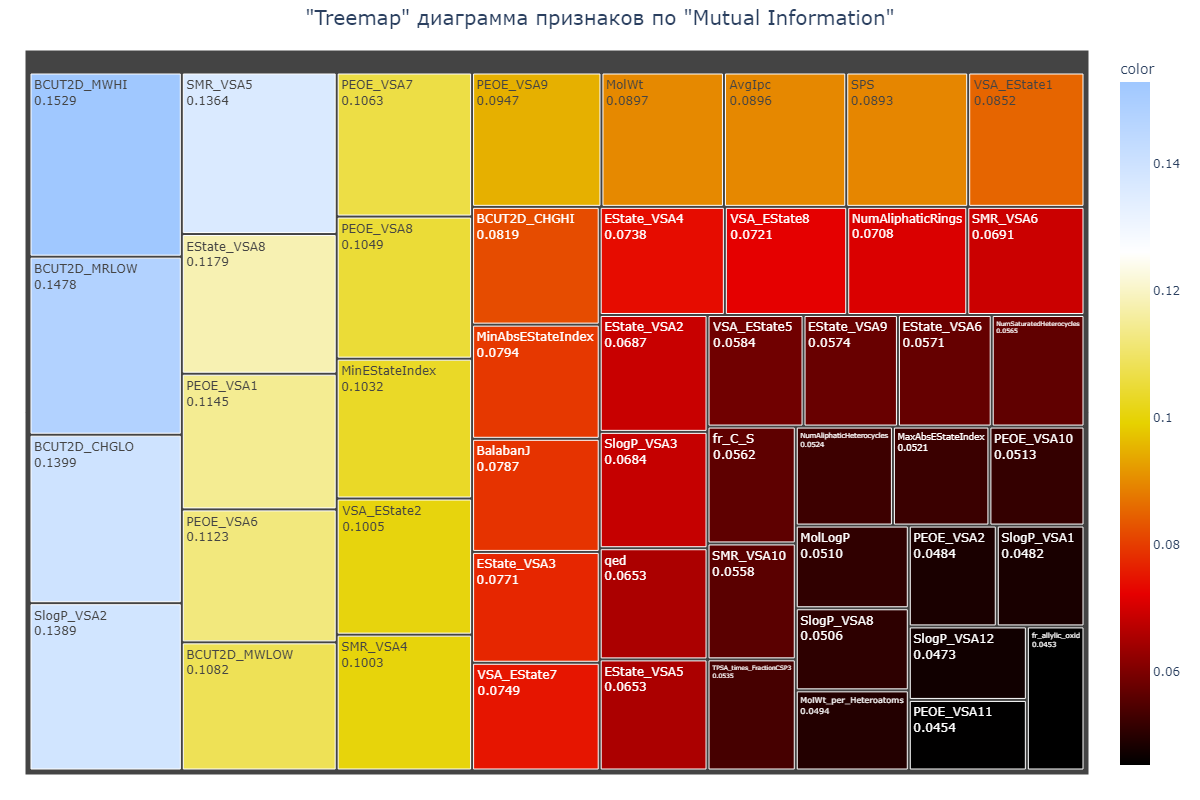

------------------------------------------------------------------------------------------------------------------------------------------------------

График кумулятивного вклада признаков (MI)
------------------------------------------------------------------------------------------------------------------------------------------------------


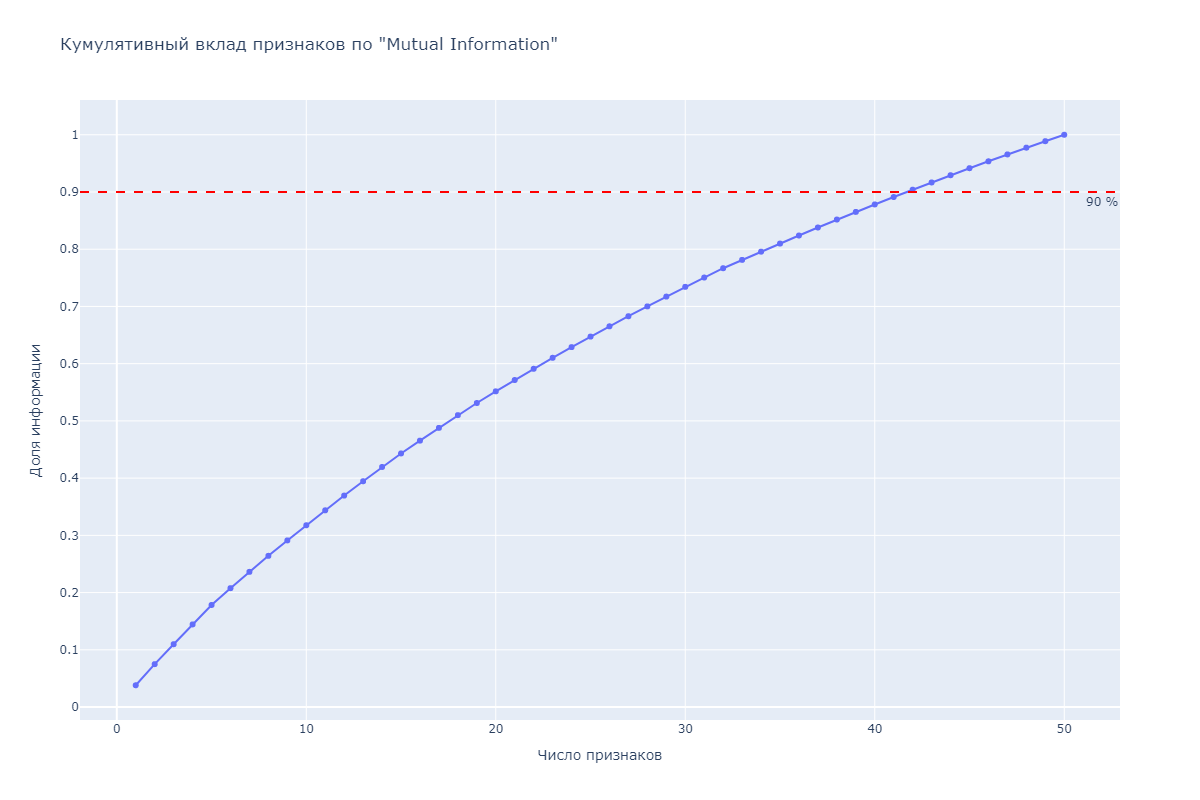

------------------------------------------------------------------------------------------------------------------------------------------------------


In [72]:
# Выбираем первые 50 признаков
mi_features = feature_selector.mi_selected_features
mi_scores = feature_selector.mi_scores[mi_features].sort_values(ascending = False)


# Выводим результат
print(f'\nТоп-50 признаков по "Mutual Information":\n\n{feature_selector.mi_scores.head(50)}')
print('-' * 40)
print('\n\n')




# Посторим график оценки важности признаков при помощи функции 'treemap_features'
treemap_features(
    data = mi_scores,
    title = '"Treemap" диаграмма признаков по "Mutual Information"',
    main_title = '"Treemap" диаграмма признаков по "Mutual Information":',
    color = px.colors.sequential.Blackbody
)


# Построим кумулятивную линию при помощи функции 'cum_line'
cum_line(
    data = mi_scores,
    main_title = 'График кумулятивного вклада признаков (MI)',
    title = 'Кумулятивный вклад признаков по "Mutual Information"'
)

Выводим $50$ признаков, отобранных методом `F-test`:


Топ-50 признаков по "F-test":

NumSaturatedHeterocycles    53.623912
fr_NH2                      45.565345
NumAliphaticHeterocycles    45.354902
PEOE_VSA7                   41.003074
PEOE_VSA9                   28.573123
VSA_EState4                 27.487946
fr_Ar_OH                    25.279515
fr_allylic_oxid             25.248503
NumAromaticHeterocycles     22.698468
BCUT2D_CHGLO                22.325853
SMR_VSA4                    22.004148
PEOE_VSA4                   21.419145
SMR_VSA5                    21.391318
SMR_VSA6                    20.092218
AvgIpc                      19.245821
VSA_EState1                 18.388235
EState_VSA3                 18.089411
fr_C_S                      17.104784
FpDensityMorgan1            16.815654
PEOE_VSA8                   16.557255
MinEStateIndex              15.451559
BCUT2D_MWLOW                15.207506
fr_sulfide                  14.996502
fr_Ar_N                     14.670603
fr_ketone_Topliss           13.971818
SMR_VSA3          

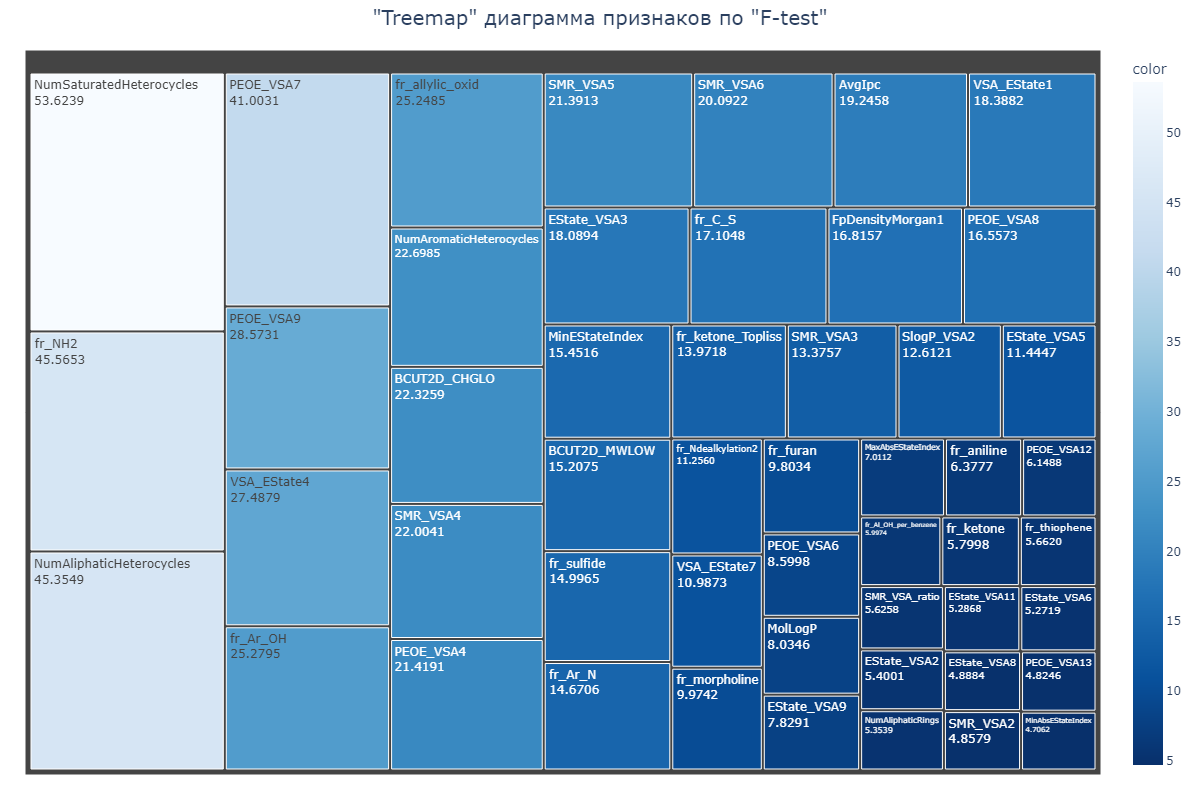

------------------------------------------------------------------------------------------------------------------------------------------------------

График кумулятивного вклада признаков (F-test)
------------------------------------------------------------------------------------------------------------------------------------------------------


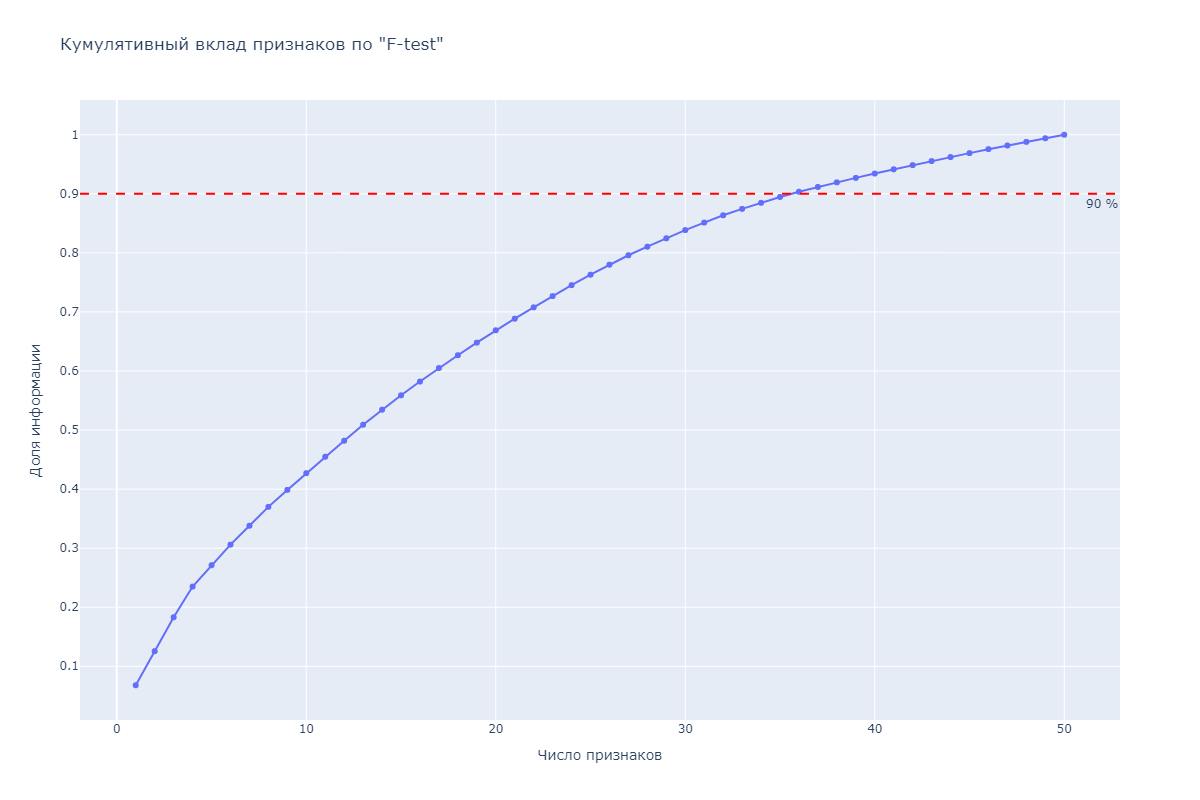

------------------------------------------------------------------------------------------------------------------------------------------------------


In [74]:
# Выбираем первые 50 признаков
f_features = feature_selector.f_selected_features
f_scores = feature_selector.f_scores[f_features].sort_values(ascending = False)


# Выводим результат
print(f'\nТоп-50 признаков по "F-test":\n\n{feature_selector.f_scores.head(50)}')
print('-' * 40)
print('\n\n')




# Посторим график оценки важности признаков при помощи функции 'treemap_features'
treemap_features(
    data = f_scores,
    title = '"Treemap" диаграмма признаков по "F-test"',
    main_title = '"Treemap" диаграмма признаков по "F-test":',
    color = px.colors.sequential.Blues_r
)


# Построим кумулятивную линию при помощи функции 'cum_line'
cum_line(
    data = f_scores,
    main_title = 'График кумулятивного вклада признаков (F-test)',
    title = 'Кумулятивный вклад признаков по "F-test"'
)

**Вывод:**

По алгоритму `F-test` самое оптимальное количество признаков достигает $35$.

Выводим финальные $30$ признаков, отобранных методом `LogisticRegression`:


Топ-30 признаков по "LogisticRegression":

AvgIpc                      0.858101
VSA_EState1                 0.620910
SPS                         0.504856
VSA_EState5                 0.498231
SlogP_VSA3                  0.484352
NumSaturatedHeterocycles    0.459048
VSA_EState2                 0.417501
PEOE_VSA11                  0.408170
PEOE_VSA8                   0.400835
fr_allylic_oxid             0.359138
EState_VSA4                 0.354596
SlogP_VSA12                 0.348363
BCUT2D_CHGLO                0.338966
NumAliphaticRings           0.318596
fr_C_S                      0.299241
PEOE_VSA1                   0.281390
EState_VSA5                 0.254842
SMR_VSA10                   0.253753
PEOE_VSA6                   0.253747
SMR_VSA4                    0.251588
EState_VSA9                 0.231712
BCUT2D_MRLOW                0.221575
SlogP_VSA1                  0.201547
PEOE_VSA9                   0.185933
BCUT2D_MWHI                 0.184069
EState_VSA6                 0.1

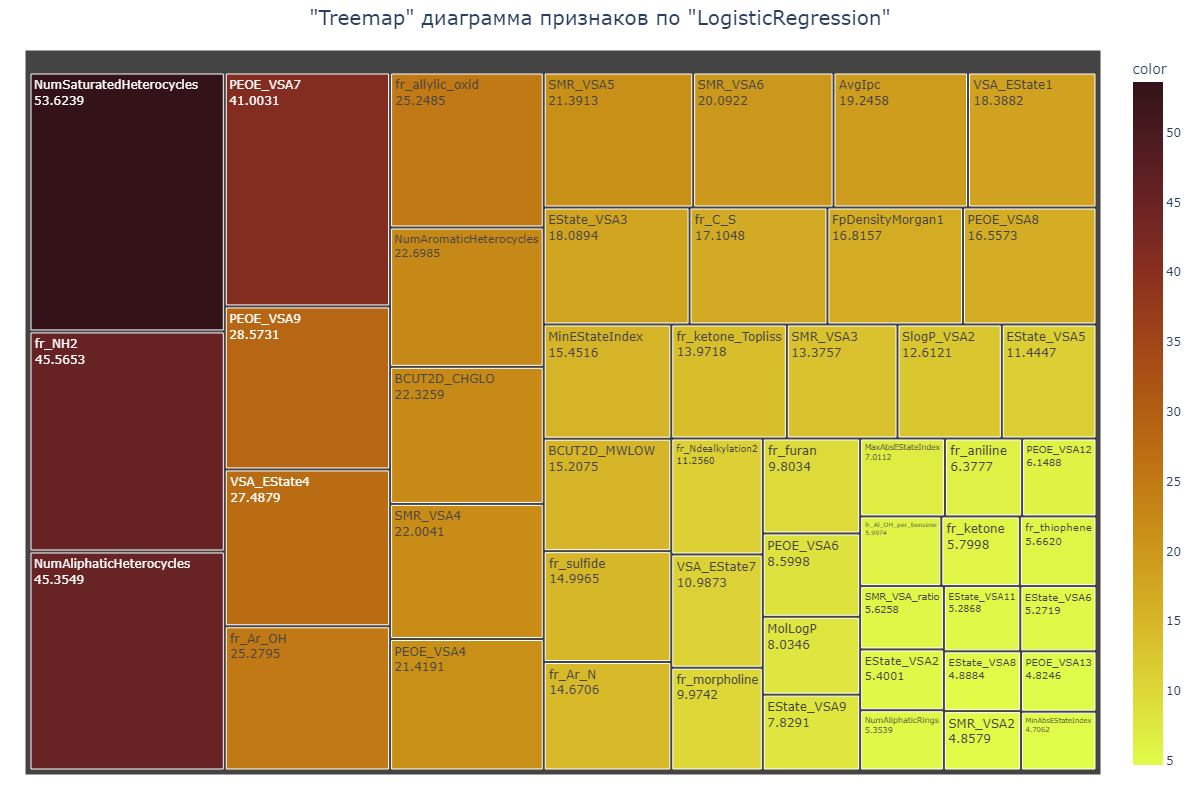

------------------------------------------------------------------------------------------------------------------------------------------------------

График кумулятивного вклада признаков (LogisticRegression)
------------------------------------------------------------------------------------------------------------------------------------------------------


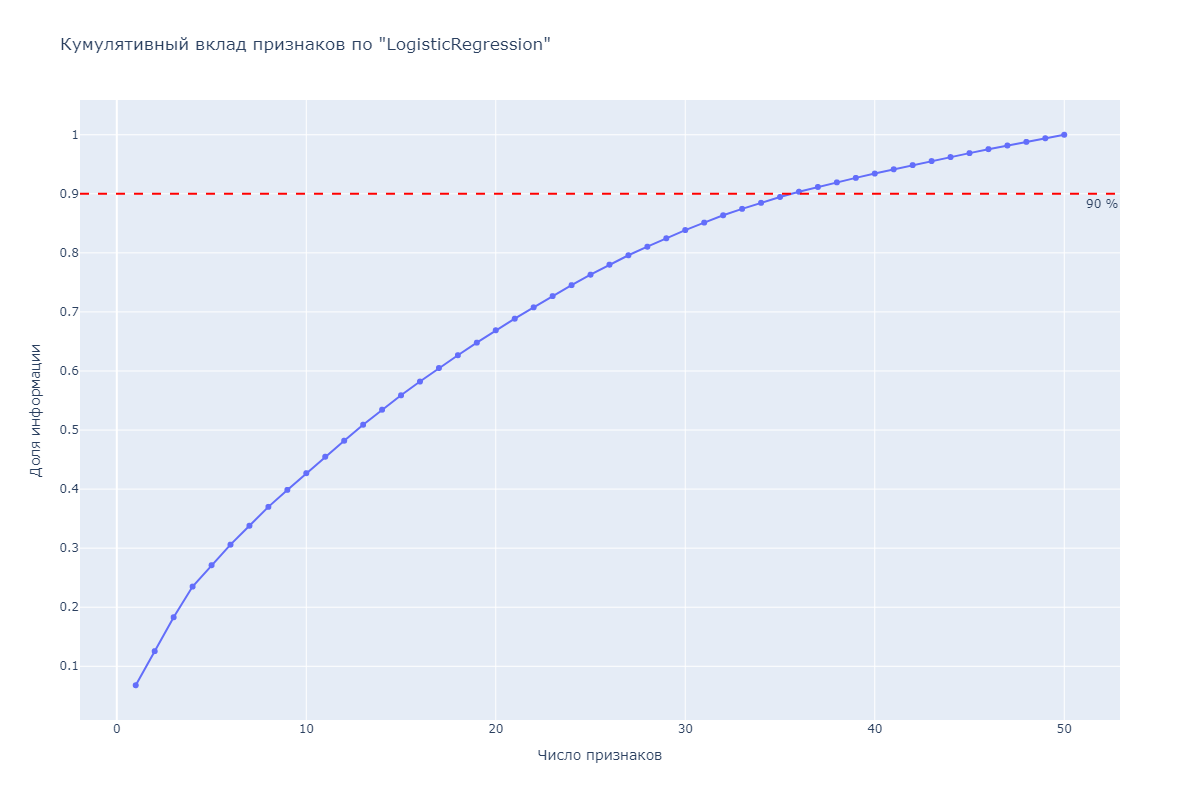

------------------------------------------------------------------------------------------------------------------------------------------------------


In [113]:
# Выбираем первые 30 признаков
log_features = feature_selector.final_features
log_scores = feature_selector.log_scores[log_features].sort_values(ascending = False)


# Выводим результат
print(f'\nТоп-30 признаков по "LogisticRegression":\n\n{log_scores.head(30)}')
print('-' * 40)
print('\n\n')




# Посторим график оценки важности признаков при помощи функции 'treemap_features'
treemap_features(
    data = f_scores,
    title = '"Treemap" диаграмма признаков по "LogisticRegression"',
    main_title = '"Treemap" диаграмма признаков по "LogisticRegression":',
    color = px.colors.sequential.solar_r
)


# Построим кумулятивную линию при помощи функции 'cum_line'
cum_line(
    data = f_scores,
    main_title = 'График кумулятивного вклада признаков (LogisticRegression)',
    title = 'Кумулятивный вклад признаков по "LogisticRegression"'
)

Проверим корреляцию отобранных признаков:


Тепловая карта корреляции отобранных признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


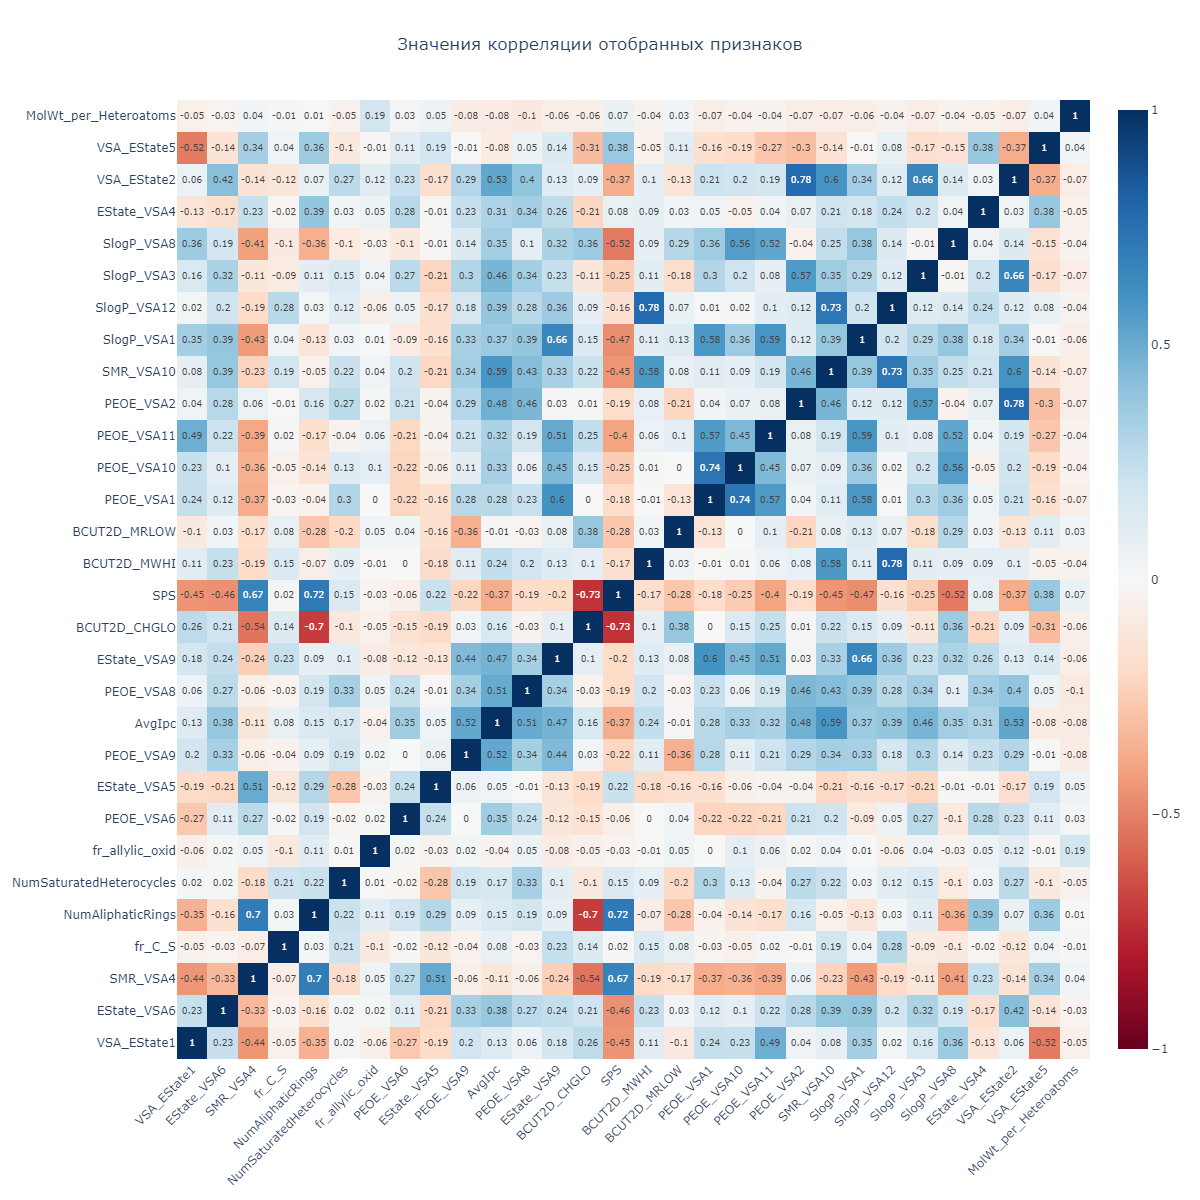

------------------------------------------------------------------------------------------------------------------------------------------------------


In [114]:
# Применяем функцию 'heatmap_corr()' для построения тепловой карты корреляции
heatmap_corr(data = X_train_final)

**Вывод:**

По тепловой карте видно, что значения корреляций признаков ещё чуть ниже, и не выходят за пределы $+-0.73$, а следовательно высококоррелированные связи отсутствуют.

#### $2.3$

#### **Machine Learning.**

Используем всё те же модели, что и для предсказания `IC50`: 

* **XGBoost (Extreme Gradient Boosting)**, 
* **LightGBM (Light Gradient Boosting Machine)**, 
* **Support Vector Machine (SVM) с ядром RBF**, 
* **RandomForestClassifier**, 
* **MLPClassifier**.

Создаём словарь, в котором ключами будут названия моделей, а значениями - словари с гиперпараметрами для подбора:

In [62]:
# Определяем модели и их гиперпараметры
ML_models = {
    
    # Определяем модель 'XGBoost'
    'XGBoost': {
        'model': XGBClassifier(random_state = 42),
        
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'scale_pos_weight': [1, sum(y_train == 0) / sum(y_train == 1)]
        }
        
    },
    
    
    
    # Определяем модель 'LightGBM'
    'LightGBM': {
        'model': LGBMClassifier(random_state = 42),
        
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [-1, 5, 10],
            'learning_rate': [0.01, 0.1, 0.3],
            'num_leaves': [31, 63, 127],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'class_weight': ['balanced', None]
        }
        
    },
    
    
    
    # Определяем модель опорных векторов
    'SVC': {
        'model': svm.SVC(random_state = 42, probability = True),
        
        'param_grid': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.1, 1],
            'class_weight': ['balanced', None]
        }
        
    },
    
    
    
    # Определяем модель случайного леса
    'RandomForest': {
        'model': ensemble.RandomForestClassifier(random_state = 42),
        
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': ['balanced', 'balanced_subsample', None]
        }
        
    },
    
    
    
    # Определяем модель нейронной сети для классификации
    'MLPClassifier': {
        'model': neural_network.MLPClassifier(random_state = 42),
        
        'param_grid': {
            'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
            'activation': ['relu', 'tanh'],
            'learning_rate_init': [0.001, 0.01],
            'alpha': [0.0001, 0.001, 0.01], 
            'max_iter': [200, 500]
        }
        
    }
    
}

Теперь создадим функцию, которая будет использоваться для обучения и оценки моделей:

In [63]:
# Создаём функцию 'train_model' для обучения и оценки модели
def train_model(model_name, config, X_train, X_test, y_train, y_test):
    
    # Выводим обучаемую модель
    print(f'\n\n\nОбучение модели: {model_name}')
    
    
    
    # Перебор гиперпараметров с использованием алгоритма 'GridSearchCV'
    # если гиперпараметры заданы
    if config['param_grid']:
        
        # Инициализируем класс 'GridSearchCV' с заданными гиперпараметрами
        grid_search = model_selection.GridSearchCV(
            estimator = config['model'],
            param_grid = config['param_grid'],
            cv = 3,
            verbose = 2,
            n_jobs = -1
        )
        
        # Обучаем наш класс
        grid_search.fit(X_train, y_train)
        
        # Сохраняем лучшие гиперпараметры
        best_model = grid_search.best_estimator_
        
        # Выводим результат
        print(f'Лучшие параметры для {model_name}: {grid_search.best_params_}')
        print('-' * 80)
        print('\n\n')
    
    
    # если гиперпараметры не заданы    
    else:
        
        # Оставляем стандартные параметры
        best_model = config['model']
        best_model.fit(X_train, y_train)
        
        
        
    # Делаем предсказание
    y_predict = best_model.predict(X_test)
    
    # Вызываем 'print_metrics' для вывода и получения метрик
    metrics_result = print_metrics(
        y_test,
        y_predict = y_predict,
        model_name = model_name,
        decimal_places = 3
    )
    
    
    
    # Возвращаем результат
    return metrics_result

Обучаем моделей и строим предсказания:

In [87]:
# Создаём словарь, в котором будем хранить наши предсказания
results = {}


# Создём цикл по созданному ранее словарю с моделями
# и обучаем их при помощи функции 'train_model'
for name, config in ML_models.items():
    
    # Заносим в словарь 'results' модели и метрики
    results[name] = train_model(
        name,
        config = config,
        X_train = X_train_final,
        X_test = X_test_final,
        y_train = y_train,
        y_test = y_test
    )




Обучение модели: XGBoost
Fitting 3 folds for each of 486 candidates, totalling 1458 fits


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning:

invalid value encountered in cast



Лучшие параметры для XGBoost: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
--------------------------------------------------------------------------------



XGBoost (значения метрик):

Accuracy: 0.707
--------------------------------------------------------------------------------
Precision: 0.715
--------------------------------------------------------------------------------
Recall: 0.707
--------------------------------------------------------------------------------
F1-score: 0.707
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.76      0.66      0.71        98
           1       0.66      0.76      0.70        83

    accuracy                           0.71       181
   macro avg       0.71      0.71      0.71       181
weighted avg       0.71      0.71      0.71     

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



#### $2.4$

#### **Определяем лучшую модель.**

Составим таблицу (**DataFrame**) со следующими столбцами:

Наименование модели:

* `model_name`,

Метрики и их значения:

* `Accuracy`,

* `Precision`,

* `Recall`,

* `F1-score`.

In [120]:
# Создаём DataFrame
model_metrics = {
    'XGBClassifier'             : {'Accuracy': 0.707, 'Precision': 0.715, 'Recall': 0.707, 'F1-score': 0.707},
    'LGBMClassifier'            : {'Accuracy': 0.713, 'Precision': 0.720, 'Recall': 0.713, 'F1-score': 0.713},
    'RandomForestClassifier'    : {'Accuracy': 0.702, 'Precision': 0.705, 'Recall': 0.702, 'F1-score': 0.702},
    'SupportVectorClassifier'   : {'Accuracy': 0.746, 'Precision': 0.751, 'Recall': 0.746, 'F1-score': 0.746},
    'MLPClassifier'             : {'Accuracy': 0.724, 'Precision': 0.728, 'Recall': 0.724, 'F1-score': 0.724}
}

metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.reset_index().rename(columns = {'index': 'model_name'})

**Визуализация метрик.**

Теперь построим графики по каждой метрике, чтобы сравнить их друг с другом визуально.


Данные таблицы "metrics_df" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 5.
-----------------------------------


,model_name,Accuracy,Precision,Recall,F1-score
0,XGBClassifier,0.707,0.715,0.707,0.707
1,LGBMClassifier,0.713,0.720,0.713,0.713
2,RandomForestClassifier,0.702,0.705,0.702,0.702
3,SupportVectorClassifier,0.746,0.751,0.746,0.746
4,MLPClassifier,0.724,0.728,0.724,0.724


------------------------------------------------------------




Столбчатая диаграмма сравнения метрик моделей классификации ("CC50"):
------------------------------------------------------------------------------------------------------------------------------------------------------


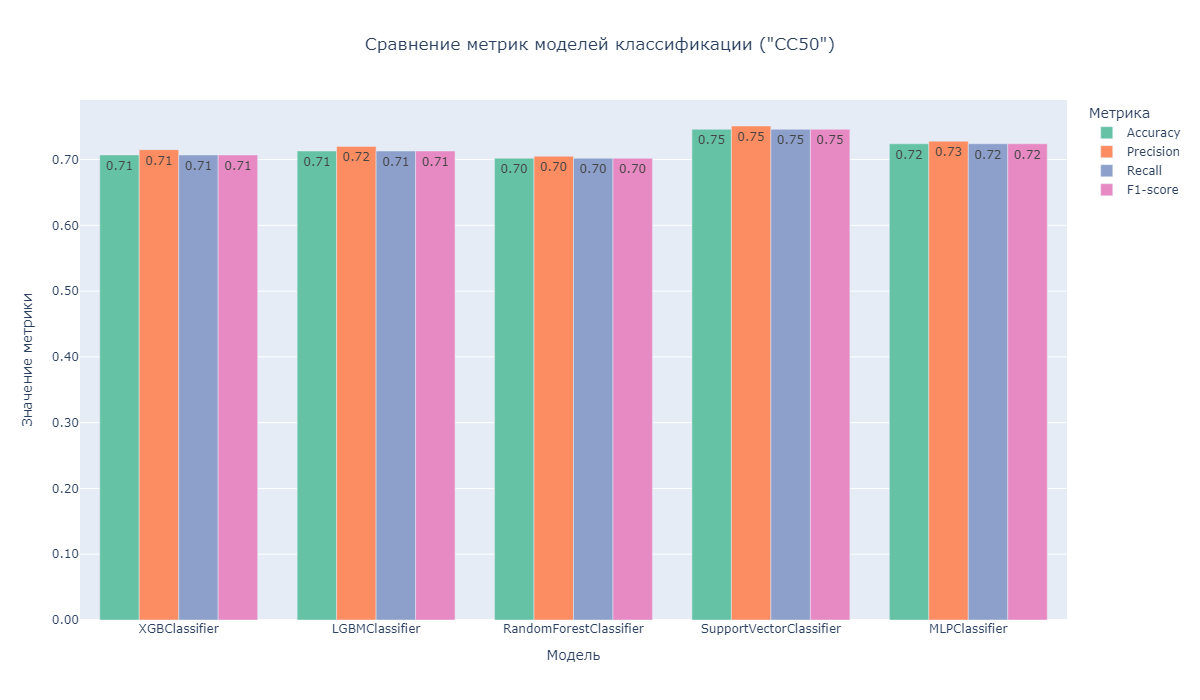

------------------------------------------------------------------------------------------------------------------------------------------------------


In [131]:
# Выводим результат
check_data_inf(
    data = metrics_df,
    data_name = 'metrics_df',
    length1 = 35,
    length2 = 60
)
print('\n\n')


# Применяем функцию 'metrics_bar_plot()' для построения столбчатого графика метрик
metrics_bar_plot(
    data = metrics_df,
    main_title = 'Столбчатая диаграмма сравнения метрик моделей классификации ("CC50"):',
    title = 'Сравнение метрик моделей классификации ("CC50")',
    colors = px.colors.qualitative.Set2
)

#### $2.5$

#### **Вывод.**

На данном этапе сделаем вывод итоговым метрикам и моделям, обученным для предсказания целевой переменной `CC50, mM`.

=============================================================================================================================================

## <CENTER> **`3.` Machine Learning (превышает ли значение SI медианное значение выборки)**

На данном этапе мы построим несколько подходящих моделей классификации для **SI** и выберем наилучшую.

#### $3.1$

#### **Предобработка данных.**

Как и раньше, предобработаем данные при помощи созданного ранее пайплайна, только все этапы по предобработке, созданию и удалению признаков включим в отдельный класс.

Повторно загружаем пайплайн:

In [31]:
# Загружаем пайплайн при помощи joblib
preprocessing_pipeline = joblib.load('data/preprocessing_pipeline.joblib')
print("Пайплайн загружен из 'preprocessing_pipeline.joblib'")

Пайплайн загружен из 'preprocessing_pipeline.joblib'


Создаём целевую переменную:


Медианное значение SI: 1.5113188221114595
---------------------------------------------



Уникальные значения признака "SI_classif":



SI_classif
1    452
0    452
Name: count, dtype: int64

---------------------------------------------


Стобчатая и круговая диаграммы распределения целевой переменной "SI_classif":
------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_14216\4276034505.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\User\AppData\Local\Temp\ipykernel_14216\4276034505.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


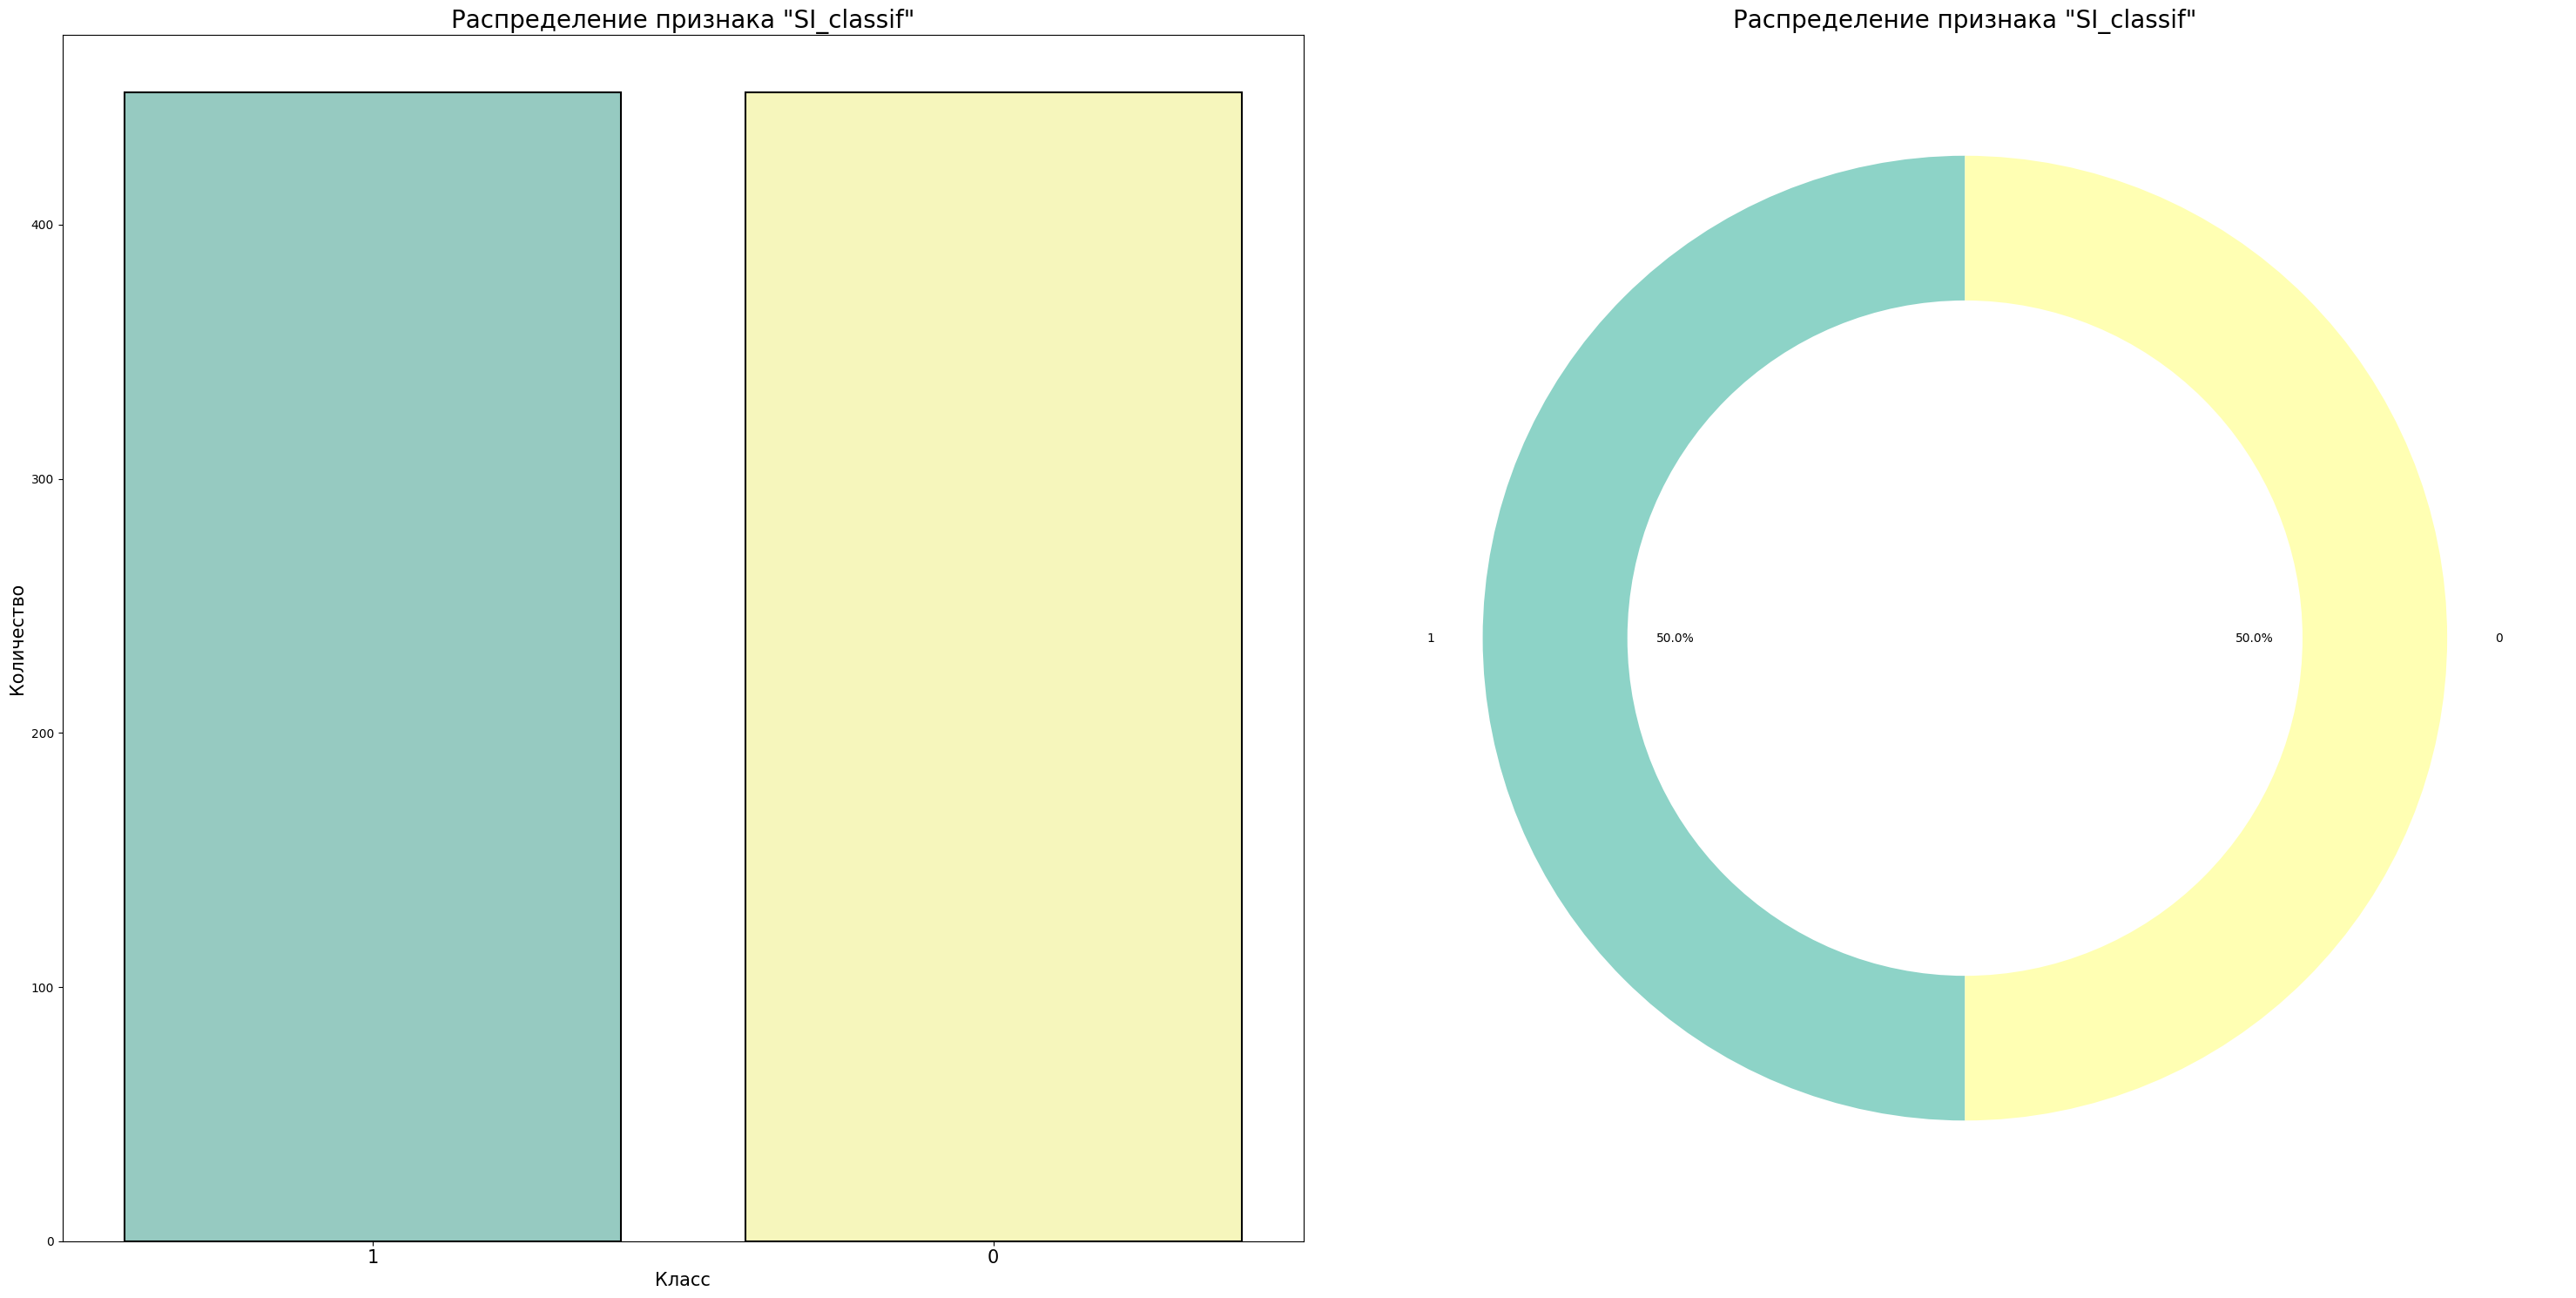

------------------------------------------------------------------------------------------------------------------------------------------------------


Распределение целевой переменной "log_SI"
------------------------------------------------------------------------------------------------------------------------------------------------------


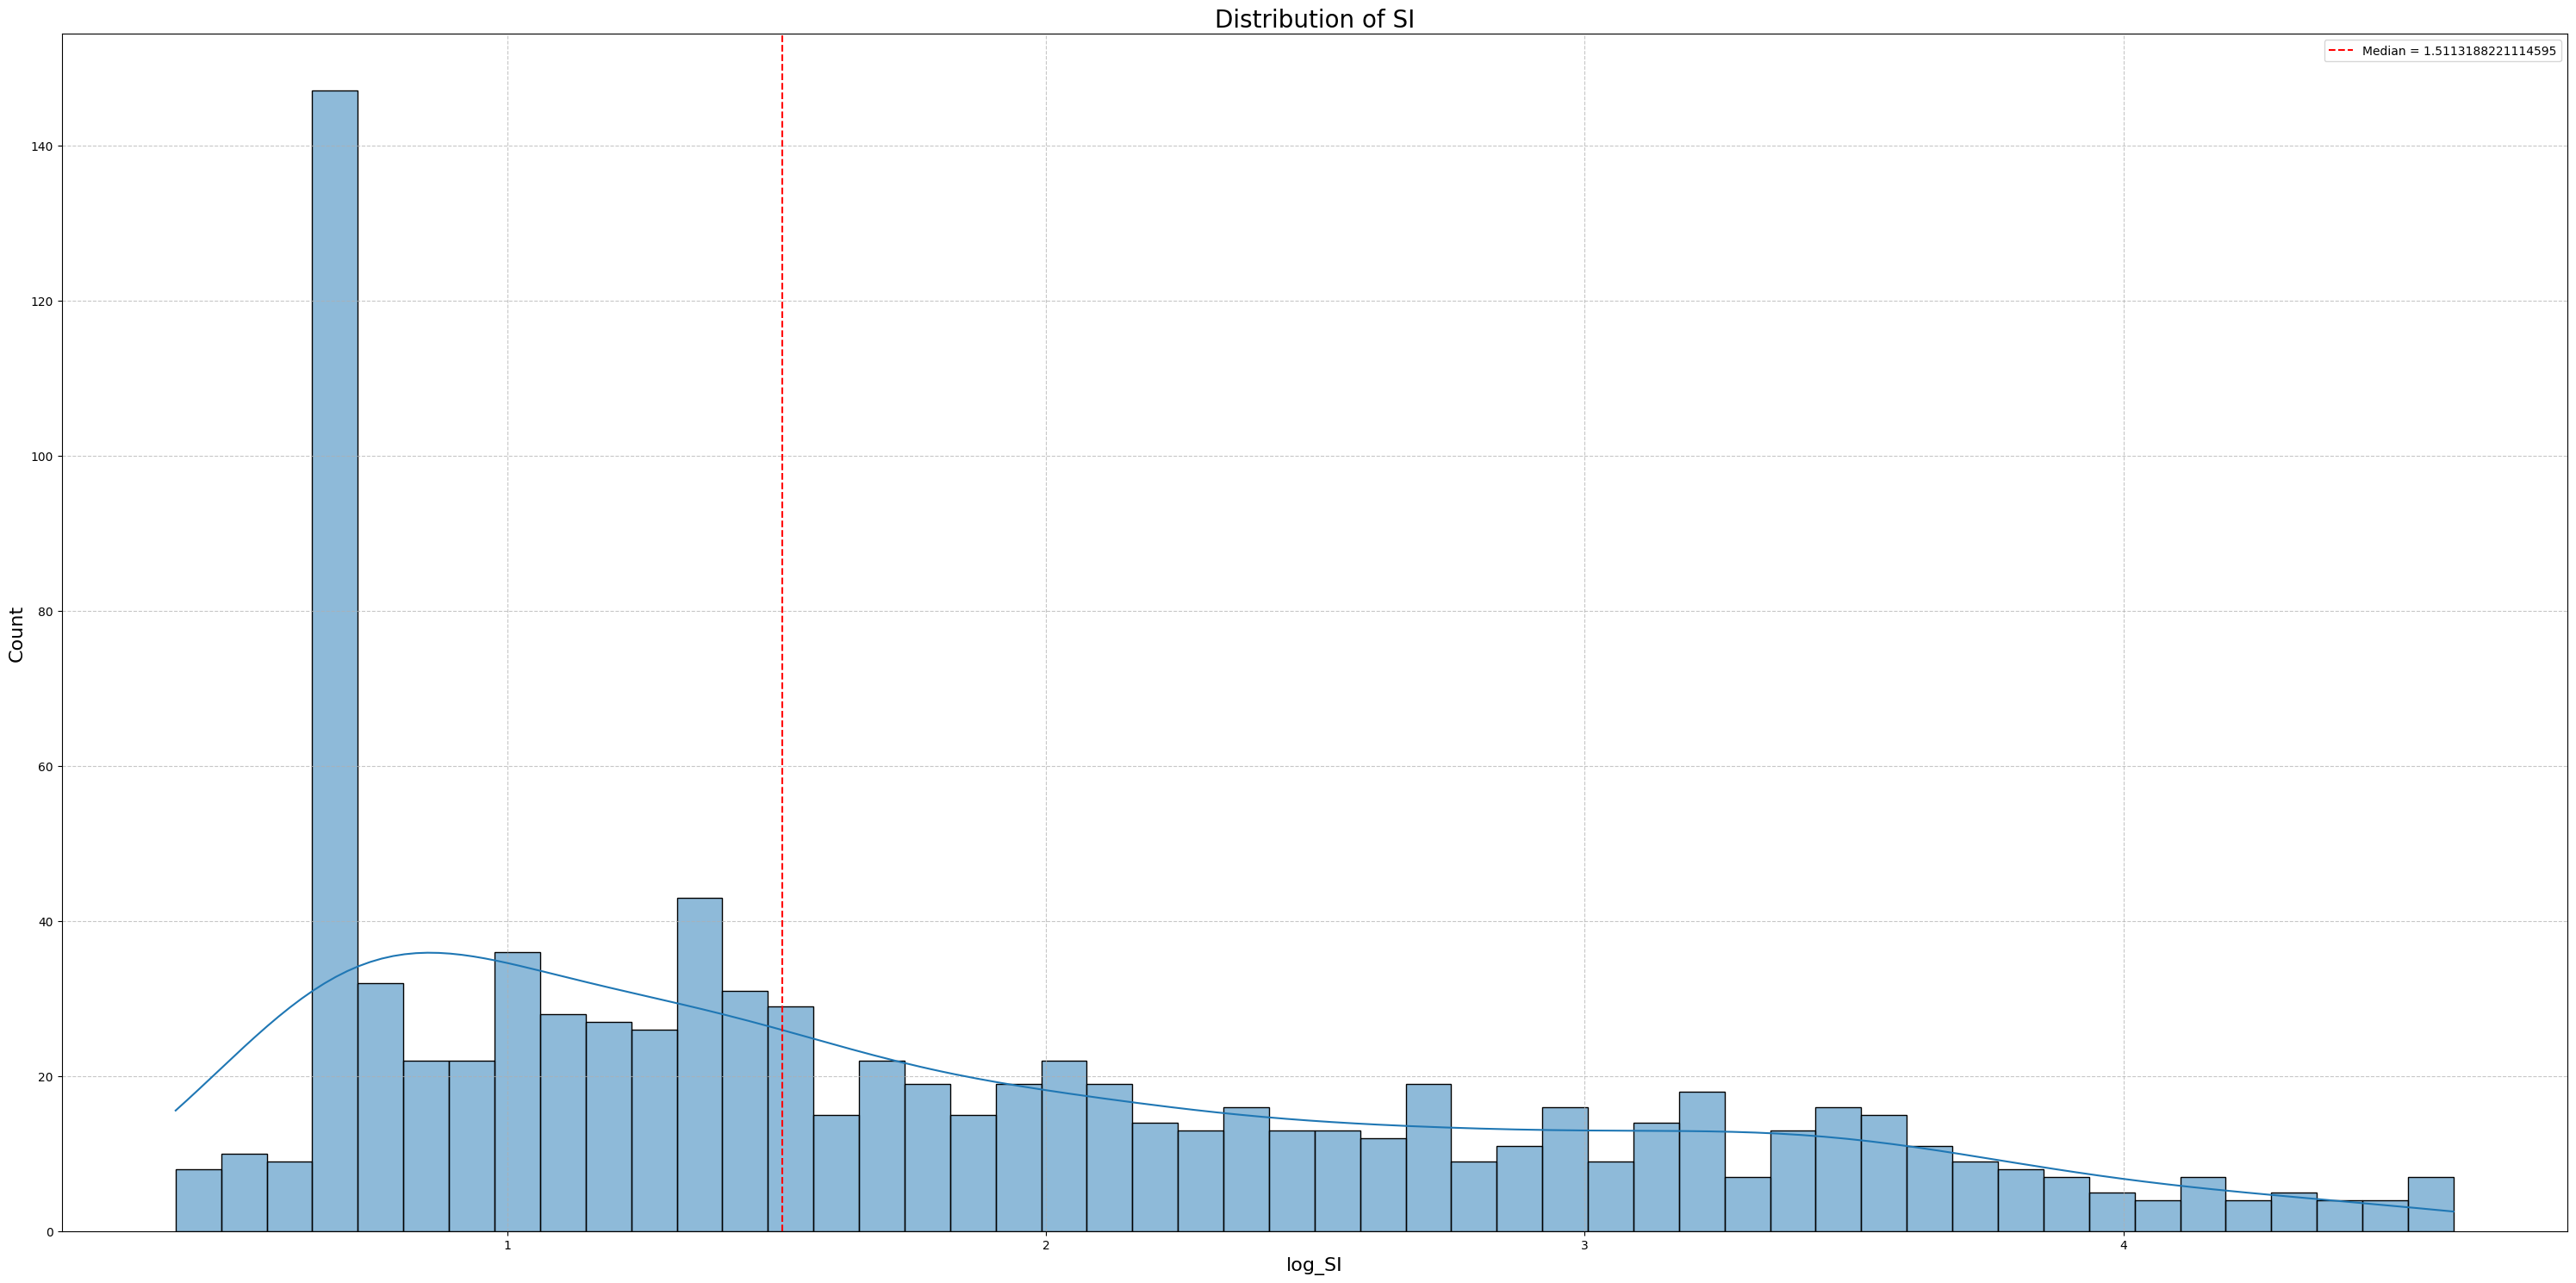

------------------------------------------------------------------------------------------------------------------------------------------------------


In [33]:
# Вычисляем медиану SI
median_si = molecule_df['log_SI'].median()
print(f'\nМедианное значение SI: {median_si}')
print('-' * 45)
print('\n\n')


# Создаем целевую переменную (1 - превышает, 0 - не превышает)
molecule_df['SI_classif'] = (molecule_df['log_SI'] > median_si).astype(int)
print('Уникальные значения признака "SI_classif":\n')
display(molecule_df['SI_classif'].value_counts())
print('-' * 45)




# Применяем функцию 'median_target_distribution_plot()' для построения графика распределения целевой переменной
median_target_distribution_plot(
    target = molecule_df['SI_classif'],
    title1 = 'Распределение признака "SI_classif"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной "SI_classif":',
    color_palette = 'Set3',
    figsize = (30, 15)
)

# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    data = molecule_df,
    target = 'log_SI',
    median_target = median_si,
    title = 'Distribution of SI',
    main_title = 'Распределение целевой переменной "log_SI"',
    figsize = (30, 15)
)

**Вывод:**

Как видно по графику, распределение целевой переменной - равномерное, следовательно балансировка не требуется.

**Разделение данных.**

Разделим данные на тматрицу наблюдений и вектор правильных ответов:

In [ ]:
# Разделяем данные на матрицу наблюдений и вектор правильных ответов
X = molecule_df.drop(columns = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI', 'IC50_classif', 'CC50_classif', 'SI_classif'])
y = molecule_df['SI_classif']

Применим созданный ранее класс к данным:

In [35]:
# Создаём экземпляра класса 'DataPreprocessor'
DP_processor = DataPreprocessor(preprocessing_pipeline)

# Обработка данных
DP_processor.fit_transform(X, y)

# Получение обработанных данных
X_train_processed_df, X_test_processed_df, y_train, y_test, remaining_features = DP_processor.get_processed_data()


Данные таблицы "Molecular properties features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
------------------------------------------------------------




Данные таблицы "Functional groups features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 8.
----------------------------------------
------------------------------------------------------------------------------------------




Данные таблицы "Topological descriptors features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 4.
----------------------------------------
--------------------------------------------------------------------------------




Данные таблицы "Transformations features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
---------------------------------------------------

Выводим результат:

In [36]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_processed_df,
    data_name = 'X_train_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_processed_df,
    data_name = 'X_test_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по оставшимся признакам
print(f'Оставшиеся признаки:\n\n{remaining_features.tolist()}')
print('-' * 150)


Данные таблицы "X_train_processed_df" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 103.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_quatN,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,-1.496602,0.422613,0.771519,0.579771,-0.081941,-0.172284,-0.720975,-0.482466,-0.231601,0.709602,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064531,-0.017568,-0.338656,-0.806000,-0.332149
1,0.527403,0.904784,-0.394927,0.514586,-0.554818,-0.694608,-0.970049,-0.465835,0.425592,0.670103,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064565,0.133615,-0.338656,-0.806000,-0.857136
2,0.252959,-0.894628,0.392277,0.397569,0.511590,-0.034503,1.347721,0.555049,-0.313054,0.077316,...,-0.174679,-0.210093,-0.266667,3.294307,-0.177731,-0.064578,0.146636,-0.338656,0.736551,1.215385
3,-1.210453,0.216033,0.750903,0.746949,1.699045,-1.145565,-0.554926,-0.589790,-0.967502,0.838770,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064458,-0.019390,-0.338656,-0.806000,-0.065901
4,0.694610,-0.824197,0.472459,1.392750,-0.120265,-0.264281,0.954612,0.555048,-0.403346,-0.483621,...,-0.174679,-0.210093,3.750000,-0.303554,-0.177731,-0.064567,0.009951,-0.338656,0.207477,-0.043975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.251380,0.324610,0.428609,-0.563375,-0.001549,-0.241286,0.655849,-0.479027,-0.231089,0.700544,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064533,-0.010548,-0.338656,0.211154,-0.300668
719,-1.577604,1.146384,0.843749,0.769183,0.451116,-0.010688,0.083725,-0.482669,-0.749877,0.230117,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064481,-0.085575,-0.338656,-0.300500,-0.744117
720,0.439661,-0.198519,0.198692,0.502574,-0.661393,0.463493,-0.416552,0.557248,0.434471,-0.335264,...,-0.174679,3.494726,-0.266667,-0.303554,-0.177731,-0.064571,0.086950,-0.338656,-0.806000,-0.622234
721,0.980138,-0.326590,-0.499596,-0.363831,-1.475648,0.285924,-0.703184,-0.304289,0.607120,-1.303146,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064583,0.134657,-0.338656,-0.806000,-0.643005


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_processed_df" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 103.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_quatN,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,0.160756,-0.510352,-0.302029,-0.353559,-1.315644,-0.863532,1.780140,0.559264,2.296748,-1.732256,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064599,-1.198955,-0.338656,0.168554,-0.016665
1,0.552605,-0.468304,-2.184035,-1.056662,-1.369489,-0.089109,0.528003,0.552297,1.154219,-0.893501,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064590,0.128426,-0.338656,1.068112,-0.717143
2,-0.045459,-1.061101,0.108325,0.426638,0.811860,-0.471906,1.224172,-0.471246,-0.265352,0.017607,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064578,0.213022,1.475033,1.241226,1.433804
3,0.464136,0.524951,-1.212053,-1.368374,-0.291834,0.854706,0.353155,0.492597,-0.231089,0.701536,...,-0.174679,-0.210093,-0.266667,-0.303554,0.788429,-0.064576,0.094904,-0.338656,1.152177,1.983047
4,-1.720945,1.330435,0.862116,-1.065667,0.899075,0.426860,-2.215418,-0.592477,-0.231368,0.760929,...,-0.174679,-0.210093,-0.266667,-0.303554,4.653068,-0.064459,-0.076881,-0.338656,-0.806000,-0.190647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-1.488398,1.708016,0.899797,0.058433,1.462212,-1.667184,0.690443,-0.603011,0.127272,-0.483112,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064510,0.065149,-0.338656,-0.806000,-0.065901
177,0.562094,0.446785,0.434776,0.703003,-1.149026,-0.103926,-0.554926,-0.504065,0.884829,-1.319795,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064572,0.100585,-0.338656,-0.806000,-0.833169
178,0.417928,0.379878,0.409685,-0.011909,-1.476949,-0.073419,-0.395263,-0.482662,1.260989,-2.026415,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064572,0.099420,-0.338656,-0.806000,-0.842731
179,0.044589,-0.244271,0.028994,1.031010,0.347881,0.057249,-0.075938,-0.478956,-0.226828,0.099772,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064570,0.247098,-0.338656,-0.806000,0.764520


------------------------------------------------------------------------------------------------------------------------------------------------------




Оставшиеся признаки:

['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA7', 'SlogP_VSA8', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState4', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NumAliphatic

По результатам видно, что данные, после применения класса, имеют схожую структуру, что и при прошлой предобработки.

Проверим распределение признаков при помощи визуализации:


График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


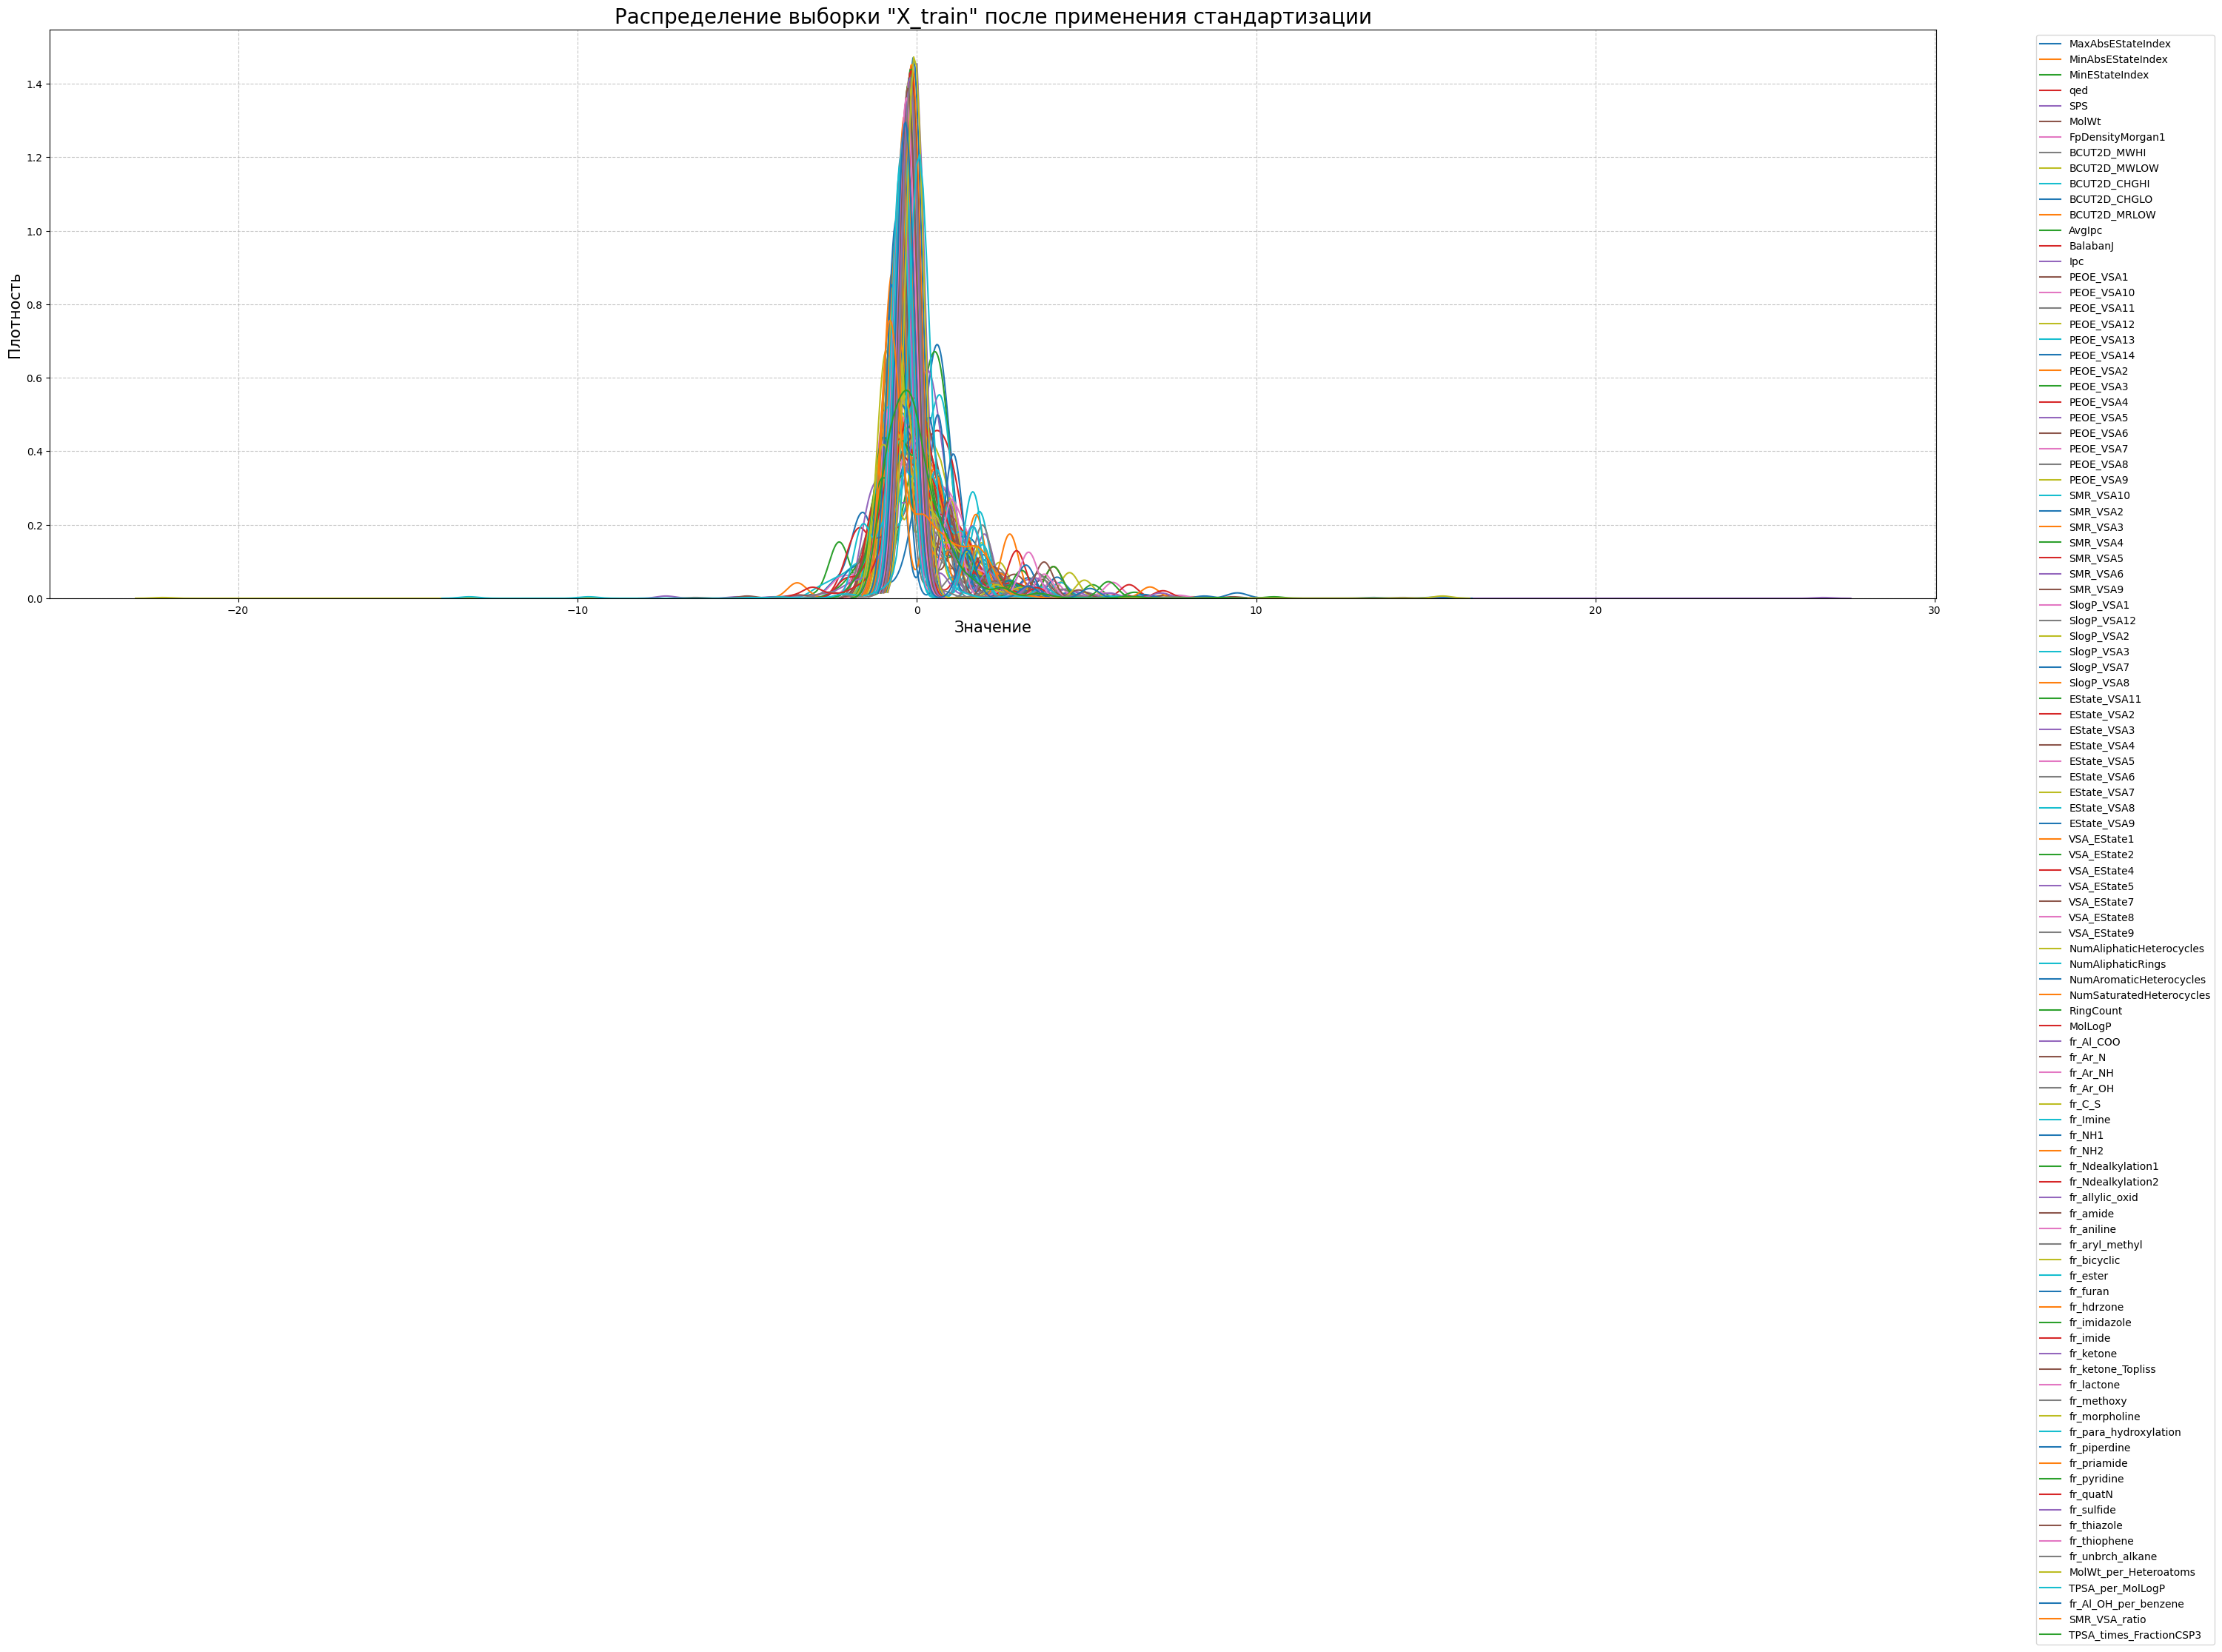

------------------------------------------------------------------------------------------------------------------------------------------------------



График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


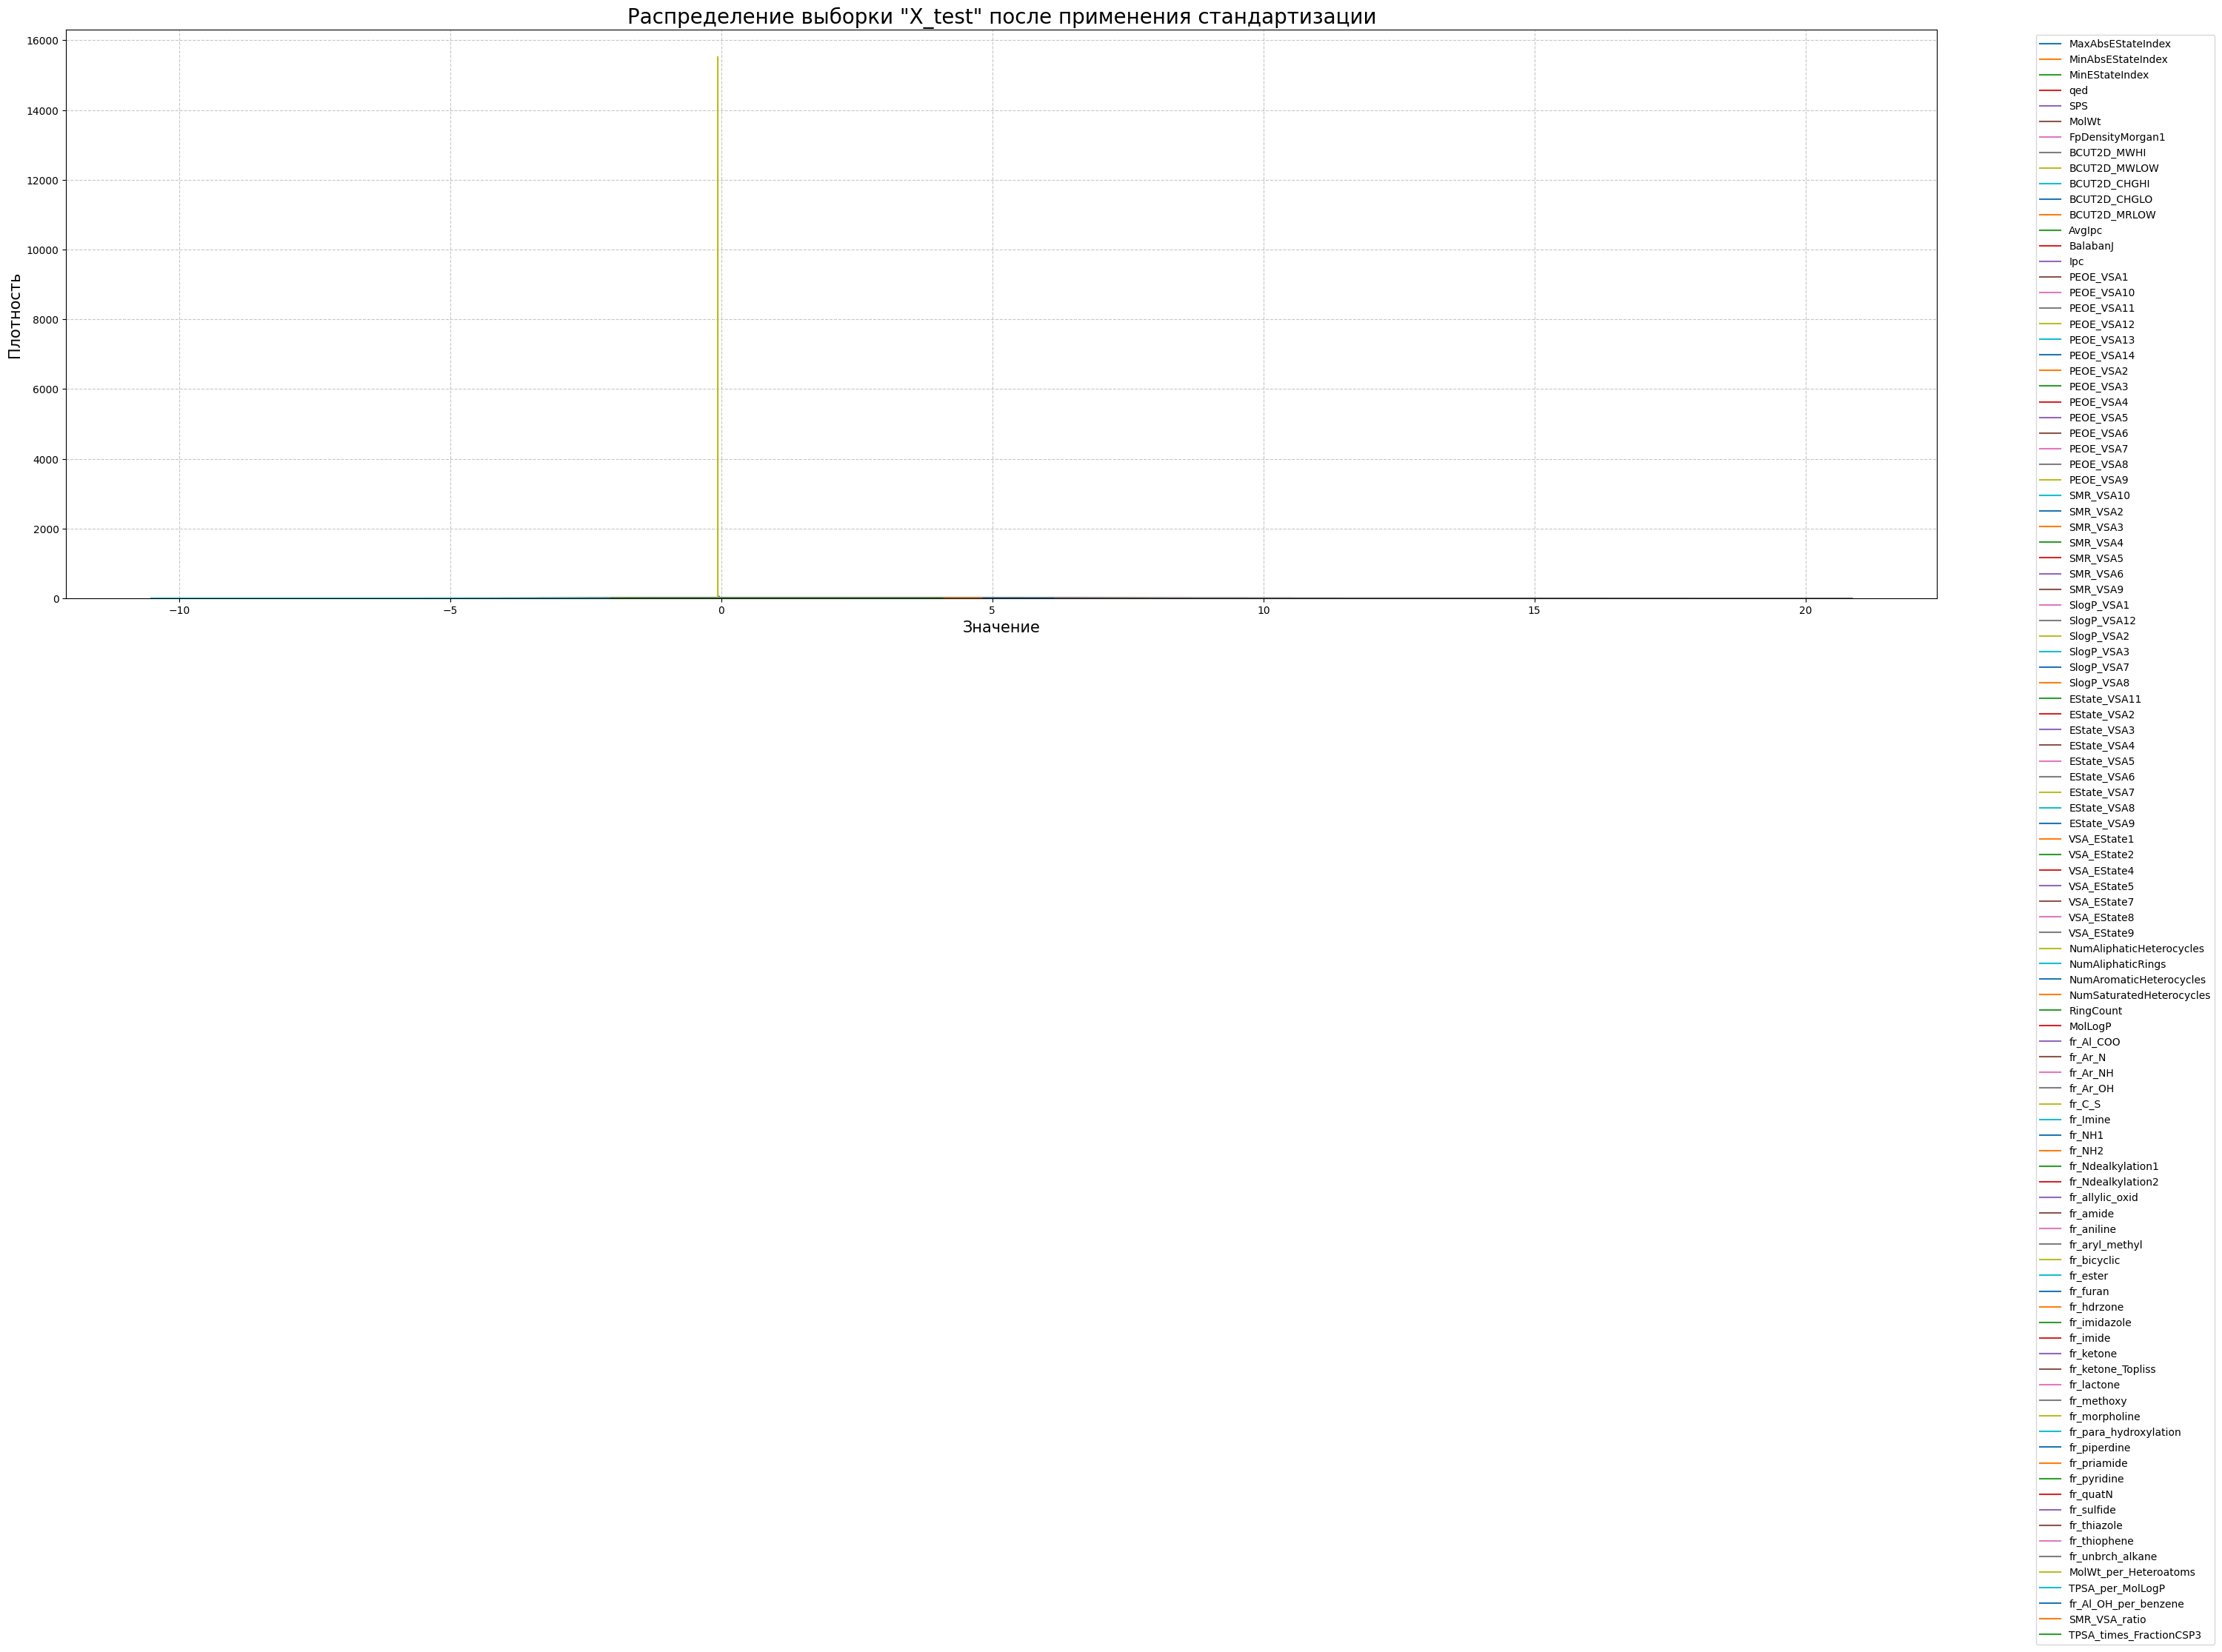

------------------------------------------------------------------------------------------------------------------------------------------------------


In [37]:
# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_train
print()
features_distribution_plot(
    data = X_train_processed_df,
    title = 'Распределение выборки "X_train" после применения стандартизации',
    figsize = (30, 17)
)

# Добавляем отступ
print('\n\n')



# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_test
features_distribution_plot(
    data = X_test_processed_df,
    title = 'Распределение выборки "X_test" после применения стандартизации',
    figsize = (30, 17)
)

**Вывод:**

Распределение признаков также нормализовалось.

#### $3.2$

#### **Отбор самых информативных признаков.**

На данном этапе отберём только самые информативные признаки для дальнейшего решения задачи регрессии.

Производить отбор признаков будем так же, как и для `CC50`, в $4$ этапа:

1. Отберём $50$ признаков с помощью алгоритма **Mutual Information**,
2. Отберём $50$ признаков с помощью алгоритма **F-test**,
3. Отберём $50$ признаков из отобранных обоими алгоритмами,
4. Из оставшихся отберём $30$ признаков с помощью алгоритма **Lasso**.

Только сейчас, все этапы обернём в класс, чтобы использовать его в будущем.

Применим созданный ранее класс `FeatureSelector` к данным:

In [40]:
# Инициализируем класс 'FeatureSelector'         
feature_selector = FeatureSelector(
    mi_k = 50,
    f_k = 50,
    log_max_features = 30,
    penalty = 'l1',
    solver = 'liblinear',
    C = 1.0
)

# Обучаем класс на данных
feature_selector.fit_transform(X_train_processed_df, X_test_processed_df, y_train)

# Получение обработанных данных
X_train_final, X_test_final, final_features = feature_selector.get_final_data()

# Выводим результат
feature_selector.print_results()


Топ-30 финальных признаков после "LogisticRegression"

NumSaturatedHeterocycles    0.666825
SMR_VSA6                    0.537944
SPS                         0.532679
EState_VSA8                 0.332549
PEOE_VSA9                   0.328886
BCUT2D_CHGLO                0.287036
VSA_EState1                 0.270977
SlogP_VSA2                  0.270663
fr_NH2                      0.266540
PEOE_VSA7                   0.241119
EState_VSA9                 0.220171
BCUT2D_MWLOW                0.196075
SMR_VSA4                    0.192912
BalabanJ                    0.186072
SMR_VSA_ratio               0.175453
MinEStateIndex              0.173425
PEOE_VSA8                   0.162445
BCUT2D_MWHI                 0.159702
VSA_EState7                 0.156644
AvgIpc                      0.156070
VSA_EState8                 0.151664
FpDensityMorgan1            0.150474
TPSA_per_MolLogP            0.147798
PEOE_VSA6                   0.141528
VSA_EState9                 0.135228
SMR_VSA5           

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Выведем информацию итоговых выборок:

In [ ]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_final,
    data_name = 'X_train_final',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_final,
    data_name = 'X_test_final',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_final" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 30.
----------------------------------------


,SPS,NumSaturatedHeterocycles,SMR_VSA5,SMR_VSA_ratio,EState_VSA8,PEOE_VSA8,AvgIpc,fr_thiophene,BCUT2D_MWLOW,VSA_EState1,...,BCUT2D_CHGLO,BalabanJ,PEOE_VSA6,PEOE_VSA7,SMR_VSA6,SlogP_VSA2,EState_VSA3,EState_VSA9,VSA_EState9,MolLogP
0,-0.081941,-0.725093,-0.054649,-0.806000,0.006955,-0.021284,0.164660,-0.303554,-0.231601,-0.510177,...,0.065107,-0.654310,-0.283280,1.628333,-0.501151,-1.133018,-0.791905,0.703425,-0.375368,1.146289
1,-0.554818,-0.725093,-0.966737,-0.806000,-1.034783,-1.513317,0.122907,-0.303554,0.425592,-0.228040,...,0.892106,0.358409,-0.116601,-0.504015,-0.852100,-0.889025,0.381094,0.042850,-0.375368,-0.438833
2,0.511590,0.508418,0.752115,0.736551,-0.073639,1.658586,0.230686,3.294307,-0.313054,-0.483553,...,-0.995268,0.156603,-0.096764,-0.457205,-0.852100,-0.456006,0.092873,-0.479599,-0.375368,0.134020
3,1.699045,-0.725093,0.756481,-0.806000,-0.340291,-1.021808,-1.556033,-0.303554,-0.967502,-0.823985,...,-1.885697,0.473720,-0.613549,1.143588,-0.852100,-1.139996,-0.791905,-0.369657,-0.375368,-0.093992
4,-0.120265,-0.725093,0.149113,0.207477,0.523568,-0.932554,-0.219276,-0.303554,-0.403346,-0.068435,...,-0.577835,-0.202214,0.257495,0.270976,-0.126073,-0.445268,-1.164993,-1.002048,-0.375368,0.418298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,-0.001549,-0.725093,-0.054649,0.211154,0.006955,0.013202,0.137664,-0.303554,-0.231089,-0.542370,...,0.062237,-0.761391,1.163576,0.004357,-0.047108,-0.360715,0.114232,0.071034,-0.375368,0.467729
719,0.451116,0.508418,0.983472,-0.300500,1.512684,0.228973,-0.530440,-0.303554,-0.749877,-0.524807,...,-1.290042,-0.409259,1.221381,1.008224,1.158479,0.160940,-0.011078,-0.479599,-0.375368,0.759028
720,-0.661393,0.508418,-0.795632,-0.806000,0.753101,-0.943551,1.160541,-0.303554,0.434471,-0.541832,...,0.536522,-0.633789,1.040884,0.428075,-0.416920,0.023722,-0.722604,0.083057,0.585089,0.363998
721,-1.475648,-0.725093,-1.391050,-0.806000,-0.797215,-1.019632,-0.312350,-0.303554,0.607120,2.477075,...,1.400336,1.437318,-1.274086,-0.786662,0.453440,-0.261109,-0.350889,0.530036,1.857985,0.070264


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_final" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 30.
----------------------------------------


,SPS,NumSaturatedHeterocycles,SMR_VSA5,SMR_VSA_ratio,EState_VSA8,PEOE_VSA8,AvgIpc,fr_thiophene,BCUT2D_MWLOW,VSA_EState1,...,BCUT2D_CHGLO,BalabanJ,PEOE_VSA6,PEOE_VSA7,SMR_VSA6,SlogP_VSA2,EState_VSA3,EState_VSA9,VSA_EState9,MolLogP
0,-1.315644,-0.725093,-1.218918,0.168554,-0.017680,-0.958198,-0.523923,-0.303554,2.296748,-0.196948,...,2.808560,2.235256,-1.274086,-1.638111,-0.469194,0.259309,-0.853886,-1.002048,-1.252551,-2.374582
1,-1.369489,-0.725093,-0.953746,1.068112,0.271268,-1.008634,0.279302,-0.303554,1.154219,1.861870,...,1.717081,0.360574,-1.274086,0.323003,-0.526667,-0.514649,-0.773137,0.345513,-0.375368,-0.118334
2,0.811860,0.508418,0.523061,1.241226,-0.687537,-0.418413,0.033512,-0.303554,-0.265352,-0.215910,...,-0.808107,0.018830,-0.637539,-0.457205,-0.852100,-0.485835,0.082011,0.007587,-0.375368,-0.152599
3,-0.291834,-0.725093,1.275313,1.152177,0.524135,0.054797,1.105525,-0.303554,-0.231089,0.821808,...,0.061560,-1.083867,-0.034597,0.666848,1.138848,0.786383,2.355336,1.068921,-2.119567,0.747654
4,0.899075,-0.725093,2.567789,-0.806000,1.048692,1.622910,0.816310,-0.303554,-0.231368,-0.823985,...,0.059434,-1.655280,1.932642,1.404096,-0.050911,-0.373630,0.327360,0.099219,-0.375368,2.045792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,1.462212,-0.725093,-0.100876,-0.806000,-0.687537,-0.977181,-0.925508,-0.303554,0.127272,-0.823985,...,0.675382,0.469819,-0.967807,0.079415,-0.852100,-1.119683,-0.748715,-0.369657,-0.375368,-0.824418
177,-1.149026,-0.725093,-0.928795,-0.806000,-0.000715,-0.481319,0.523212,-0.303554,0.884829,-0.754509,...,1.409520,-0.366817,1.016894,-0.711178,-0.519996,-0.268689,0.021690,-1.002048,-0.375368,0.253629
178,-1.476949,-0.725093,-1.172573,-0.806000,-0.518169,-1.513317,1.059089,-0.303554,1.260989,-0.135080,...,1.493611,-0.570250,0.172770,-0.252574,-0.122270,-0.472495,0.150979,0.007587,-0.375368,0.201099
179,0.347881,0.508418,0.298145,-0.806000,-1.034783,-0.418413,-0.510611,-0.303554,-0.226828,0.380878,...,-0.836497,0.394740,-0.984255,0.061704,0.453440,0.629610,0.908194,1.087747,2.387364,-0.426204


------------------------------------------------------------------------------------------------------------------------------------------------------


**Построение визуализаций.**

Создадим функцию, для построения пузырьковых графиков отобранных признаков:


Топ-50 признаков по "Mutual Information":

BCUT2D_CHGHI                0.107559
SMR_VSA5                    0.099071
BCUT2D_CHGLO                0.095172
BCUT2D_MWLOW                0.084898
VSA_EState2                 0.081505
PEOE_VSA8                   0.076737
SlogP_VSA2                  0.076559
EState_VSA8                 0.075728
BCUT2D_MWHI                 0.074798
EState_VSA4                 0.074659
VSA_EState4                 0.074154
qed                         0.072352
BCUT2D_MRLOW                0.062848
SMR_VSA_ratio               0.062846
EState_VSA3                 0.060134
SMR_VSA10                   0.059163
MinEStateIndex              0.058219
MaxAbsEStateIndex           0.056799
PEOE_VSA7                   0.056284
VSA_EState9                 0.054405
EState_VSA2                 0.054146
PEOE_VSA10                  0.054104
VSA_EState8                 0.052987
TPSA_per_MolLogP            0.052521
MolWt_per_Heteroatoms       0.051689
VSA_EState5                 0.0

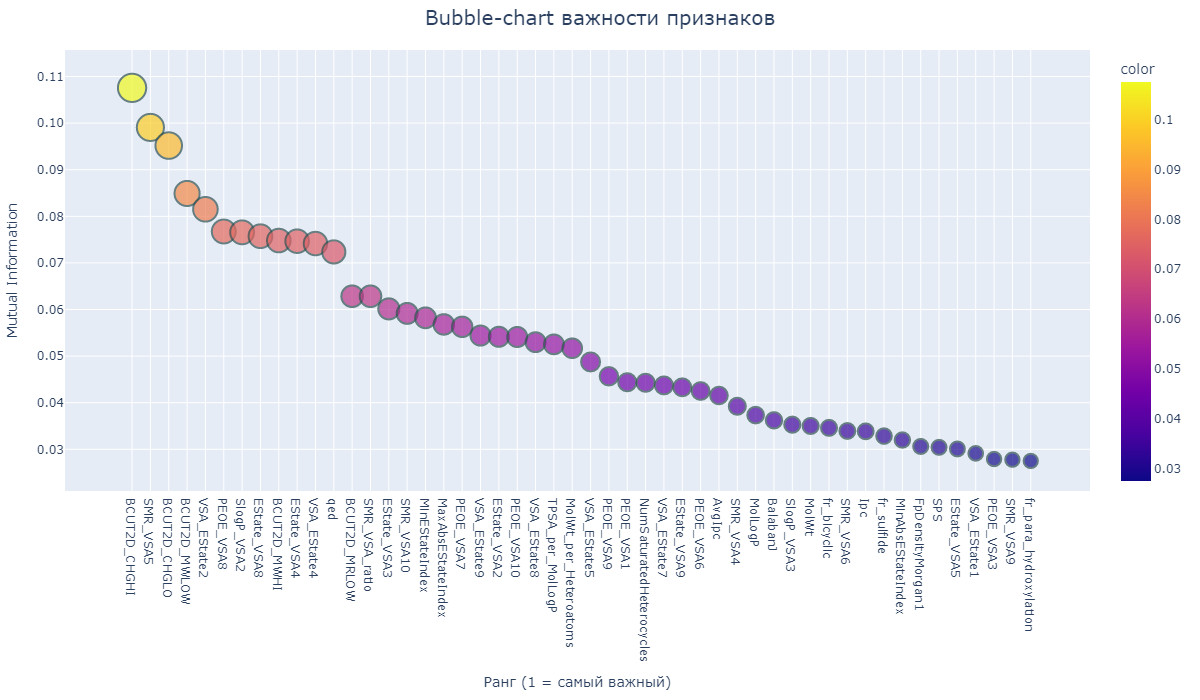

------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# Выбираем первые 50 признаков
mi_features = feature_selector.mi_selected_features
mi_scores = feature_selector.mi_scores[mi_features].sort_values(ascending = False)
# Выводим результат
print(f'\nТоп-50 признаков по "Mutual Information":\n\n{feature_selector.mi_scores.head(50)}')
print('-' * 40)


fig = px.scatter(
    mi_scores.reset_index(),
    x = mi_scores.index,  # порядковый номер после сортировки
    y = mi_scores.values,
    size = mi_scores.values,
    color = mi_scores.values,
    hover_name = 'index',
    title = 'Bubble-chart важности признаков'
)

# Настройка осей и заголовков
fig.update_layout(
    height = 700,
    width = 1200,
    xaxis_title = 'Ранг (1 = самый важный)', 
    yaxis_title = 'Mutual Information'
)

# Настройка отображения точек
fig.update_traces(
    marker = dict(
        sizemode = 'area',
        opacity = 0.7,
        line = dict(width = 2, color = 'DarkSlateGrey')
    ),
    texttemplate = '%{hovertext}<br>MI: %{y:.4f}',
    textposition = 'top center'
)


# Настройка макета
fig.update_layout(
    title_x = 0.5,
    title_font_size = 20,
    margin = dict(t = 50, l = 25, r = 25, b = 25),
    legend_title = 'Метрика',
    yaxis = dict(tickformat = '.2f') 
)

# Отображение графика
fig.show('png')
print('-' * 150)

Проверим корреляцию отобранных признаков:


Тепловая карта корреляции отобранных признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


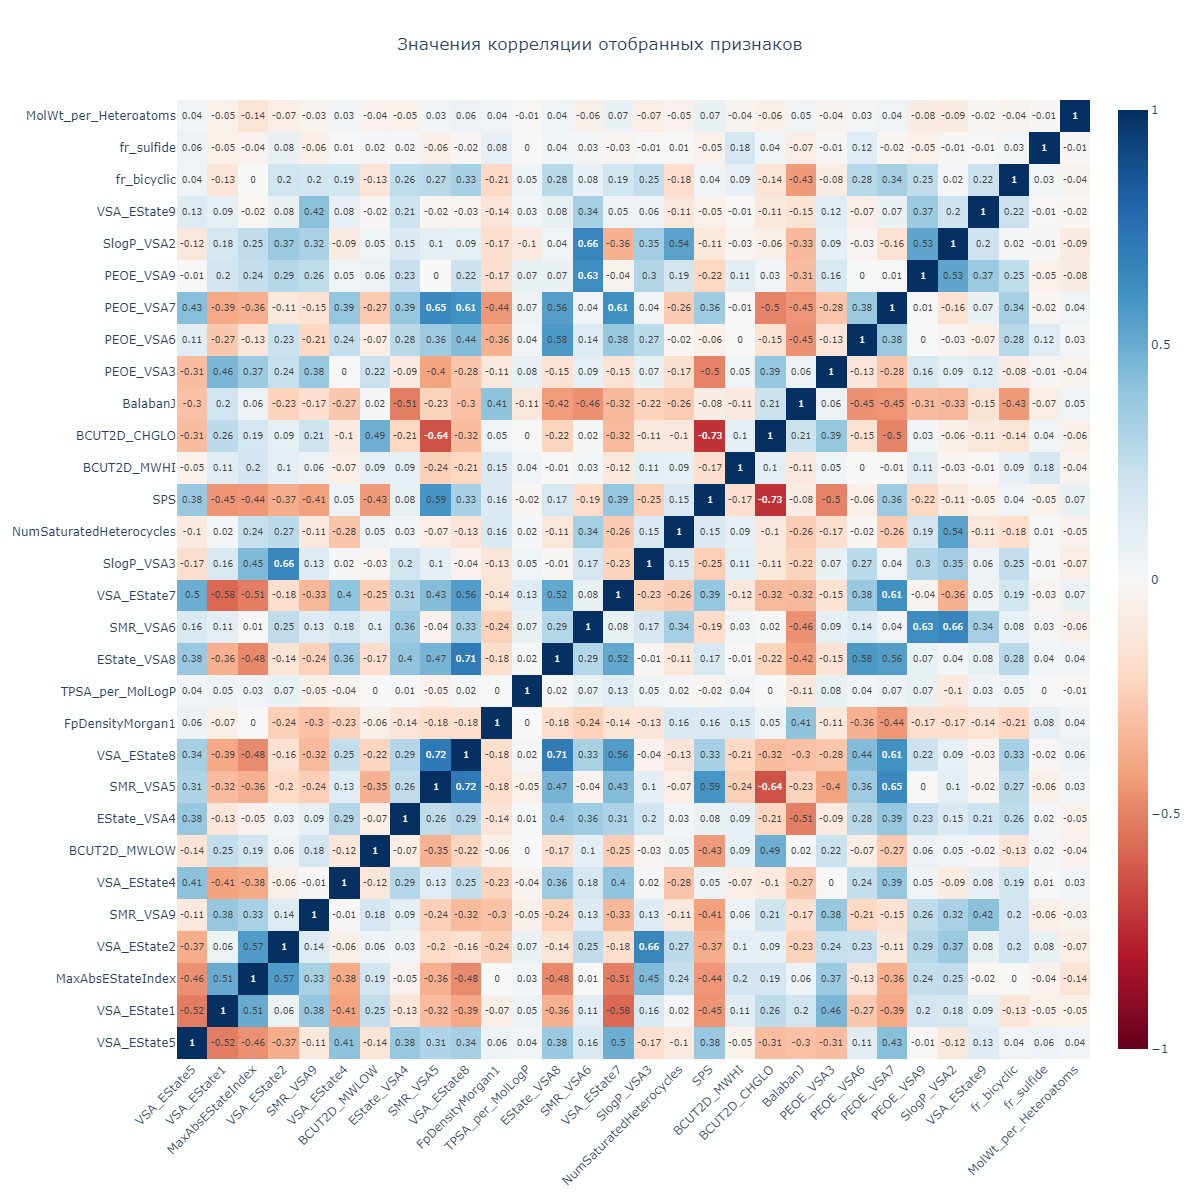

------------------------------------------------------------------------------------------------------------------------------------------------------


In [52]:
# Применяем функцию 'heatmap_corr()' для построения тепловой карты корреляции
heatmap_corr(data = X_train_final)

**Вывод:**

Из полученной тепловой карты видно, что значения корреляций находятся в пределах $+-0.79$, следовательно высококоррелированные связи отсутствуют. Данные полностью готовы к использованию для обучения модели.

#### $3.3$

#### **Machine Learning.**

Используем всё те же модели, что и для предсказания `IC50` и `CC50`: 

* **XGBoost (Extreme Gradient Boosting)**, 
* **LightGBM (Light Gradient Boosting Machine)**, 
* **Support Vector Machine (SVM) с ядром RBF**, 
* **RandomForestClassifier**, 
* **MLPClassifier**.

Используем созданный ранее словарь `ML_models`, после чего обучим модели и построим предсказания:

In [47]:
# Создаём словарь, в котором будем хранить наши предсказания
results = {}


# Создём цикл по созданному ранее словарю с моделями
# и обучаем их при помощи функции 'train_model'
for name, config in ML_models.items():
    
    # Заносим в словарь 'results' модели и метрики
    results[name] = train_model(
        name,
        config = config,
        X_train = X_train_final,
        X_test = X_test_final,
        y_train = y_train,
        y_test = y_test
    )




Обучение модели: XGBoost
Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Лучшие параметры для XGBoost: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'scale_pos_weight': 1, 'subsample': 1.0}
--------------------------------------------------------------------------------




XGBoost (значения метрик):

Accuracy: 0.624
--------------------------------------------------------------------------------
Precision: 0.639
--------------------------------------------------------------------------------
Recall: 0.624
--------------------------------------------------------------------------------
F1-score: 0.618
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.59      0.76      0.66        88
           1       0.69      0.49      0.57        93

    accuracy                           0.62       181
   macro 

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



#### $3.4$

#### **Определяем лучшую модель.**

Составим таблицу (**DataFrame**) со следующими столбцами:

Наименование модели:

* `model_name`,

Метрики и их значения:

* `Accuracy`,

* `Precision`,

* `Recall`,

* `F1-score`.

In [132]:
# Создаём DataFrame
model_metrics = {
    'XGBClassifier'             : {'Accuracy': 0.624, 'Precision': 0.639, 'Recall': 0.624, 'F1-score': 0.618},
    'LGBMClassifier'            : {'Accuracy': 0.630, 'Precision': 0.631, 'Recall': 0.630, 'F1-score': 0.630},
    'RandomForestClassifier'    : {'Accuracy': 0.652, 'Precision': 0.657, 'Recall': 0.652, 'F1-score': 0.651},
    'SupportVectorClassifier'   : {'Accuracy': 0.657, 'Precision': 0.668, 'Recall': 0.657, 'F1-score': 0.654},
    'MLPClassifier'             : {'Accuracy': 0.663, 'Precision': 0.663, 'Recall': 0.663, 'F1-score': 0.663}
}

metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.reset_index().rename(columns = {'index': 'model_name'})

**Визуализация метрик.**

Теперь построим графики по каждой метрике, чтобы сравнить их друг с другом визуально.


Данные таблицы "metrics_df" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 5.
-----------------------------------


,model_name,Accuracy,Precision,Recall,F1-score
0,XGBClassifier,0.624,0.639,0.624,0.618
1,LGBMClassifier,0.630,0.631,0.630,0.630
2,RandomForestClassifier,0.652,0.657,0.652,0.651
3,SupportVectorClassifier,0.657,0.668,0.657,0.654
4,MLPClassifier,0.663,0.663,0.663,0.663


------------------------------------------------------------




Столбчатая диаграмма сравнения метрик моделей классификации ("CC50"):
------------------------------------------------------------------------------------------------------------------------------------------------------


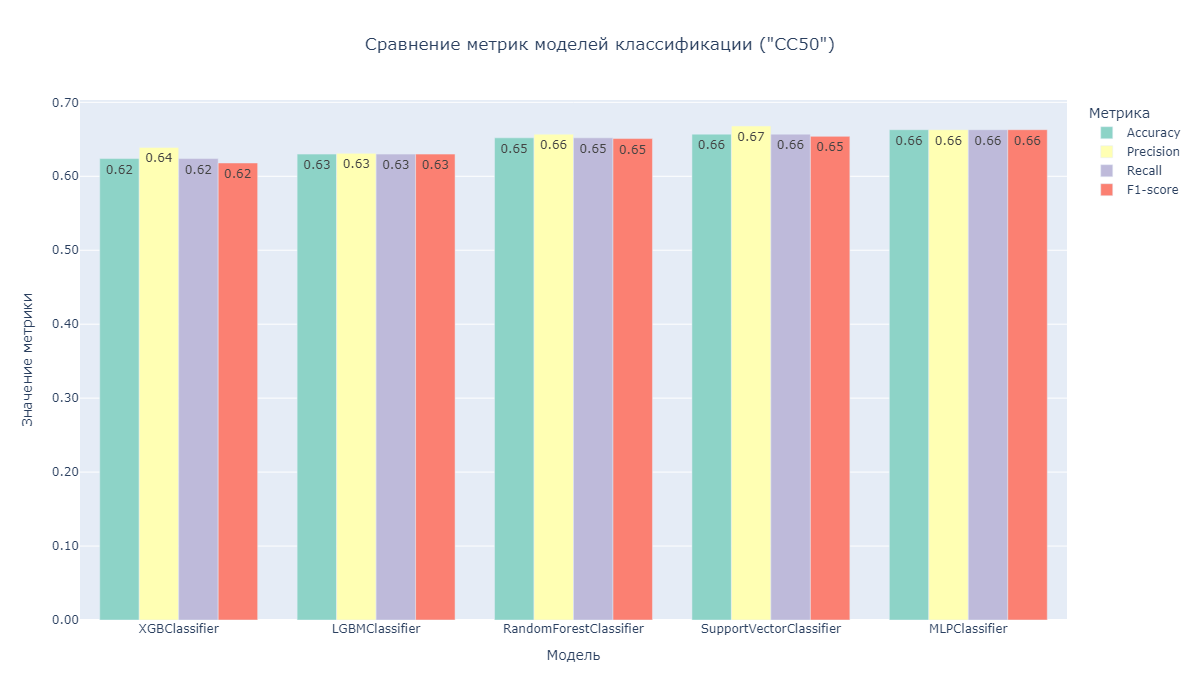

------------------------------------------------------------------------------------------------------------------------------------------------------


In [133]:
# Выводим результат
check_data_inf(
    data = metrics_df,
    data_name = 'metrics_df',
    length1 = 35,
    length2 = 60
)
print('\n\n')


# Применяем функцию 'metrics_bar_plot()' для построения столбчатого графика метрик
metrics_bar_plot(
    data = metrics_df,
    main_title = 'Столбчатая диаграмма сравнения метрик моделей классификации ("CC50"):',
    title = 'Сравнение метрик моделей классификации ("CC50")',
    colors = px.colors.qualitative.Set3
)

#### $3.5$

#### **Вывод.**

На данном этапе сделаем вывод итоговым метрикам и моделям, обученным для предсказания целевой переменной `SI`.

Лучшие значения метрик показала модель `MLPClassifier`.

=============================================================================================================================================

## <CENTER> **`4.` Machine Learning (превышает ли значение SI значение 8)**

На данном этапе мы построим несколько подходящих моделей классификации для **SI** и выберем наилучшую.

#### $4.1$

#### **Предобработка данных.**

Как и раньше, предобработаем данные при помощи созданного ранее пайплайна, только все этапы по предобработке, созданию и удалению признаков включим в отдельный класс.

Повторно загружаем пайплайн:

In [11]:
# Загружаем пайплайн при помощи joblib
preprocessing_pipeline = joblib.load('data/preprocessing_pipeline.joblib')
print("Пайплайн загружен из 'preprocessing_pipeline.joblib'")

Пайплайн загружен из 'preprocessing_pipeline.joblib'


Создаём целевую переменную:

Уникальные значения признака "SI_and_8_classif":



SI_and_8_classif
0    609
1    295
Name: count, dtype: int64

---------------------------------------------


Стобчатая и круговая диаграммы распределения целевой переменной "SI_and_8_classif":
------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



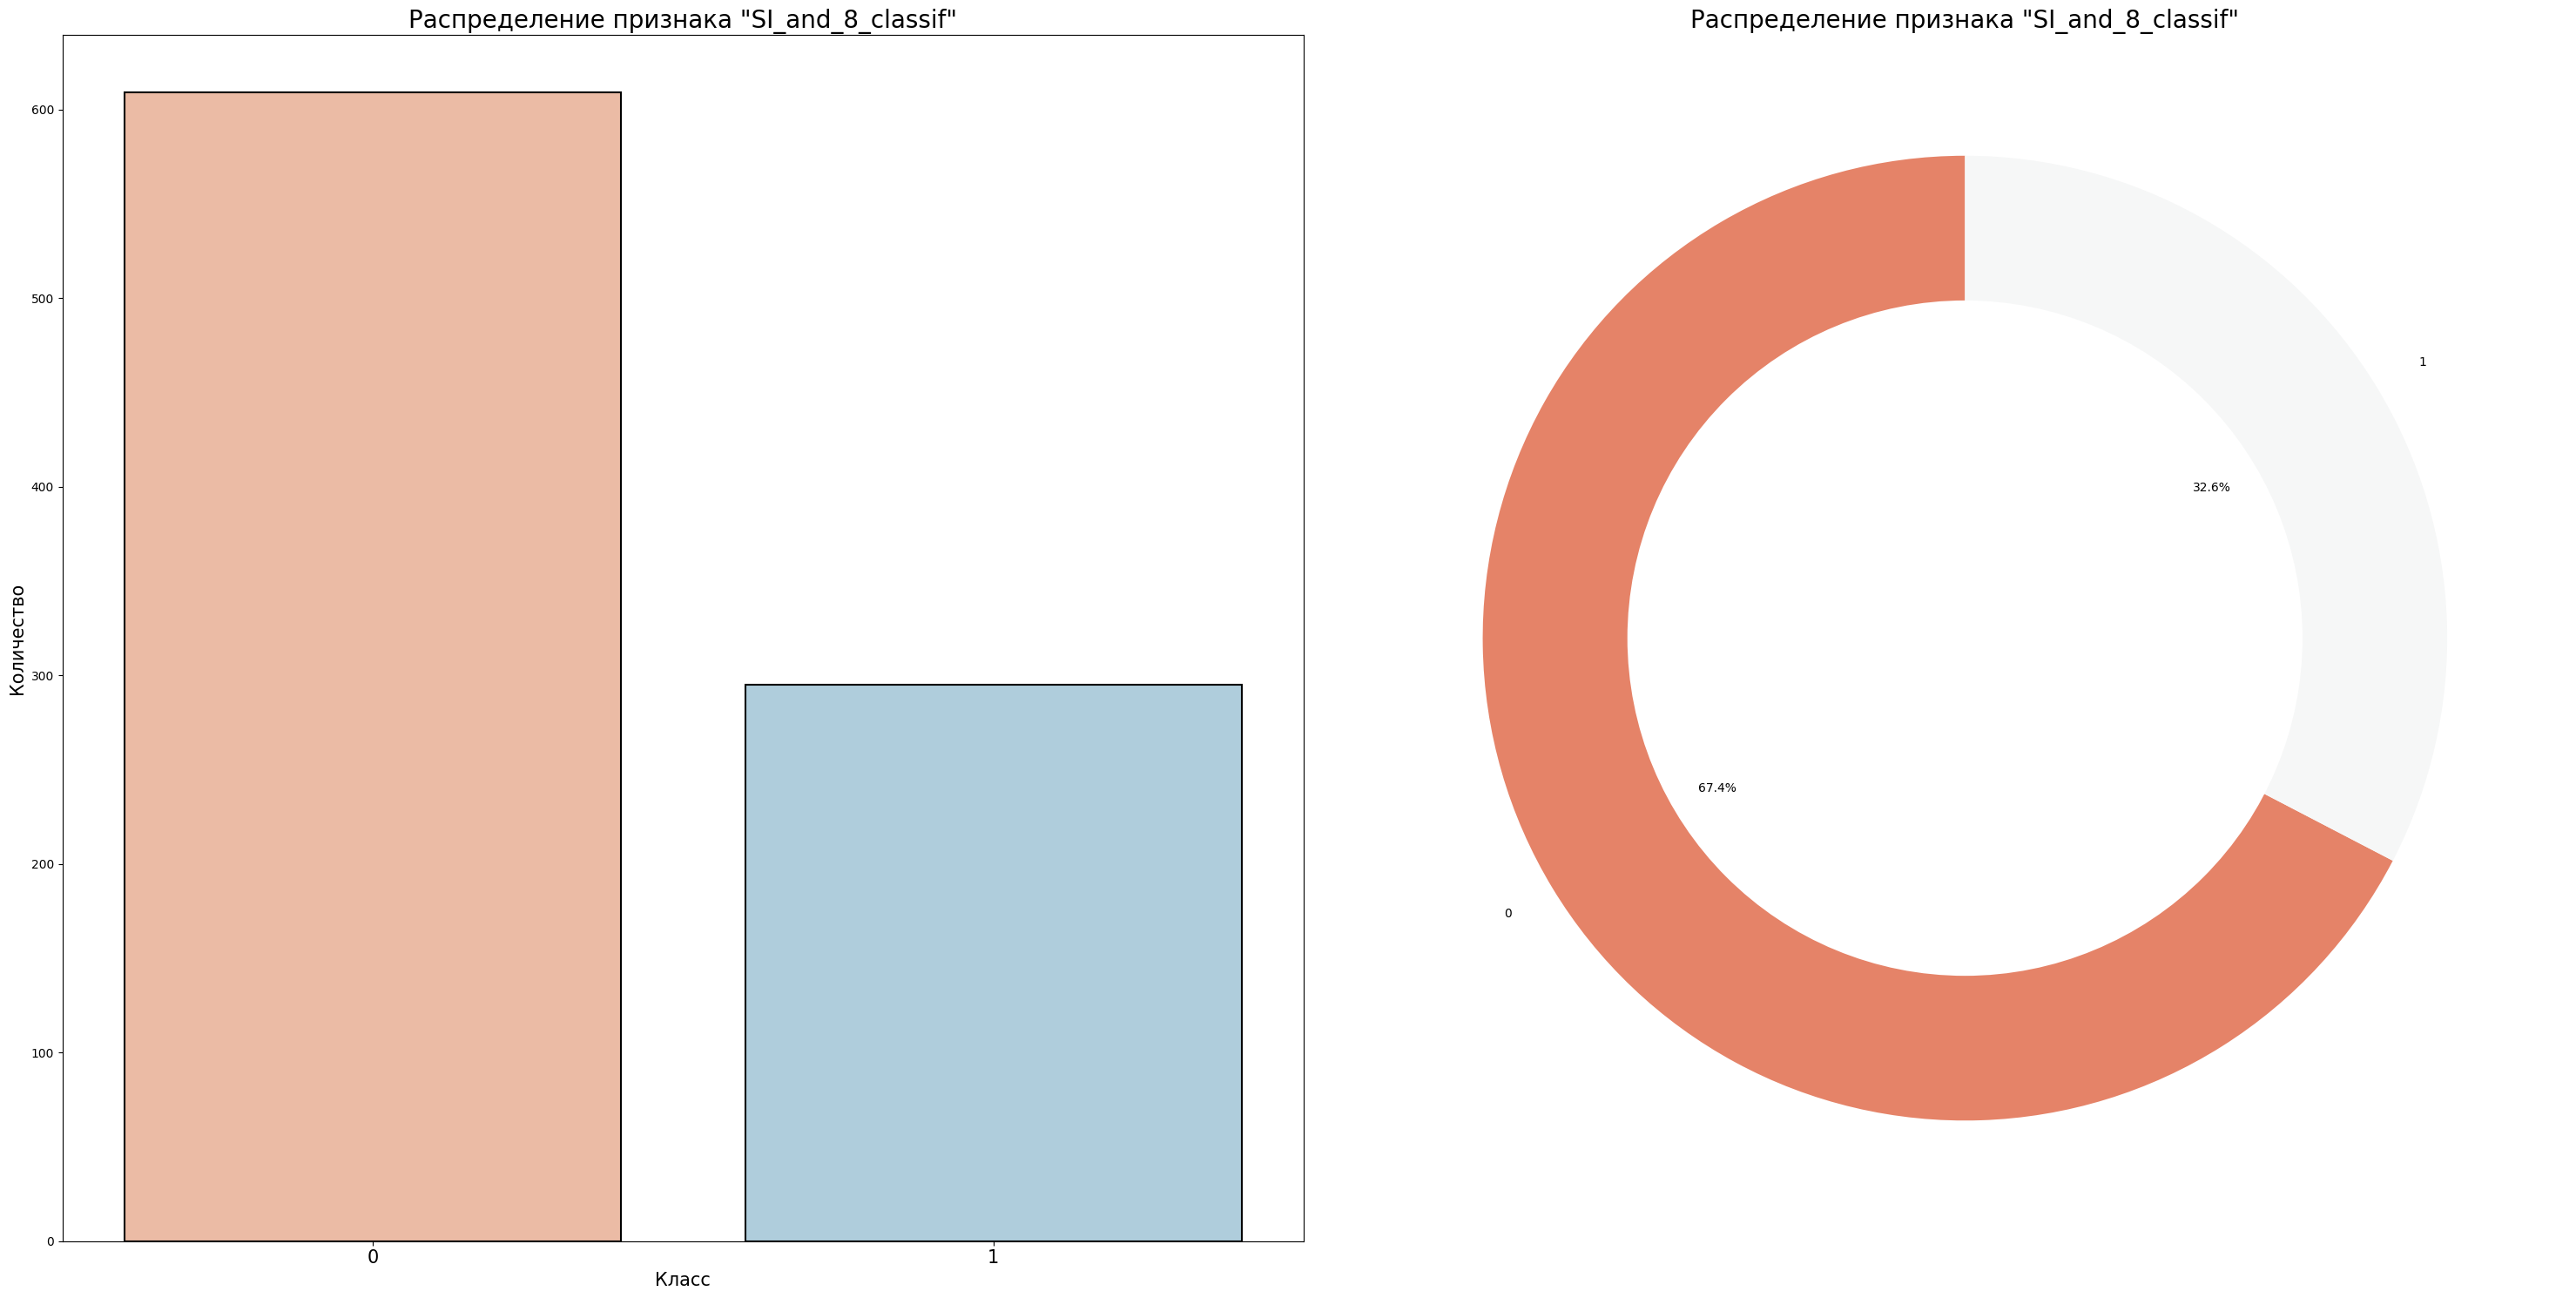

------------------------------------------------------------------------------------------------------------------------------------------------------


Распределение целевой переменной "SI"
------------------------------------------------------------------------------------------------------------------------------------------------------


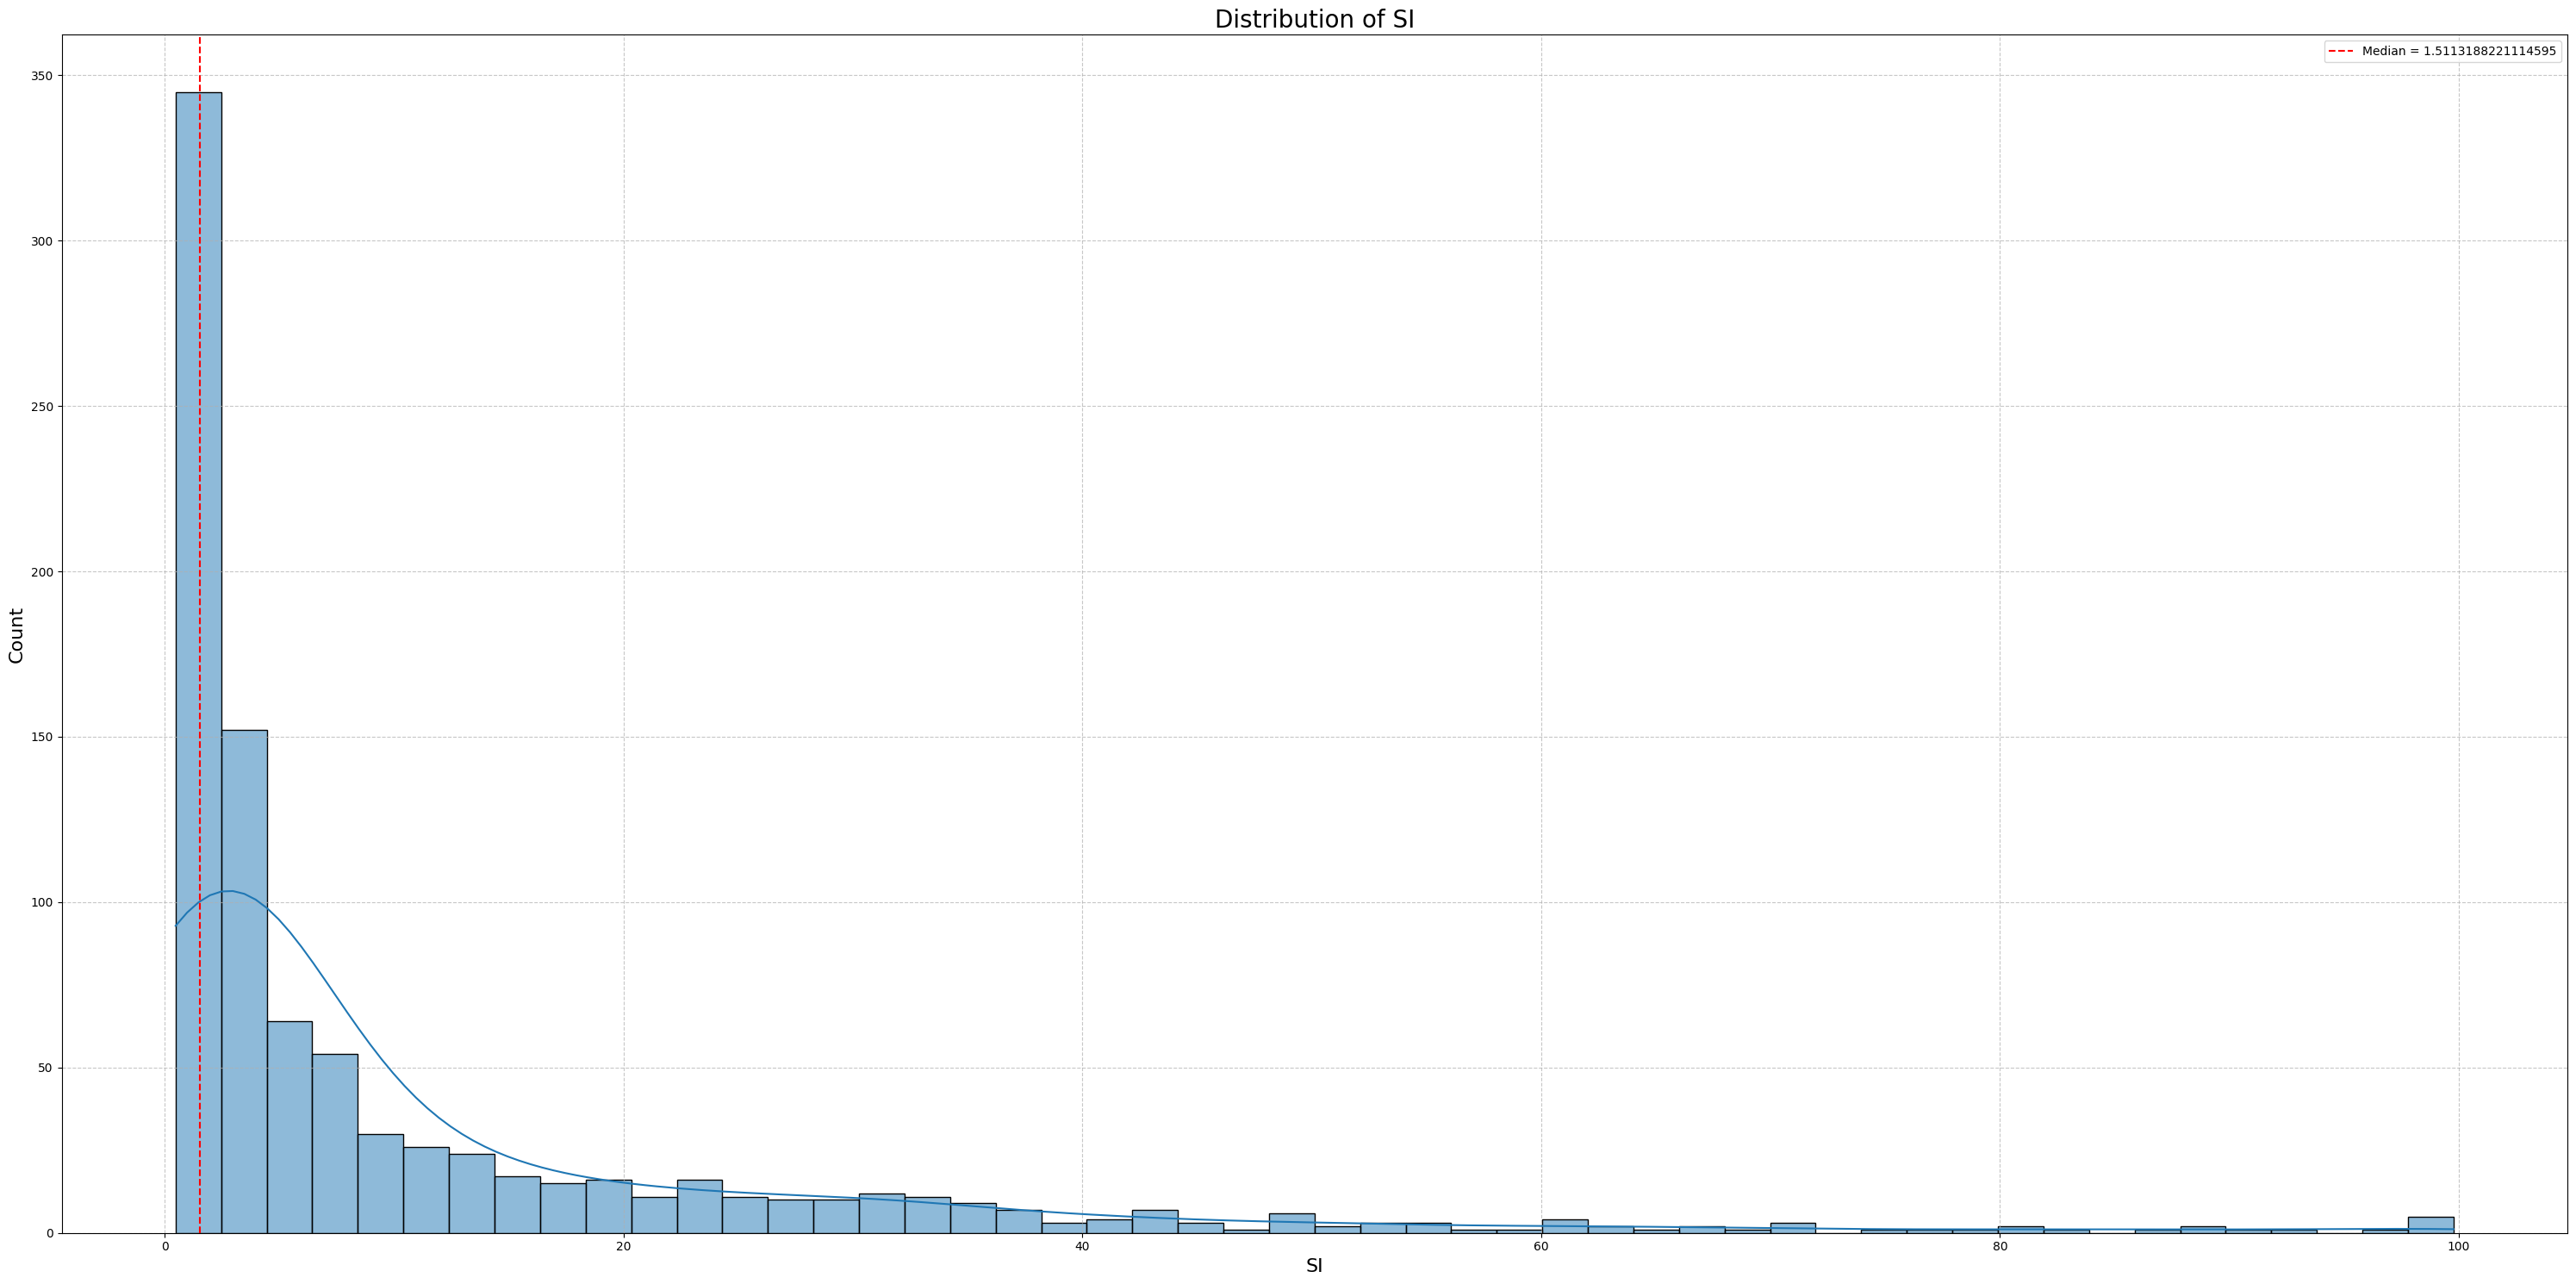

------------------------------------------------------------------------------------------------------------------------------------------------------


In [55]:
# Создаем целевую переменную (1 - превышает 8, 0 - не превышает)
molecule_df['SI_and_8_classif'] = (molecule_df['SI'] > 8).astype(int)
print('Уникальные значения признака "SI_and_8_classif":\n')
display(molecule_df['SI_and_8_classif'].value_counts())
print('-' * 45)



# Применяем функцию 'median_target_distribution_plot()' для построения графика распределения целевой переменной
median_target_distribution_plot(
    target = molecule_df['SI_and_8_classif'],
    title1 = 'Распределение признака "SI_and_8_classif"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной "SI_and_8_classif":',
    color_palette = 'RdBu',
    figsize = (30, 15)
)

# Применяем функцию 'target_distribution_plot()' для построения графика распределения целевой переменной
target_distribution_plot(
    data = molecule_df,
    target = 'SI',
    median_target = median_si,
    title = 'Distribution of SI',
    main_title = 'Распределение целевой переменной "SI"',
    figsize = (30, 15)
)

**Вывод:**

Из построенных визуализаций виден явный дисбаланс, особенно выделяется преобладание класса $0$ ($67.4$%) над $1$ ($32.6$%). 

Для дальнейшей работы требуется балансировка классов.

**Разделение данных.**

Разделим данные на тматрицу наблюдений и вектор правильных ответов:

In [42]:
# Разделяем данные на матрицу наблюдений и вектор правильных ответов
X = molecule_df.drop(columns = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI', 'IC50_classif', 'CC50_classif', 'SI_classif', 'SI_and_8_classif'])
y = molecule_df['SI_and_8_classif']

Применим созданный ранее класс к данным:

In [43]:
# Создаём экземпляра класса 'DataPreprocessor'
DP_processor = DataPreprocessor(preprocessing_pipeline)

# Обработка данных
DP_processor.fit_transform(X, y)

# Получение обработанных данных
X_train_processed_df, X_test_processed_df, y_train, y_test, remaining_features = DP_processor.get_processed_data()


Данные таблицы "Molecular properties features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
------------------------------------------------------------




Данные таблицы "Functional groups features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 8.
----------------------------------------
------------------------------------------------------------------------------------------




Данные таблицы "Topological descriptors features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 4.
----------------------------------------
--------------------------------------------------------------------------------




Данные таблицы "Transformations features" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 3.
----------------------------------------
---------------------------------------------------

Выводим результат:

In [44]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_processed_df,
    data_name = 'X_train_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_processed_df,
    data_name = 'X_test_processed_df',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по оставшимся признакам
print(f'Оставшиеся признаки:\n\n{remaining_features.tolist()}')
print('-' * 150)


Данные таблицы "X_train_processed_df" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 103.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_quatN,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,-1.496602,0.422613,0.771519,0.579771,-0.081941,-0.172284,-0.720975,-0.482466,-0.231601,0.709602,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064531,-0.017568,-0.338656,-0.806000,-0.332149
1,0.527403,0.904784,-0.394927,0.514586,-0.554818,-0.694608,-0.970049,-0.465835,0.425592,0.670103,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064565,0.133615,-0.338656,-0.806000,-0.857136
2,0.252959,-0.894628,0.392277,0.397569,0.511590,-0.034503,1.347721,0.555049,-0.313054,0.077316,...,-0.174679,-0.210093,-0.266667,3.294307,-0.177731,-0.064578,0.146636,-0.338656,0.736551,1.215385
3,-1.210453,0.216033,0.750903,0.746949,1.699045,-1.145565,-0.554926,-0.589790,-0.967502,0.838770,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064458,-0.019390,-0.338656,-0.806000,-0.065901
4,0.694610,-0.824197,0.472459,1.392750,-0.120265,-0.264281,0.954612,0.555048,-0.403346,-0.483621,...,-0.174679,-0.210093,3.750000,-0.303554,-0.177731,-0.064567,0.009951,-0.338656,0.207477,-0.043975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.251380,0.324610,0.428609,-0.563375,-0.001549,-0.241286,0.655849,-0.479027,-0.231089,0.700544,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064533,-0.010548,-0.338656,0.211154,-0.300668
719,-1.577604,1.146384,0.843749,0.769183,0.451116,-0.010688,0.083725,-0.482669,-0.749877,0.230117,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064481,-0.085575,-0.338656,-0.300500,-0.744117
720,0.439661,-0.198519,0.198692,0.502574,-0.661393,0.463493,-0.416552,0.557248,0.434471,-0.335264,...,-0.174679,3.494726,-0.266667,-0.303554,-0.177731,-0.064571,0.086950,-0.338656,-0.806000,-0.622234
721,0.980138,-0.326590,-0.499596,-0.363831,-1.475648,0.285924,-0.703184,-0.304289,0.607120,-1.303146,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064583,0.134657,-0.338656,-0.806000,-0.643005


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_processed_df" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 103.
----------------------------------------


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_quatN,fr_sulfide,fr_thiazole,fr_thiophene,fr_unbrch_alkane,MolWt_per_Heteroatoms,TPSA_per_MolLogP,fr_Al_OH_per_benzene,SMR_VSA_ratio,TPSA_times_FractionCSP3
0,0.160756,-0.510352,-0.302029,-0.353559,-1.315644,-0.863532,1.780140,0.559264,2.296748,-1.732256,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064599,-1.198955,-0.338656,0.168554,-0.016665
1,0.552605,-0.468304,-2.184035,-1.056662,-1.369489,-0.089109,0.528003,0.552297,1.154219,-0.893501,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064590,0.128426,-0.338656,1.068112,-0.717143
2,-0.045459,-1.061101,0.108325,0.426638,0.811860,-0.471906,1.224172,-0.471246,-0.265352,0.017607,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064578,0.213022,1.475033,1.241226,1.433804
3,0.464136,0.524951,-1.212053,-1.368374,-0.291834,0.854706,0.353155,0.492597,-0.231089,0.701536,...,-0.174679,-0.210093,-0.266667,-0.303554,0.788429,-0.064576,0.094904,-0.338656,1.152177,1.983047
4,-1.720945,1.330435,0.862116,-1.065667,0.899075,0.426860,-2.215418,-0.592477,-0.231368,0.760929,...,-0.174679,-0.210093,-0.266667,-0.303554,4.653068,-0.064459,-0.076881,-0.338656,-0.806000,-0.190647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,-1.488398,1.708016,0.899797,0.058433,1.462212,-1.667184,0.690443,-0.603011,0.127272,-0.483112,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064510,0.065149,-0.338656,-0.806000,-0.065901
177,0.562094,0.446785,0.434776,0.703003,-1.149026,-0.103926,-0.554926,-0.504065,0.884829,-1.319795,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064572,0.100585,-0.338656,-0.806000,-0.833169
178,0.417928,0.379878,0.409685,-0.011909,-1.476949,-0.073419,-0.395263,-0.482662,1.260989,-2.026415,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064572,0.099420,-0.338656,-0.806000,-0.842731
179,0.044589,-0.244271,0.028994,1.031010,0.347881,0.057249,-0.075938,-0.478956,-0.226828,0.099772,...,-0.174679,-0.210093,-0.266667,-0.303554,-0.177731,-0.064570,0.247098,-0.338656,-0.806000,0.764520


------------------------------------------------------------------------------------------------------------------------------------------------------




Оставшиеся признаки:

['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA7', 'SlogP_VSA8', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState4', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NumAliphatic

По результатам видно, что данные, после применения класса, имеют схожую структуру, что и при прошлой предобработки.

Проверим распределение признаков при помощи визуализации:


График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


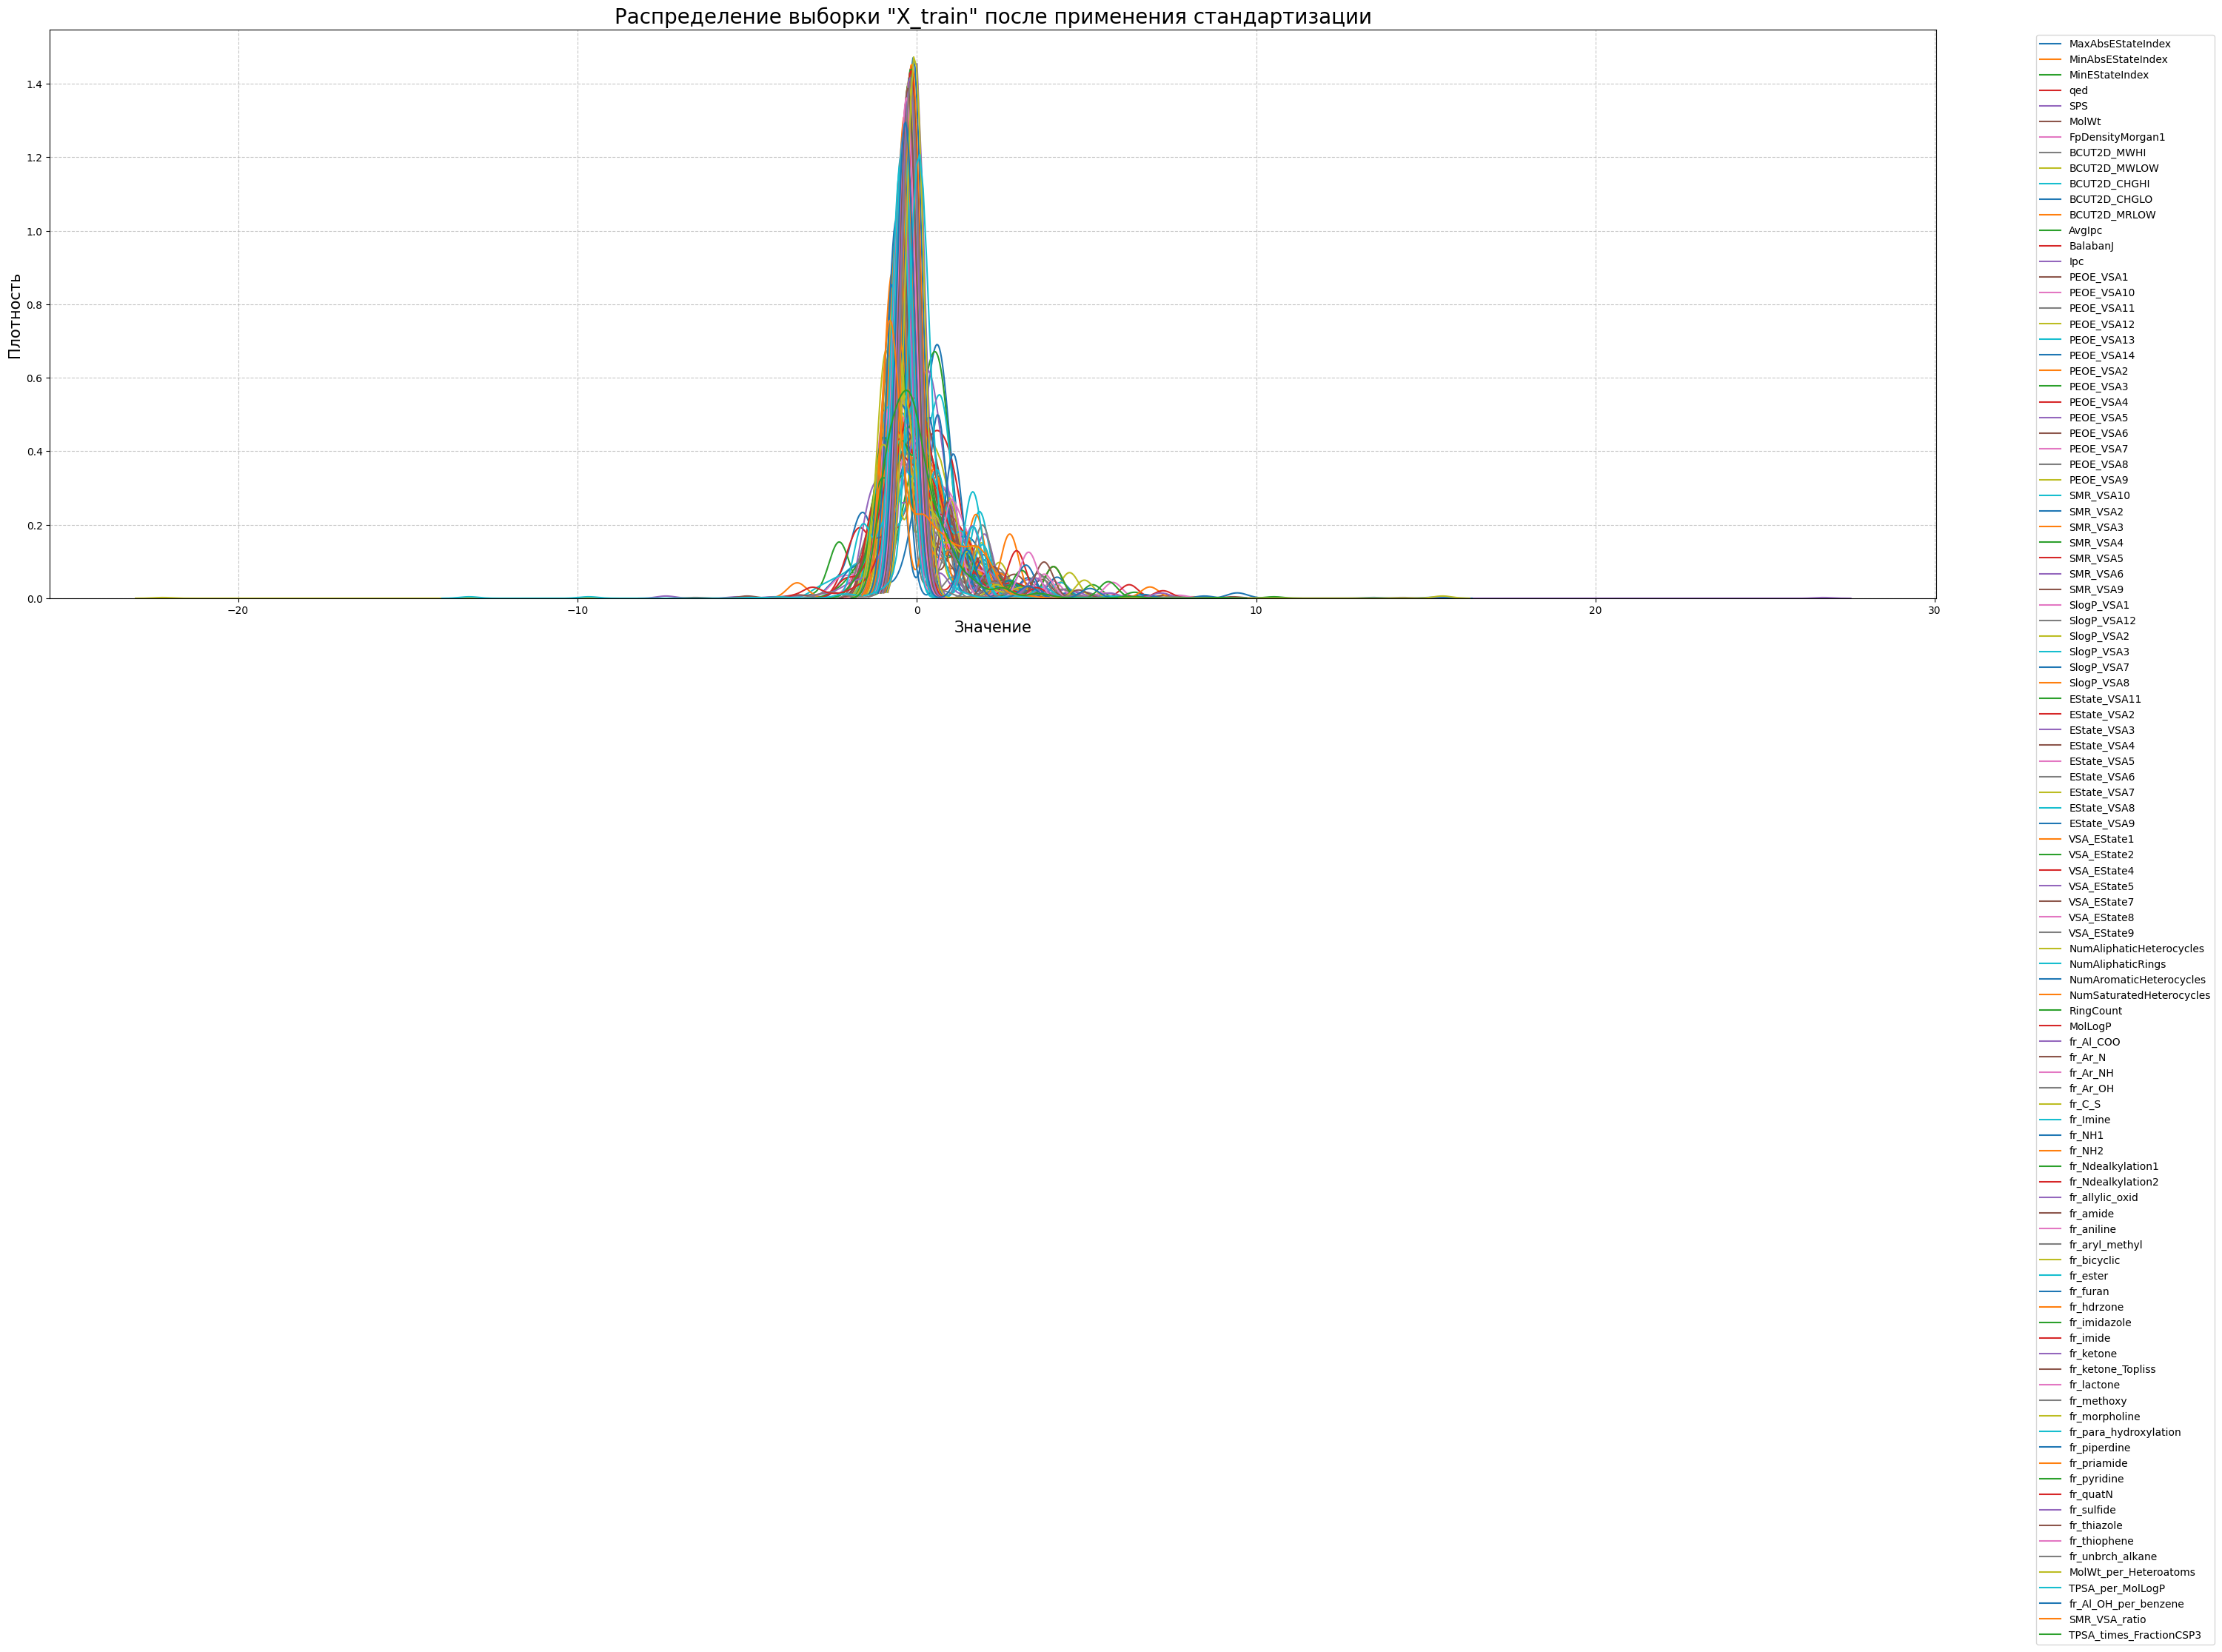

------------------------------------------------------------------------------------------------------------------------------------------------------



График распределения признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


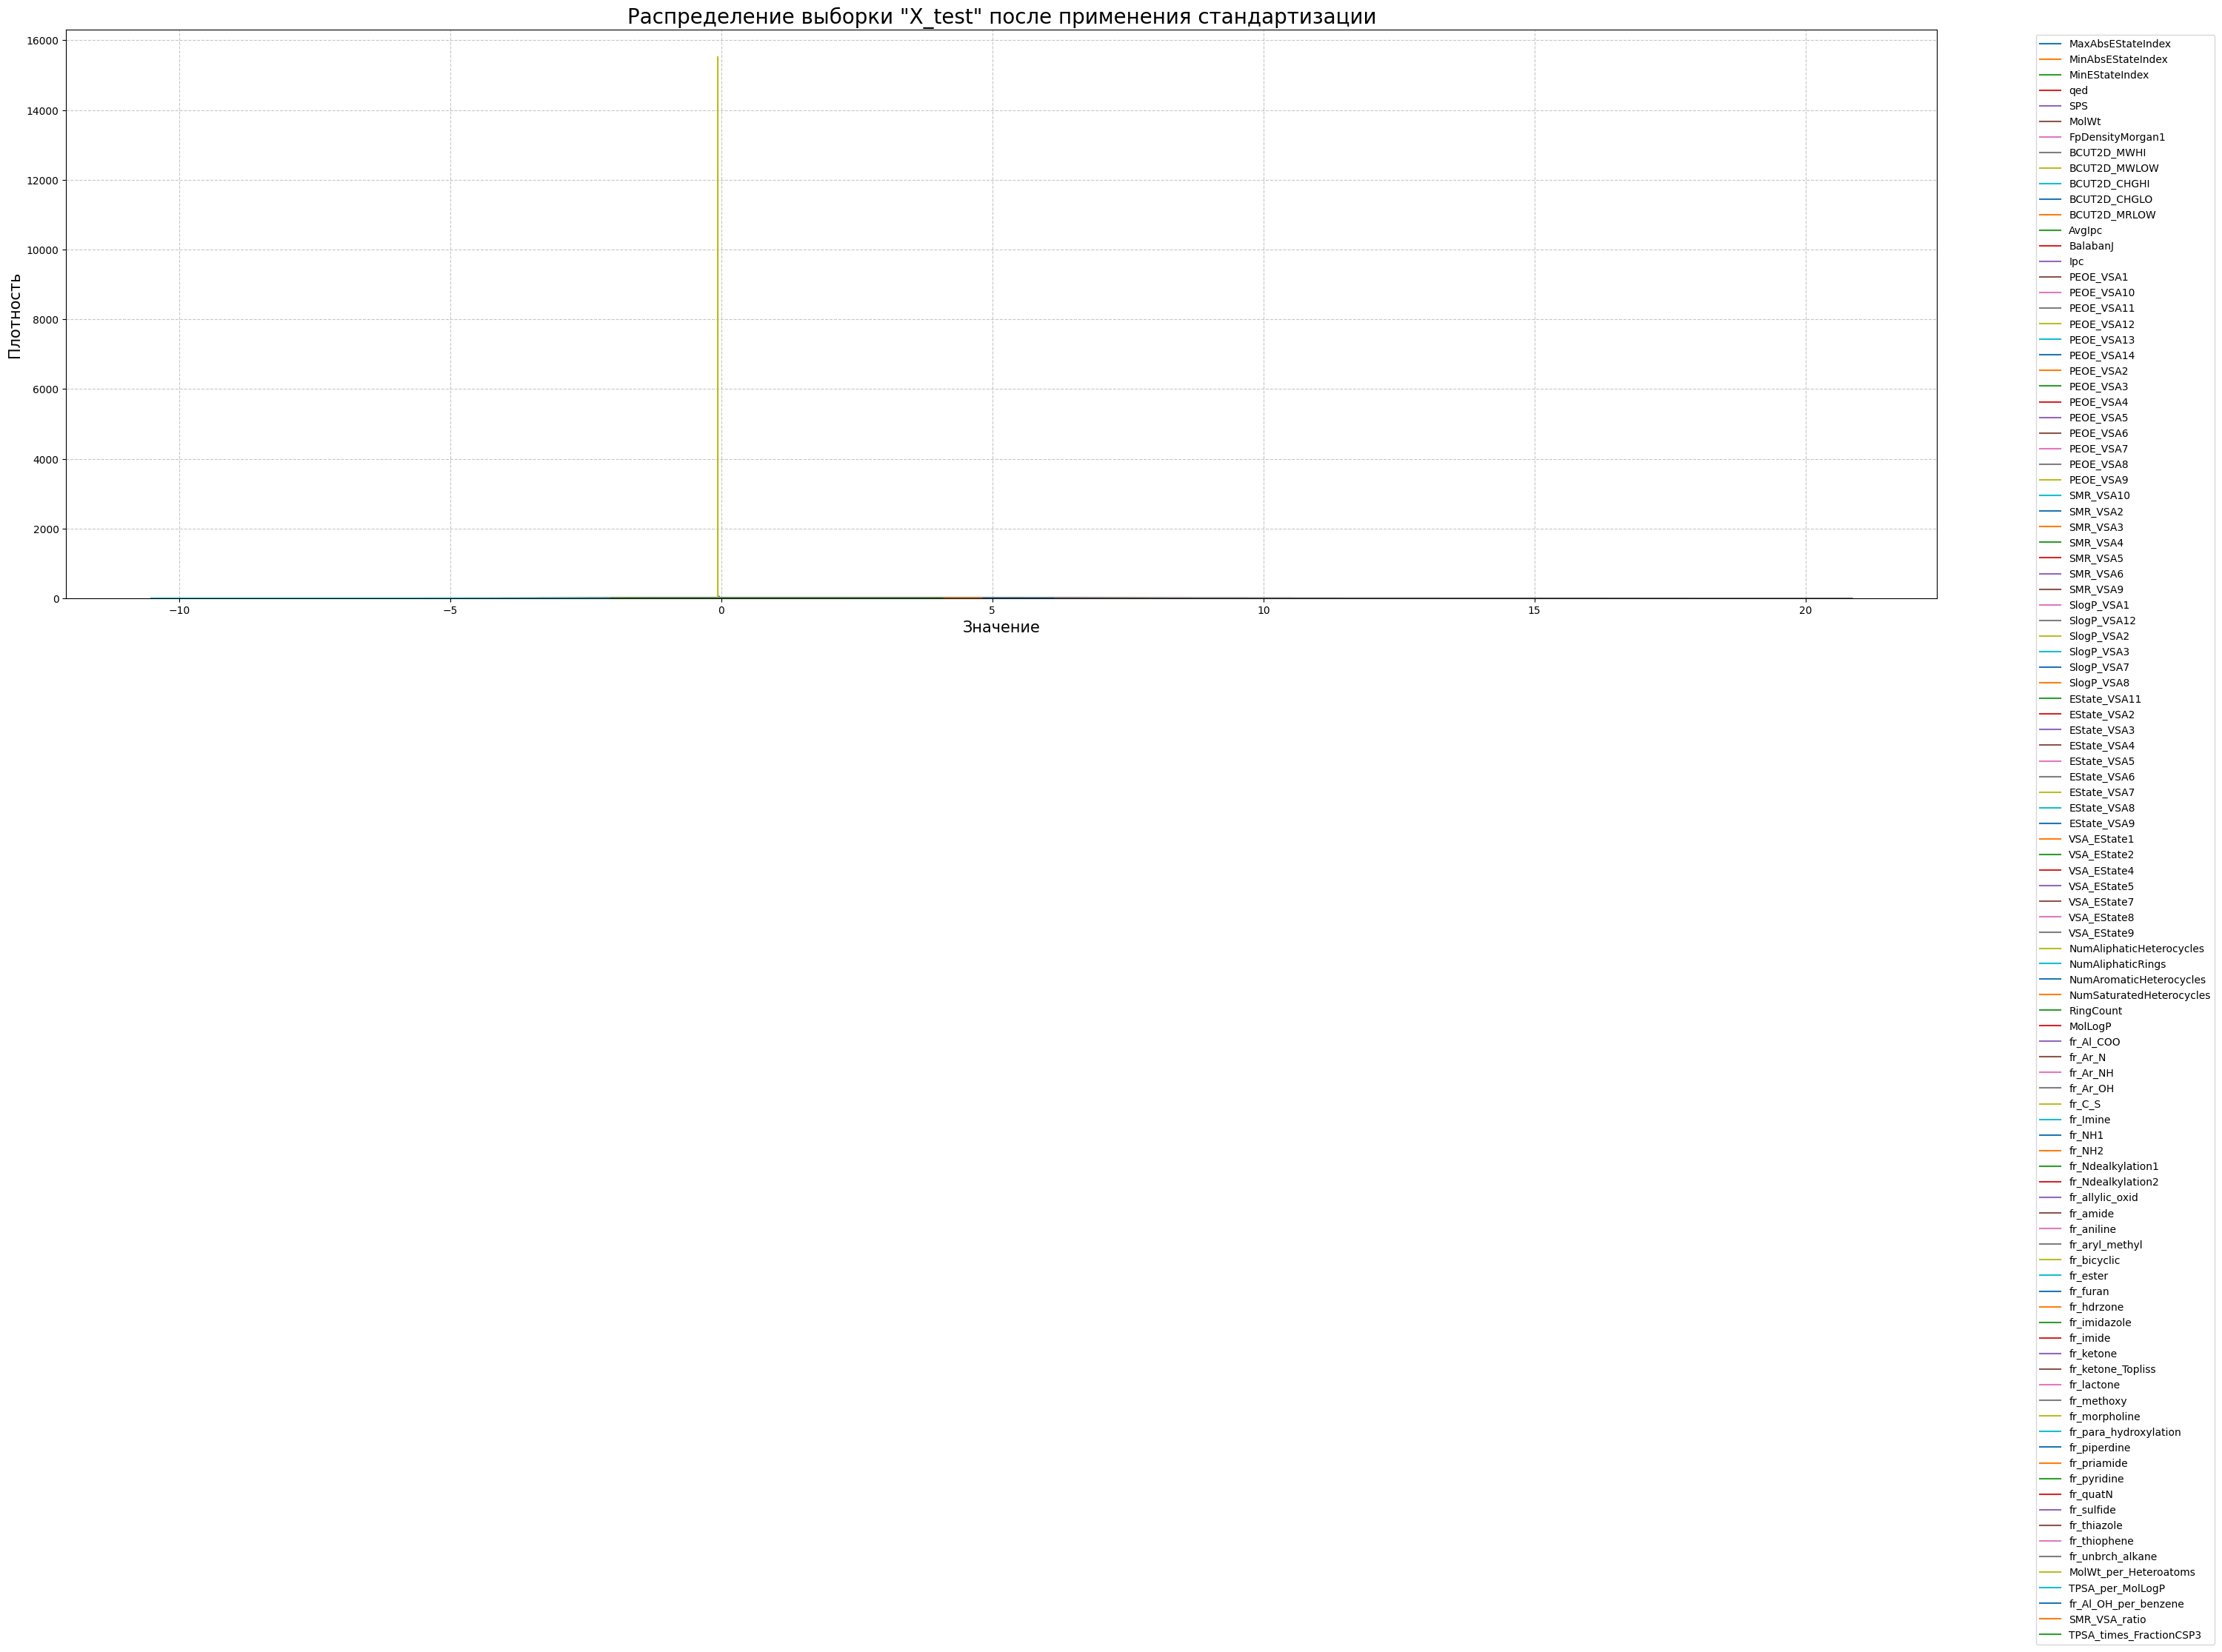

------------------------------------------------------------------------------------------------------------------------------------------------------


In [45]:
# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_train
print()
features_distribution_plot(
    data = X_train_processed_df,
    title = 'Распределение выборки "X_train" после применения стандартизации',
    figsize = (30, 17)
)

# Добавляем отступ
print('\n\n')



# Применяем функцию 'features_distribution_plot()' для построения графика распределения признаков X_test
features_distribution_plot(
    data = X_test_processed_df,
    title = 'Распределение выборки "X_test" после применения стандартизации',
    figsize = (30, 17)
)

**Вывод:**

Распределение признаков также нормализовалось.

#### $4.2$

#### **Отбор самых информативных признаков.**

На данном этапе отберём только самые информативные признаки для дальнейшего решения задачи регрессии.

Производить отбор признаков будем так же, как и для `SI`, в $4$ этапа:

1. Отберём $50$ признаков с помощью алгоритма **Mutual Information**,
2. Отберём $50$ признаков с помощью алгоритма **F-test**,
3. Отберём $50$ признаков из отобранных обоими алгоритмами,
4. Из оставшихся отберём $30$ признаков с помощью алгоритма **Lasso**.

Только сейчас, все этапы обернём в класс, чтобы использовать его в будущем.

Применим созданный ранее класс `FeatureSelector` к данным:

In [46]:
# Инициализируем класс 'FeatureSelector'         
feature_selector = FeatureSelector(
    mi_k = 50,
    f_k = 50,
    log_max_features = 30,
    penalty = 'l1',
    solver = 'liblinear',
    C = 1.0
)

# Обучаем класс на данных
feature_selector.fit_transform(X_train_processed_df, X_test_processed_df, y_train)

# Получение обработанных данных
X_train_final, X_test_final, final_features = feature_selector.get_final_data()

# Выводим результат
feature_selector.print_results()


Топ-30 финальных признаков после "LogisticRegression"

NumSaturatedHeterocycles    0.884547
SMR_VSA6                    0.786580
SMR_VSA5                    0.675844
BCUT2D_CHGLO                0.463129
FpDensityMorgan1            0.429128
VSA_EState7                 0.427886
VSA_EState1                 0.388263
SlogP_VSA3                  0.375650
BCUT2D_MWLOW                0.365741
PEOE_VSA3                   0.334316
EState_VSA8                 0.312571
VSA_EState2                 0.302348
fr_sulfide                  0.273076
MaxAbsEStateIndex           0.249772
PEOE_VSA9                   0.231881
SPS                         0.228861
BalabanJ                    0.226167
MolWt_per_Heteroatoms       0.205401
SMR_VSA9                    0.165989
TPSA_per_MolLogP            0.160586
BCUT2D_MWHI                 0.143489
fr_bicyclic                 0.143002
SlogP_VSA2                  0.140065
VSA_EState8                 0.127948
PEOE_VSA6                   0.126722
PEOE_VSA7          

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning:

X has feature names, but SelectFromModel was fitted without feature names



Выведем информацию итоговых выборок:

In [47]:
# Информация по тренеровочной выборке
check_data_inf(
    data = X_train_final,
    data_name = 'X_train_final',
    length1 = 40,
    length2 = 150
)
print('\n\n\n')


# Информация по тестовой выборке
check_data_inf(
    data = X_test_final,
    data_name = 'X_test_final',
    length1 = 40,
    length2 = 150
)


Данные таблицы "X_train_final" имеют следующую размерность:

Количество строк: 723;
Количество признаков (столбцов): 30.
----------------------------------------


,VSA_EState5,VSA_EState1,MaxAbsEStateIndex,VSA_EState2,SMR_VSA9,VSA_EState4,BCUT2D_MWLOW,EState_VSA4,SMR_VSA5,VSA_EState8,...,BalabanJ,PEOE_VSA3,PEOE_VSA6,PEOE_VSA7,PEOE_VSA9,SlogP_VSA2,VSA_EState9,fr_bicyclic,fr_sulfide,MolWt_per_Heteroatoms
0,0.875327,-0.510177,-1.496602,-0.731273,0.461262,2.503470,-0.231601,1.012479,-0.054649,0.340090,...,-0.654310,-0.601189,-0.283280,1.628333,-0.741801,-1.133018,-0.375368,0.329319,-0.210093,-0.064531
1,-0.723162,-0.228040,0.527403,0.683650,-0.034331,0.014302,0.425592,-1.063253,-0.966737,-0.608620,...,0.358409,0.355968,-0.116601,-0.504015,0.137453,-0.889025,-0.375368,1.013507,-0.210093,-0.064565
2,0.320846,-0.483553,0.252959,0.581600,-0.529924,-0.834664,-0.313054,0.237265,0.752115,0.101432,...,0.156603,-0.601189,-0.096764,-0.457205,0.172684,-0.456006,-0.375368,-0.354869,-0.210093,-0.064578
3,1.075515,-0.823985,-1.210453,-1.092745,-0.529924,1.851472,-0.967502,-0.209812,0.756481,-0.097231,...,0.473720,-0.601189,-0.613549,1.143588,-1.196283,-1.139996,-0.375368,-1.039057,-0.210093,-0.064458
4,-0.077143,-0.068435,0.694610,-0.768015,-0.529924,-0.370231,-0.403346,1.428540,0.149113,0.375166,...,-0.202214,1.270268,0.257495,0.270976,0.107904,-0.445268,-0.375368,-0.354869,-0.210093,-0.064567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,0.172446,-0.542370,0.251380,0.099133,-0.529924,0.271046,-0.231089,-0.199418,-0.054649,0.481124,...,-0.761391,0.355968,1.163576,0.004357,-0.673288,-0.360715,-0.375368,0.329319,-0.210093,-0.064533
719,0.530838,-0.524807,-1.577604,-0.899965,-0.529924,1.202870,-0.749877,0.803055,0.983472,1.736961,...,-0.409259,-0.601189,1.221381,1.008224,-0.140364,0.160940,-0.375368,1.013507,-0.210093,-0.064481
720,0.166710,-0.541832,0.439661,0.650119,-0.034331,0.280488,0.434471,1.329183,-0.795632,-0.936206,...,-0.633789,-0.601189,1.040884,0.428075,0.311096,0.023722,0.585089,-0.354869,3.494726,-0.064571
721,-2.182500,2.477075,0.980138,0.705109,1.437336,-1.533837,0.607120,-0.954993,-1.391050,-0.936206,...,1.437318,2.108930,-1.274086,-0.786662,0.938577,-0.261109,1.857985,-0.354869,-0.210093,-0.064583


------------------------------------------------------------------------------------------------------------------------------------------------------





Данные таблицы "X_test_final" имеют следующую размерность:

Количество строк: 181;
Количество признаков (столбцов): 30.
----------------------------------------


,VSA_EState5,VSA_EState1,MaxAbsEStateIndex,VSA_EState2,SMR_VSA9,VSA_EState4,BCUT2D_MWLOW,EState_VSA4,SMR_VSA5,VSA_EState8,...,BalabanJ,PEOE_VSA3,PEOE_VSA6,PEOE_VSA7,PEOE_VSA9,SlogP_VSA2,VSA_EState9,fr_bicyclic,fr_sulfide,MolWt_per_Heteroatoms
0,-0.355714,-0.196948,0.160756,0.680807,-0.529924,-1.070186,2.296748,-1.452750,-1.218918,-0.936206,...,2.235256,-0.601189,-1.274086,-1.638111,0.074155,0.259309,-1.252551,-0.354869,-0.210093,-0.064599
1,-0.134131,1.861870,0.552605,-1.092745,-0.529924,0.072302,1.154219,-1.028044,-0.953746,-0.673554,...,0.360574,0.275292,-1.274086,0.323003,-0.284854,-0.514649,-0.375368,-1.039057,-0.210093,-0.064590
2,0.318123,-0.215910,-0.045459,-0.360243,-0.529924,-1.001606,-0.265352,-0.104185,0.523061,-0.224349,...,0.018830,-0.601189,-0.637539,-0.457205,0.223838,-0.485835,-0.375368,-0.354869,-0.210093,-0.064578
3,0.292743,0.821808,0.464136,-0.738469,-0.529924,0.251347,-0.231089,0.708760,1.275313,1.559249,...,-1.083867,-0.601189,-0.034597,0.666848,2.426146,0.786383,-2.119567,0.329319,-0.210093,-0.064576
4,0.653392,-0.823985,-1.720945,-0.357125,-0.529924,0.932722,-0.231368,0.292272,2.567789,2.072285,...,-1.655280,-0.601189,1.932642,1.404096,-1.196283,-0.373630,-0.375368,1.697695,-0.210093,-0.064459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,1.076714,-0.823985,-1.488398,-1.092745,-0.529924,1.288017,0.127272,-0.209812,-0.100876,-0.552634,...,0.469819,-0.601189,-0.967807,0.079415,-1.196283,-1.119683,-0.375368,0.329319,-0.210093,-0.064510
177,0.085952,-0.754509,0.562094,0.152801,0.440433,1.781502,0.884829,-0.275581,-0.928795,-0.267836,...,-0.366817,0.395470,1.016894,-0.711178,0.169628,-0.268689,-0.375368,-0.354869,-0.210093,-0.064572
178,0.432689,-0.135080,0.417928,0.121094,-0.034331,-0.127502,1.260989,-0.277778,-1.172573,-0.760104,...,-0.570250,0.393788,0.172770,-0.252574,0.708890,-0.472495,-0.375368,-0.354869,-0.210093,-0.064572
179,0.531638,0.380878,0.044589,-1.092745,0.956855,-0.465348,-0.226828,-0.673080,0.298145,-0.281073,...,0.394740,-0.601189,-0.984255,0.061704,1.931287,0.629610,2.387364,-0.354869,-0.210093,-0.064570


------------------------------------------------------------------------------------------------------------------------------------------------------


Сбалансируем классы. Для этого воспользуемся алгоритмом `RandomOverSampler`, который отлично подходит для случаев с экстремально малым количеством данных в классе:

In [58]:
# Импорт и инициализация RandomOverSampler
os = over_sampling.RandomOverSampler(
    random_state = 0, 
    sampling_strategy = 'auto'
)

# Сохранение исходных названий столбцов
columns = X_train_final.columns

# Применение RandomOverSampler для создания сбалансированных данных
X_train_os, y_train_os = os.fit_resample(X_train_final, y_train)

# Создание DataFrame для сбалансированных данных
X_train_os = pd.DataFrame(X_train_os, columns = columns)
y_train_os = pd.DataFrame(y_train_os, columns = ['SI_and_8_classif'])

# Вывод информации о сбалансированных данных
print(f'Размерность данных после применения RandomOverSampler: {X_train_os.shape}')
print('-' * 65)
print()

print(f'Распределение классов после применения RandomOverSampler:\n\n{y_train_os.value_counts()}')
print('-' * 65)

Размерность данных после применения RandomOverSampler: (984, 30)
-----------------------------------------------------------------

Распределение классов после применения RandomOverSampler:

SI_and_8_classif
0                   492
1                   492
Name: count, dtype: int64
-----------------------------------------------------------------


Построим график после устранения дисбаланса классов:



Стобчатая и круговая диаграммы распределения целевой переменной "SI_and_8_classif":
------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\User\AppData\Local\Temp\ipykernel_2088\4276034505.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



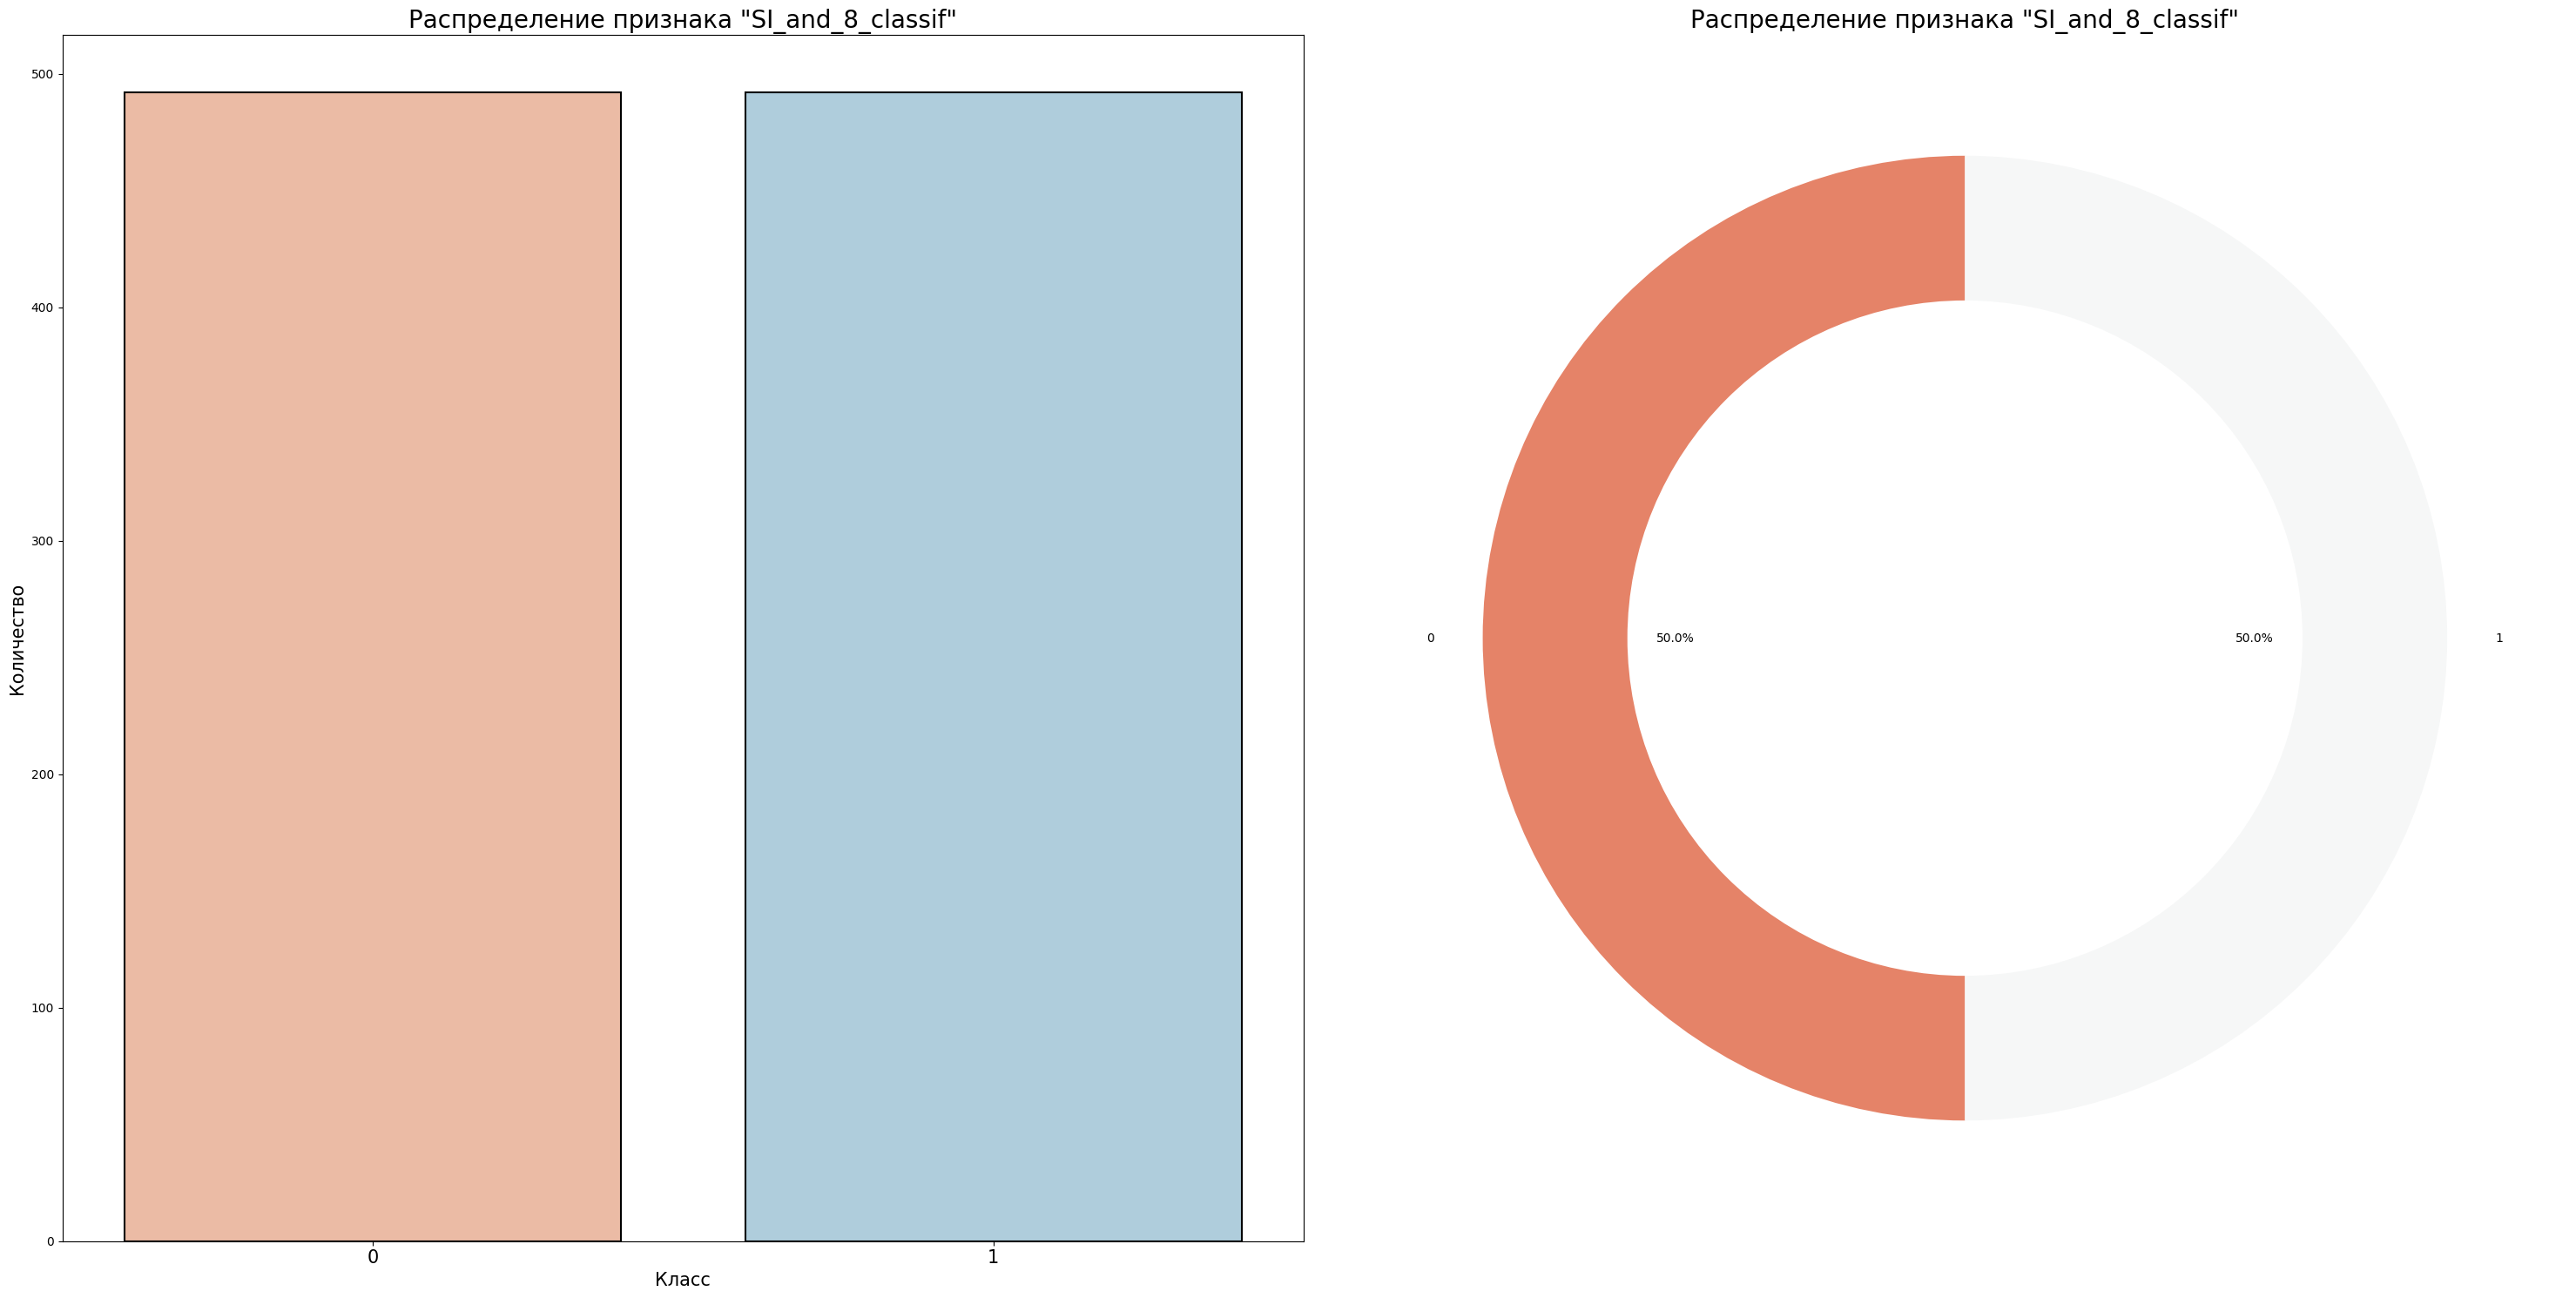

------------------------------------------------------------------------------------------------------------------------------------------------------


In [59]:
# Применяем функцию 'median_target_distribution_plot()' для построения графика распределения целевой переменной
median_target_distribution_plot(
    target = y_train_os['SI_and_8_classif'],
    title1 = 'Распределение признака "SI_and_8_classif"',
    main_title = 'Стобчатая и круговая диаграммы распределения целевой переменной "SI_and_8_classif":',
    color_palette = 'RdBu',
    figsize = (30, 15)
)

Проверим корреляцию отобранных признаков:


Тепловая карта корреляции отобранных признаков:
------------------------------------------------------------------------------------------------------------------------------------------------------


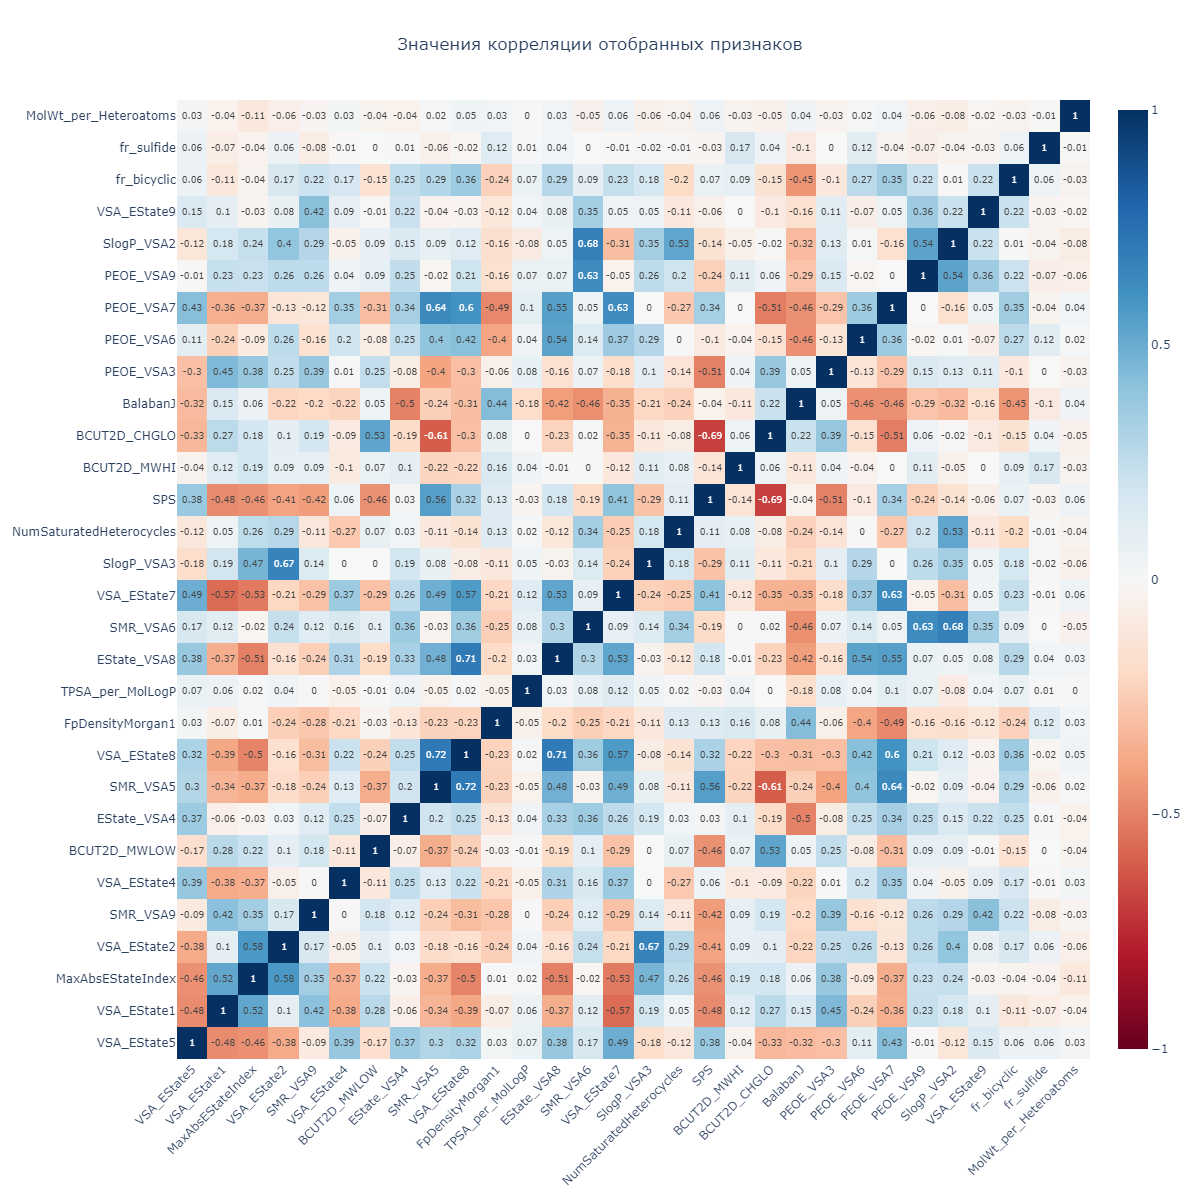

------------------------------------------------------------------------------------------------------------------------------------------------------


In [61]:
# Применяем функцию 'heatmap_corr()' для построения тепловой карты корреляции
heatmap_corr(data = X_train_os)

**Вывод:**

Из полученной тепловой карты видно, что значения корреляций находятся в пределах $+-0.69$, следовательно высококоррелированные связи отсутствуют. Данные полностью готовы к использованию для обучения модели.

#### $4.3$

#### **Machine Learning.**

Используем всё те же модели, что и для предсказания предыдущих переменных: 

* **XGBoost (Extreme Gradient Boosting)**, 
* **LightGBM (Light Gradient Boosting Machine)**, 
* **Support Vector Machine (SVM) с ядром RBF**, 
* **RandomForestClassifier**, 
* **MLPClassifier**.

Используем созданный ранее словарь `ML_models`, после чего обучим модели и построим предсказания:

Обучаем моделей и строим предсказания:

In [64]:
# Создаём словарь, в котором будем хранить наши предсказания
results = {}


# Создём цикл по созданному ранее словарю с моделями
# и обучаем их при помощи функции 'train_model'
for name, config in ML_models.items():
    
    # Заносим в словарь 'results' модели и метрики
    results[name] = train_model(
        name,
        config = config,
        X_train = X_train_os,
        X_test = X_test_final,
        y_train = y_train_os,
        y_test = y_test
    )




Обучение модели: XGBoost
Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Лучшие параметры для XGBoost: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.6}
--------------------------------------------------------------------------------




XGBoost (значения метрик):

Accuracy: 0.691
--------------------------------------------------------------------------------
Precision: 0.678
--------------------------------------------------------------------------------
Recall: 0.691
--------------------------------------------------------------------------------
F1-score: 0.678
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.73      0.83      0.78       117
           1       0.58      0.44      0.50        64

    accuracy                           0.69       181
   macro 

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Info] Number of positive: 492, number of negative: 492
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5208
[LightGBM] [Info] Number of data points in the train set: 984, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Лучшие параметры для SVC: {'C': 10, 'class_weight': 'balanced', 'gamma': 1}
--------------------------------------------------------------------------------




SVC (значения метрик):

Accuracy: 0.691
--------------------------------------------------------------------------------
Precision: 0.676
--------------------------------------------------------------------------------
Recall: 0.691
--------------------------------------------------------------------------------
F1-score: 0.661
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.71      0.89      0.79       117
           1       0.62      0.33      0.43        64

    accuracy                           0.69       181
   macro avg       0.66      0.61      0.61       181
weighted avg       0.68      0.69      0.66       181

----------------------------------------------------------------------------

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning:

invalid value encountered in cast

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



Лучшие параметры для RandomForest: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
--------------------------------------------------------------------------------




RandomForest (значения метрик):

Accuracy: 0.729
--------------------------------------------------------------------------------
Precision: 0.722
--------------------------------------------------------------------------------
Recall: 0.729
--------------------------------------------------------------------------------
F1-score: 0.723
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       117
           1       0.64      0.53      0.58        64

    accuracy                           0.73       181
   macro avg       0.70      0.68      0.69       181
weighted avg       0.72      0.73    

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Лучшие параметры для MLPClassifier: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01, 'max_iter': 200}
--------------------------------------------------------------------------------




MLPClassifier (значения метрик):

Accuracy: 0.646
--------------------------------------------------------------------------------
Precision: 0.644
--------------------------------------------------------------------------------
Recall: 0.646
--------------------------------------------------------------------------------
F1-score: 0.645
--------------------------------------------------------------------------------

Classification report:

              precision    recall  f1-score   support

           0       0.72      0.74      0.73       117
           1       0.50      0.48      0.49        64

    accuracy                           0.65       181
   macro avg       0.61      0.61      0.61       181
weighted avg       0.64      0.65      0.65    

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



#### $4.4$

#### **Определяем лучшую модель.**

Составим таблицу (**DataFrame**) со следующими столбцами:

Наименование модели:

* `model_name`,

Метрики и их значения:

* `Accuracy`,

* `Precision`,

* `Recall`,

* `F1-score`.

In [65]:
# Создаём словарь с метриками моделей
model_metrics = {
    'XGBClassifier'             : {'Accuracy': 0.691, 'Precision': 0.678, 'Recall': 0.691, 'F1-score': 0.678},
    'LGBMClassifier'            : {'Accuracy': 0.696, 'Precision': 0.688, 'Recall': 0.696, 'F1-score': 0.690},
    'RandomForestClassifier'    : {'Accuracy': 0.729, 'Precision': 0.722, 'Recall': 0.729, 'F1-score': 0.723},
    'SupportVectorClassifier'   : {'Accuracy': 0.691, 'Precision': 0.676, 'Recall': 0.691, 'F1-score': 0.661},
    'MLPClassifier'             : {'Accuracy': 0.646, 'Precision': 0.644, 'Recall': 0.646, 'F1-score': 0.645}
}


# Создаём DataFrame
metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.reset_index().rename(columns = {'index': 'model_name'})

**Визуализация метрик.**

Теперь построим графики по каждой метрике, чтобы сравнить их друг с другом визуально.


Данные таблицы "metrics_df" имеют следующую размерность:

Количество строк: 5;
Количество признаков (столбцов): 5.
-----------------------------------


,model_name,Accuracy,Precision,Recall,F1-score
0,XGBClassifier,0.691,0.678,0.691,0.678
1,LGBMClassifier,0.696,0.688,0.696,0.690
2,RandomForestClassifier,0.729,0.722,0.729,0.723
3,SupportVectorClassifier,0.691,0.676,0.691,0.661
4,MLPClassifier,0.646,0.644,0.646,0.645


------------------------------------------------------------




Столбчатая диаграмма сравнения метрик моделей классификации ("CC50"):
------------------------------------------------------------------------------------------------------------------------------------------------------


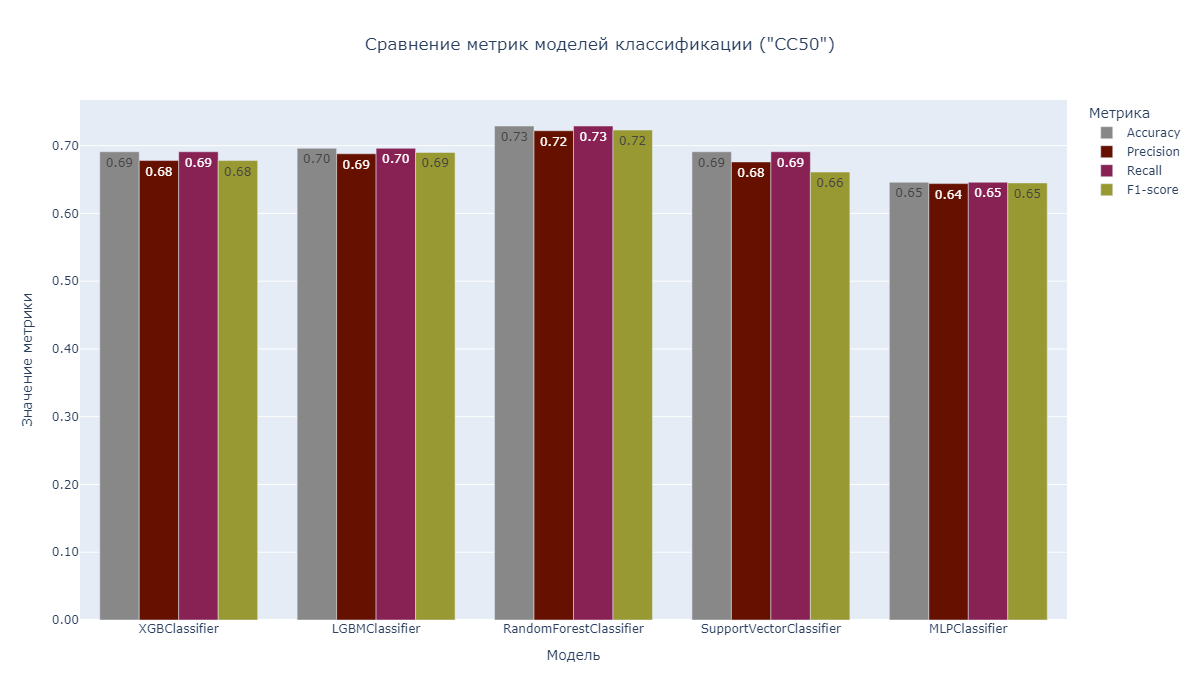

------------------------------------------------------------------------------------------------------------------------------------------------------


In [70]:
# Выводим результат
check_data_inf(
    data = metrics_df,
    data_name = 'metrics_df',
    length1 = 35,
    length2 = 60
)
print('\n\n')


# Применяем функцию 'metrics_bar_plot()' для построения столбчатого графика метрик
metrics_bar_plot(
    data = metrics_df,
    main_title = 'Столбчатая диаграмма сравнения метрик моделей классификации ("CC50"):',
    title = 'Сравнение метрик моделей классификации ("CC50")',
    colors = px.colors.qualitative.Safe_r
)

#### $4.5$

#### **Вывод:**

Лучшее качество значений метрик для данной задачи показала модель `RandomForestClassifier`.